<a href="https://colab.research.google.com/github/HaniyaAzzahra/eda-telco-churn-and-retain-analysis/blob/main/EDA_Telco_Customer_Retain_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**EDA Telco Customer Segmentation & Retention Analysis**



*   **Author      :** Haniya Azzahra
*   **Date Created :** 22-May-2026



##**General Context**

Hi Guys 👋🏻👋🏻, this is my personal portfolio project to learn and exercise my skills in doing exploratory data analysis for a telco company’s customers, specifically for segmentation & retention.

This notebook walks through the **full end-to-end process** — from raw data to actionable retention strategy. Here is what is covered:

* **Step 1 — Data Quality Assessment.** Validated 7,043 records, fixed data types, handled missing values in TotalCharges, and confirmed the data was clean before analysis began.

* **Step 2 — Exploratory Data Analysis.** Broke down churn patterns across demographics, services, contracts, and payment methods. Identified which customer segments carry the highest and lowest risk before building any models.

  * **Layer 1 — Rule-Based Persona.** Designed 3 customer personas using business logic and domain knowledge. This established the baseline segmentation and revealed where manual rules hit their ceiling.

  * **Layer 2 — Statistical Clustering (K-Prototype).** Let the data define natural customer groups. Used elbow method and silhouette score to select K=5. The clusters revealed behavioral segments that manual rules could not capture.

  * **Feature Validation — Mutual Information & XGBoost.** Identified which features actually predict churn. Confirmed 4 key drivers that all three predictive models agree on: tenure, contract type, support/security add-ons, and service zone.

  * **Layer 3 — Predictive Scoring.** Built and compared Logistic Regression, Random Forest, and XGBoost. Selected Random Forest as the best model (AUC 0.832). Scored every active customer by churn probability, ranked them by revenue at risk, and produced a ready-to-use retention priority list.

* **Step 3 — Stakeholder Deliverable**. Translated all findings into a presentation deck that tells the full story for business stakeholders — from customer segments and churn drivers to the retention priority list. The goal was not just to build models, but to make the insights actionable for stakeholders who need the business takeaway, not the technical details

If you are here to see how customer segmentation and churn prediction work in practice from cleaning data to delivering a prioritized action list, this notebook walks through every decision, trade-off, and business interpretation along the way.

---
**[Main Questions to Answer]**

Strategy to Retain Customers

**[Company Background]**

Telco company that provided Home phone & internet services to 7,043 customers in California Q3.

**[Information included in data set]**


*  **Customers who left within the last month** – the column is called Churn
*  **Services that each customer has signed up for** – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
* **Demographic info about customers** – gender, age range, and if they have partners and dependents



[Link source data](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)






##**Step 1 - Data Quality Assesment** 🔍


---
I always make sure **to validate the quality of the input data before jumping into analysis.** In real-world cases, **this involves aligning with business stakeholders, data owners, and system owners** to fully understand how the data should behave based on business rules and the possible causes of anomalies.

**Objective:**

to make sure the data is **accurate + valuable + timely + actionable**
because refer to main principle of analysis garbage input -> garbage output, good input -> good output

For this case, since this is a portfolio project where the data comes from Kaggle, assumptions may need to be made when necessary because there are no stakeholders available to consult.





### **1️⃣ Things to assess:**

* General information about data (data type, count of data, data dictionary)
* Missing Values
* Duplicates
* Unique values & Cardinality
* Basic statistics
* Outliers
* Value distribution
* Consistency issues, Range validation, Data volume



In [1]:
# @title Libraries Setup & Load Data Source
# ==================================================================================================
# Libraries Setup & Load Data Source
# ==================================================================================================

# -- pre-installed kmodes *if run in google colab with temp vm
!pip install kmodes

# --- Libraries ---

#-- set up & load data sources
# Drive is used to connect drive storage to colab
# Pandas is the main library for data analysis, manipulation, and working w/ tables/datasets
# warnings silence python's warning messages so dont cluuter notebook output
from google.colab import drive
from google.colab import files
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
#-- data viz & process
# matplotlib used to create charts and visualizations
# seaborn built on top of matplotlib, known as beautiful matplotlib shortcut to make prettier charts automatically
# numpy used for mathematical operations, arrays, stats, numerical computing
# matplotlib patches to provide patch object (2d obcject) add to a plot
# gridpsec make the plot layout more flexible
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
pd.set_option('display.width', 1000)
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
#-- algorithm for clustering/predictive
# StandardScaler standardize numerical data so all features are on a similar scale
# KPrototypes to implemenmt algortihm of kprototypes
# silhouette_score Silhouette Score is a metric used to evaluate how good a clustering result is.
# Parallel, delayed for parallel processing → running multiple tasks simultaneously to make computation faster.
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes
from sklearn.metrics    import silhouette_score
from joblib             import Parallel, delayed
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import shap




# --- Import Dataset ---
url = 'https://docs.google.com/spreadsheets/d/1dShObVW_77p8nfPYFt4usbtZA7fun_wttyEvfTawkGI/export?format=csv'
df = pd.read_csv(url) # Read CSV fileprint("__________________________________________________________________________________________")

print('\n' + '=' * 68)
print('LOAD DATA SOURCE')
print('=' * 68)
print()
print("◼️Here is the data sample ")
df.head(5) # show top 5 row in the data


LOAD DATA SOURCE

◼️Here is the data sample 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,"29,85","29,85",No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,"56,95","1889,5",No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,"53,85","108,15",Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),"42,3","1840,75",No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,"70,7","151,65",Yes



DATA QUALITY ASSESMENT
Keep Scrolling to see the full content of this section : General Information, Missing values, overall basic statistic absolute, tren, chart viz

============================= General Information about Data Table ============================

◼️Count of Rows, Columns, Duplicate Rows
Total Rows of data : 7043
Total columns of data : 21
Total same record repeated/duplicate row: 0
__________________________________________________________________________________________

◼️Data type value for each columns 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   gender            7043 non-null   object
 2   SeniorCitizen     7043 non-null   int64 
 3   Partner           7043 non-null   object
 4   Dependents        7043 non-null   object
 5   tenure            7043 non-null   

,column_name,total_values,null_count,null_percentage,cardinality
0,TotalCharges,7043,11,0.1562%,6530
1,customerID,7043,0,0.0000%,7043
2,DeviceProtection,7043,0,0.0000%,3
3,MonthlyCharges,7043,0,0.0000%,1585
4,PaymentMethod,7043,0,0.0000%,4
5,PaperlessBilling,7043,0,0.0000%,2
6,Contract,7043,0,0.0000%,3
7,StreamingMovies,7043,0,0.0000%,3
8,StreamingTV,7043,0,0.0000%,3
9,TechSupport,7043,0,0.0000%,3



============================= BASIC STATISTICS ============================
SECTION 1 — Summary Statistics

◼️ Table Recap (mean, median, percentile, max, std)



,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000



SECTION 2 — Per Column Diagnostics + Scaler Recommendation

◼️ tenure
   Mean        : 32.37
   Median      : 29.00
   Mean-Median : 11.6% gap
   Std         : 24.56
   Skewness    : 0.240
   Outliers    : 0 (0.0%)
   Q1 / Q3     : 9.00 / 55.00
   IQR         : 46.00
   → StandardScaler  → clean data, low skew, no outliers

◼️ MonthlyCharges
   Mean        : 64.76
   Median      : 70.35
   Mean-Median : 7.9% gap
   Std         : 30.09
   Skewness    : -0.221
   Outliers    : 0 (0.0%)
   Q1 / Q3     : 35.50 / 89.85
   IQR         : 54.35
   → StandardScaler  → clean data, low skew, no outliers

◼️ TotalCharges
   Mean        : 2283.30
   Median      : 1397.47
   Mean-Median : 63.4% gap
   Std         : 2266.77
   Skewness    : 0.962
   Outliers    : 0 (0.0%)
   Q1 / Q3     : 401.45 / 3794.74
   IQR         : 3393.29
   → RobustScaler    → moderate skew or some outliers

SECTION 3 — Distribution (Histogram + KDE)



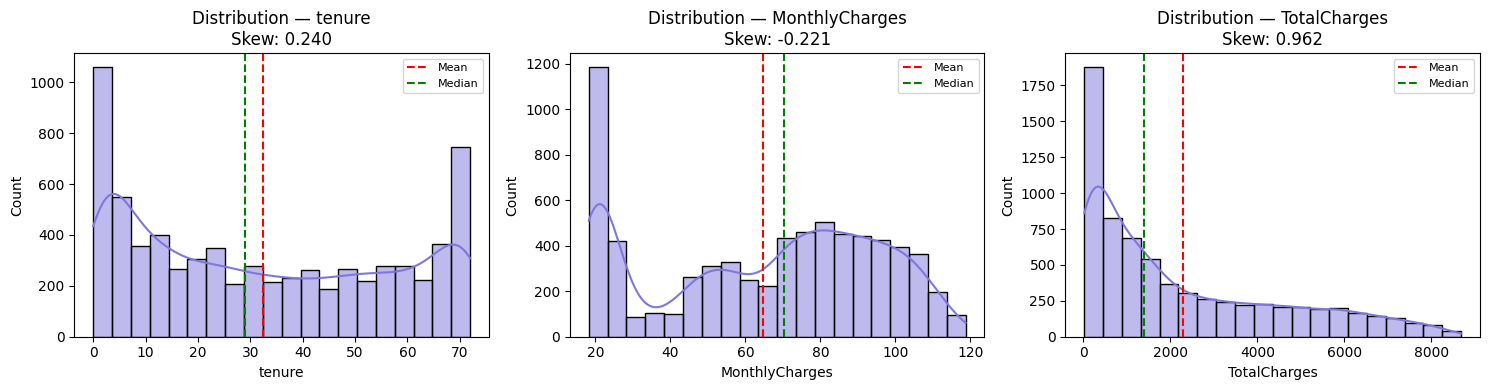

SECTION 4 — Boxplot / Outlier Detection



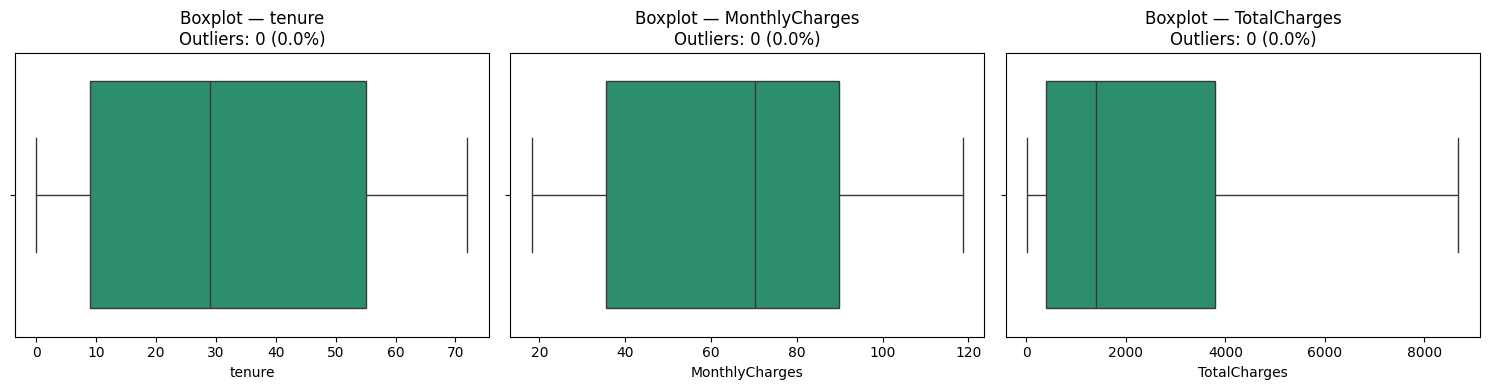

SECTION 5 — QQ Plot (Normality Check)



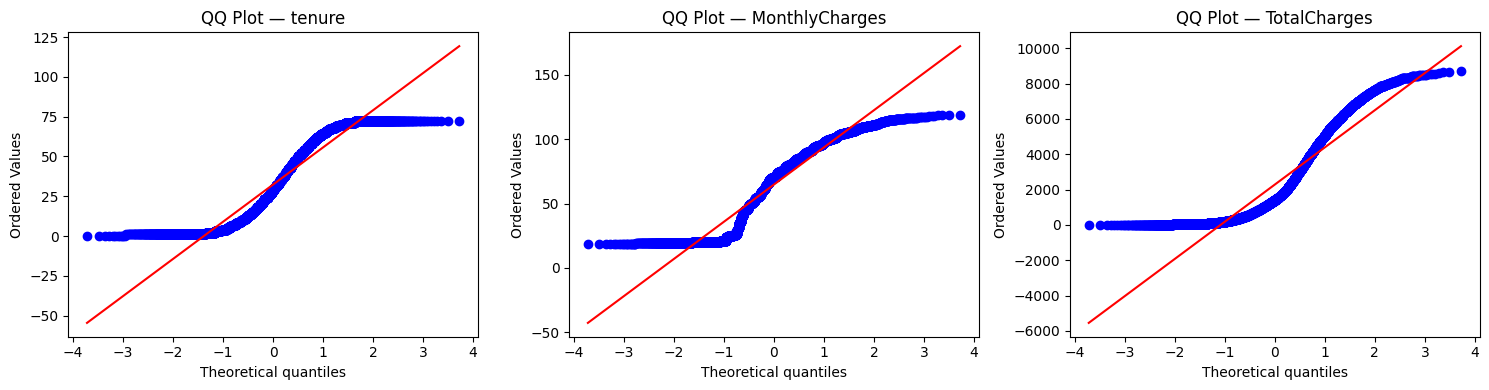

SECTION 6 — Scaler Recommendation Summary

  tenure                    → StandardScaler  → clean data, low skew, no outliers
  MonthlyCharges            → StandardScaler  → clean data, low skew, no outliers
  TotalCharges              → RobustScaler    → moderate skew or some outliers



In [2]:
# @title
# ==================================================================================================
# STEP 1 - DATA QUALITY ASSESMENT
# ==================================================================================================
print('\n' + '=' * 68)
print('DATA QUALITY ASSESMENT')
print('=' * 68)
print("Keep Scrolling to see the full content of this section : General Information, Missing values, overall basic statistic absolute, tren, chart viz")
print()



# --- Core Logic ---
# 1. Get general information about the data
print("============================= General Information about Data Table ============================")
print()
print("◼️Count of Rows, Columns, Duplicate Rows")
print(f"Total Rows of data : {df.shape[0]}")
print(f"Total columns of data : {df.shape[1]}")
print(f"Total same record repeated/duplicate row: {df.duplicated().sum()}")
print("__________________________________________________________________________________________")
print()
print("◼️Data type value for each columns ")
df.info()
print()
print("__________________________________________________________________________________________")

#  ✅ do adjustment if needed in this section
#  *because the data is auto converted by sheet hence the dtype is changing so need to adjust it back

print("✅ Adjust Data Type")
# function - to help dynamically convert dtype
def get_column_types_converted(df, numeric_columns=None, string_columns=None):
    '''
    Function to convert:
    - object/string columns to numeric
    - numeric/int columns to string

    Parameters:
    ----------
    df : pandas.DataFrame
        Source dataframe

    numeric_columns : list
        List of columns to convert into numeric

    string_columns : list
        List of columns to convert into string
    '''

    changed_dtypes = {}

   # convert to numeric
    if numeric_columns is not None:
        for col in numeric_columns:

            if df[col].dtype == "object":
                df[col] = pd.to_numeric(
                    df[col].str.replace(",", "."),
                    errors="coerce"
                )

            changed_dtypes[col] = df[col].dtype

    # convert to string
    if string_columns is not None:
        for col in string_columns:

            if df[col].dtype != "object":
                df[col] = df[col].astype(str)

            changed_dtypes[col] = df[col].dtype

    return pd.DataFrame.from_dict(changed_dtypes, orient='index', columns=['dtype'])

# main output
print()
''' to make function applicable for variouse data src,
for another case/src data, i just need to change input param in numeric column, string column '''
print(
    get_column_types_converted(
    df,
    numeric_columns=["MonthlyCharges", "TotalCharges"],
    string_columns=["SeniorCitizen"])
)


# 2. Missing Values & Unique Values/Cardinality
def get_summary_column_info(df):
    '''
    Function to get summary of column information such as:
    - total values
    - null count
    - null percentage
    - cardinality for each column
    '''

    # initiate new table called summary_column_info
    summary_column_info = pd.DataFrame()

    # add column 'column_name' contain list of all column from source data table
    summary_column_info["column_name"] = df.columns

    # add column 'total_values' contain count of available value in that column
    summary_column_info["total_values"] = len(df)

    # add column 'null_count' contain count of null value in the column
    summary_column_info["null_count"] = df.isnull().sum().values

    # add column 'null_percentage' to see % of null for each column
    summary_column_info["null_percentage"] = (
        summary_column_info["null_count"]
        / summary_column_info["total_values"]

    ).map('{:.4%}'.format)

    # add column 'cardinality' to see distinct unique value for each column
    summary_column_info["cardinality"] = df.nunique().values

    # sort table based on null_percentage column descending
    summary_column_info = (
        summary_column_info
        .sort_values(by="null_percentage", ascending=False)
        .reset_index(drop=True)
    )

    return summary_column_info

# main_output
print()
print("============================= Summary Column Info - Missing Values x Cardinality ============================")
print()
print("◼️Table Recap")
display(get_summary_column_info(df))
print()


def get_basic_statistic_for_numerical(df):
    '''
    Function to get basic statistic description of numerical columns:
    - Summary statistics (mean, median, std, percentiles)
    - Skewness and outlier detection per column
    - Distribution histogram with KDE
    - Boxplot for outlier visualization
    - QQ Plot for normality check
    - Scaler recommendation based on data characteristics
    '''

    # ── Setup ─────────────────────────────────────────────────────────────────
    numerical_columns = df.select_dtypes(include='number').columns.tolist()

    if not numerical_columns:
        print("No numerical columns found.")
        return

    n_cols = 3
    n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

    print("============================= BASIC STATISTICS ============================")
    print("=" * 80)
    print("SECTION 1 — Summary Statistics")
    print("=" * 80)
    print()
    print("◼️ Table Recap (mean, median, percentile, max, std)")
    print()
    display(df[numerical_columns].describe())
    print()

    # ═════════════════════════════════════════════════════════════════════════
    # SECTION 2 — Per Column Diagnostics + Scaler Recommendation
    # ═════════════════════════════════════════════════════════════════════════
    print("=" * 80)
    print("SECTION 2 — Per Column Diagnostics + Scaler Recommendation")
    print("=" * 80)
    print()

    scaler_recommendations = {}

    for col in numerical_columns:
        values = df[col].dropna()

        Q1       = values.quantile(0.25)
        Q3       = values.quantile(0.75)
        IQR      = Q3 - Q1
        outliers = ((values < Q1 - 1.5 * IQR) |
                    (values > Q3 + 1.5 * IQR)).sum()
        skewness = values.skew()
        mean     = values.mean()
        median   = values.median()
        gap_pct  = abs(mean - median) / (median + 1e-9) * 100

        # ── Scaler recommendation logic ───────────────────────────────────
        outlier_pct = outliers / len(values)

        if outlier_pct > 0.05 or abs(skewness) > 1.0:
            recommendation = 'RobustScaler    → heavy skew or many outliers'
        elif outlier_pct > 0.01 or abs(skewness) > 0.5:
            recommendation = 'RobustScaler    → moderate skew or some outliers'
        else:
            recommendation = 'StandardScaler  → clean data, low skew, no outliers'

        scaler_recommendations[col] = recommendation

        print(f"◼️ {col}")
        print(f"   Mean        : {mean:.2f}")
        print(f"   Median      : {median:.2f}")
        print(f"   Mean-Median : {gap_pct:.1f}% gap")
        print(f"   Std         : {values.std():.2f}")
        print(f"   Skewness    : {skewness:.3f}")
        print(f"   Outliers    : {outliers} ({outlier_pct:.1%})")
        print(f"   Q1 / Q3     : {Q1:.2f} / {Q3:.2f}")
        print(f"   IQR         : {IQR:.2f}")
        print(f"   → {recommendation}")
        print()

    # ═════════════════════════════════════════════════════════════════════════
    # SECTION 3 — Distribution (Histogram + KDE)
    # ═════════════════════════════════════════════════════════════════════════
    print("=" * 80)
    print("SECTION 3 — Distribution (Histogram + KDE)")
    print("=" * 80)
    print()

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols,
                             figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, numerical_columns):
        values = df[col].dropna()

        sns.histplot(data=df, x=col, bins=20, kde=True,
                     ax=ax, color='#7F77DD')

        ax.axvline(values.mean(),
                   color='red', linestyle='--',
                   linewidth=1.5, label='Mean')
        ax.axvline(values.median(),
                   color='green', linestyle='--',
                   linewidth=1.5, label='Median')
        ax.set_title(f"Distribution — {col}\nSkew: {values.skew():.3f}")
        ax.legend(fontsize=8)

    for i in range(len(numerical_columns), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

    # ═════════════════════════════════════════════════════════════════════════
    # SECTION 4 — Boxplot / Outlier Detection
    # ═════════════════════════════════════════════════════════════════════════
    print("=" * 80)
    print("SECTION 4 — Boxplot / Outlier Detection")
    print("=" * 80)
    print()

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols,
                             figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, numerical_columns):
        values  = df[col].dropna()
        Q1      = values.quantile(0.25)
        Q3      = values.quantile(0.75)
        IQR     = Q3 - Q1
        outliers= ((values < Q1 - 1.5*IQR) |
                   (values > Q3 + 1.5*IQR)).sum()

        sns.boxplot(data=df, x=col, ax=ax, color='#1D9E75')
        ax.set_title(
            f"Boxplot — {col}\nOutliers: {outliers} ({outliers/len(values):.1%})"
        )

    for i in range(len(numerical_columns), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

    # ═════════════════════════════════════════════════════════════════════════
    # SECTION 5 — QQ Plot (Normality Check)
    # ═════════════════════════════════════════════════════════════════════════
    print("=" * 80)
    print("SECTION 5 — QQ Plot (Normality Check)")
    print("=" * 80)
    print()

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols,
                             figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, numerical_columns):
        stats.probplot(df[col].dropna(), dist='norm', plot=ax)
        ax.set_title(f"QQ Plot — {col}")

    for i in range(len(numerical_columns), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

    # ═════════════════════════════════════════════════════════════════════════
    # SECTION 6 — Scaler Recommendation Summary
    # ═════════════════════════════════════════════════════════════════════════
    print("=" * 80)
    print("SECTION 6 — Scaler Recommendation Summary")
    print("=" * 80)
    print()

    for col, rec in scaler_recommendations.items():
        print(f"  {col:<25} → {rec}")

    print()


# main output
get_basic_statistic_for_numerical(df)


###**2️⃣ Handling Missing Values**

Based on the previous data quality assessment, TotalCharges was found to be the only column with missing values,representing 0.15% null values from the overall dataset.

**Even though the percentage is very small and likely would not significantly change the overall trend**, **I always make sure to follow a proper decision framework to ensure every data cleaning decision is intentional, defensible, and well-documented.**

This approach also helps minimize the possibility of the same issue happening again, since the error has already been identified for future system and data accuracy improvement

In other cases, especially when the data product is used for financial purposes, even a difference of a single row could become a serious audit issue.

---

**Step by Step to Handle Mising Values:**

1. Understand **WHY** the data is missing
 - Investigate the root cause *(e.g., whether it occurred randomly due to a bug, was triggered by a specific condition in the system or data input process, or happened because the input field was optional)*

2. Check **the volume** of missing data
- less than 1%, for non-finance reconciliation generally still safe
- 1% - 5%, remove only if confirmed random
- more than 5%, investigate further before taking any action

3. **List of questions** before deleting
- Q1.Can we recover the data?
- Q2.How many rows are missing?
- Q3.How important is this column?
- Q4.Can we impute instead of delete?


---

**For this case study, removing the rows with missing values** is the best option because:

1. The missing value percentage is below the 1% threshold.
2. Imputation using available columns produced inconsistent results (refer to the code snippet below for details).
3. Since the dataset is sourced from Kaggle, recovering the missing data is not possible.



In [3]:
# @title
#
# ==================================================================================================
# HANDLING MISSING VALUES : IMPUTATION TESTING & VALIDATION, REMOVE MISSING VALUES
# ==================================================================================================

# IMPUTATION FOR TOTALCHARGES COLUMN
# assumption -> total charges: monthlyCharges * tenure

# core logic
imp_TotalCharges = (df["tenure"] * df["MonthlyCharges"]).sum()
ori_TotalCharges = df["TotalCharges"].sum()
comparison       = imp_TotalCharges - ori_TotalCharges

# main output
print(" --- HANDLING MISSING VALUES--- ")
print()
print("============================= IMPUTATION TESTING & VALIDATION ============================")
print()
print("◼️Total Charges Comparison")
print()
print(f"imputation_totalCharges: {imp_TotalCharges:,.0f}")
print(f"TotalCharges_sum: {ori_TotalCharges:,.0f}")
print(f"Difference: {comparison:,.0f}")
print(f"Notes:")
print(f"Discrepancy caused by various factors (e.g prorated billing, discount, pricing change).")
print(f"**without access to system/owner system , accurate imputation is not feasible")
# IMPUTATION FOR TOTALCHARGES COLUMN
print()
print("============================= EXECUTE REMOVAL DATA  ============================")
print()
src_data = df.dropna(subset=["TotalCharges"]).copy() # final source data that will be used
print("✅ Successfully created src_data table: copied dataframe and removed NA values from TotalCharges.")

 --- HANDLING MISSING VALUES--- 

============================= IMPUTATION TESTING & VALIDATION ============================

◼️Total Charges Comparison

imputation_totalCharges: 16,055,091
TotalCharges_sum: 16,056,169
Difference: -1,077
Notes:
Discrepancy caused by various factors (e.g prorated billing, discount, pricing change).
**without access to system/owner system , accurate imputation is not feasible

============================= EXECUTE REMOVAL DATA  ============================

✅ Successfully created src_data table: copied dataframe and removed NA values from TotalCharges.


##**Step 2 - Exploratory Data Analysis** 💡📈📊


---
🎯**Main North Star**

***"Develop Focused Customer Retention Program"***

Description:

The company understands the **overall customer churn trend** and **has solid customer segmentation and insights (lifetime value, behavior),** along with **predictive churn scoring** to help **build an effective retention strategy** in order to **provide the best service quality and mitigate churn.**



---



###1️⃣ **First Things First: Understand the Business Model**

Knowing the business model, or **how the business makes money, makes it easier for me to read and understand the context of the data**, which parts are important and which are not. **It also helps build alignment across all the insights that I gathered.**

**In real life,** there are many ways to understand the business model. **My favorite method is sharing knowledge with process owners such as marketing, sales, finance, etc.,** to be able to see the data from their point of view.


**For this case,** I learned from the internet, and as an internet subscription user myself, I also used my own experience as a customer.


**◼️ Overview of the Business Model of a Telco Company**

> **Main Business Model** = Timely Subscription + OverUsage (*fee that being charge to customer that use service beyond the default quota)



> **Things to HIGHLIGHT** :
> 1. **The more products** + features a customer holds, **the harder it is to leave** (product stickiness or service bundling effect.)
**example :**
>*Customer A = PhoneService only → 1 product → easy to leave, low switching cost*
>*Customer B: PhoneService + Internet + StreamingTV + OnlineSecurity + TechSupport → 5 products → to leave, they must replace ALL of these elsewhere → High friction to churn*

> 2. **Revenue Before Value Delivery** -> means the company can generate revenue upfront before delivering the full value of the service over time. example : customers buy prepaid credit/packages before using internet access.

>3. **The Ghost Customer Problem** customer can be PAYING but not USING. They will likely to churn the moment they notice they're paying for nothing. Hence, usage data is also important in subs model

>4. **Switching Cost is Artificially Managed** The condition where the company intentionally increases switching costs by offering long-term contracts, bundled services, loyalty points, exclusive promotions, etc. Hence, even if competitors are cheaper, customers may stay because switching feels troublesome

>5. **Overusage Paradox** Customer loves the product (good!) → But gets surprise bills (bad!) → Surprise bills are one of the TOP reasons customers churn to competitors → A loyal heavy user can become company biggest churn risk after one bad bill

>6. **Invisible Product** Customers only NOTICE the product when it FAILS → This is why TechSupport and OnlineSecurity in the data are retention signals, not just revenue lines

   








###**2️⃣ Overall Current Situation Trend (Churn, LifetimeValue, Revenue at risk)**



---

The first section of the analysis shows the company’s overall condition and whether the business is performing well or poorly.

**Objective:**

**Start by exploring the overall metrics to understand the general performance picture**


============================= Overall Current Situation Trend (Churn, LifetimeValue, Revenue at risk) ============================

◼️ Metrics Overview Table



,Metric,Value
0,Total Customers,"7,032"
1,Churned Customers,"1,869"
2,Retained Customers,"5,163"
3,Churn Rate,26.58%
4,Total Monthly Revenue,"$455,661.00"
5,Monthly Revenue at Risk,"$139,130.85"
6,Monthly Revenue at Retained,"$316,530.15"
7,Revenue at Risk %,30.53%
8,Annual Revenue at Risk,"$1,669,570.20"
9,Avg Tenure - Churned,18.0 months



◼️ Metrics Overview Visualization



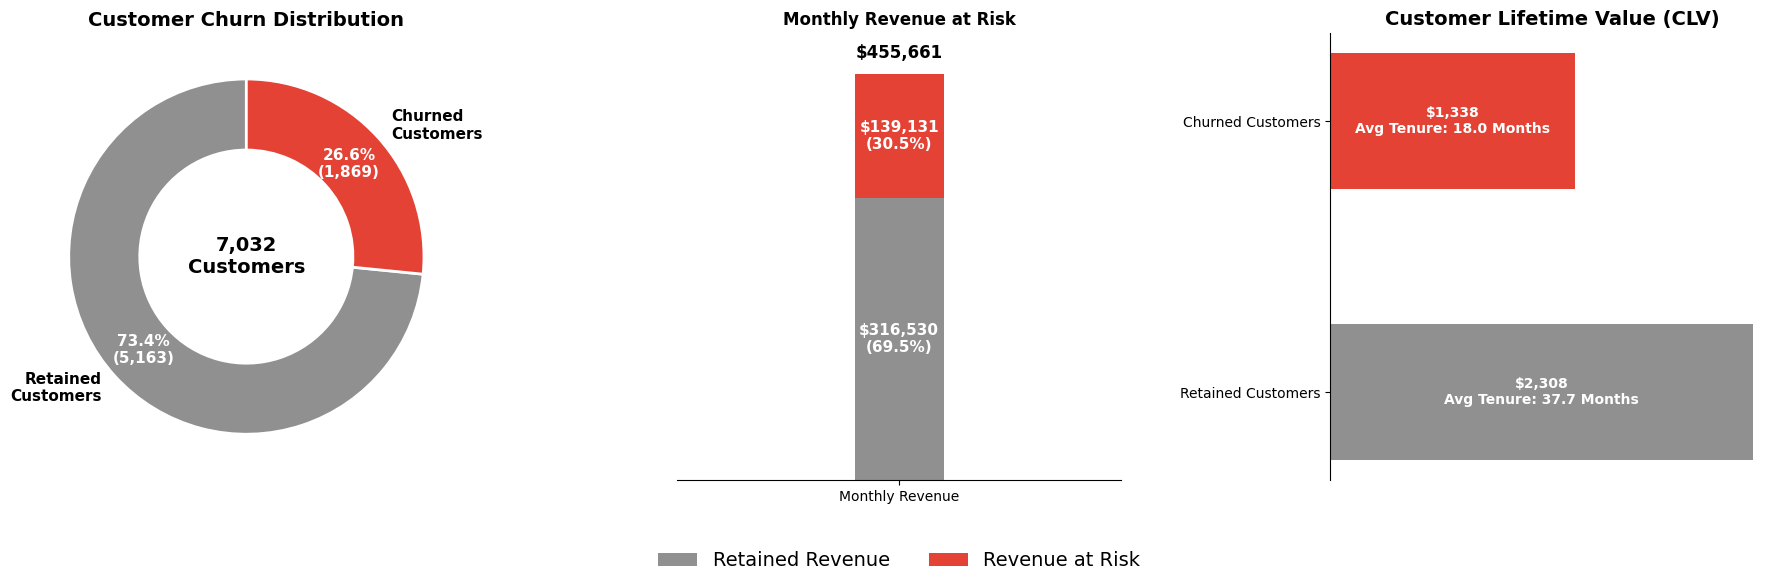

In [4]:
# @title
# ==================================================================================================
#  Overall Current Situation Trend (Churn, LifetimeValue, Revenue at risk)
# ==================================================================================================


# --- Core Logic
# 1. Churn Rate Overview Metrics
total_customers = len(src_data)
churned_customers = src_data[src_data['Churn'] == 'Yes'].shape[0]
retained_customers = src_data[src_data['Churn'] == 'No'].shape[0]
churn_rate = (churned_customers / total_customers) * 100

# 2. Monthly Revenue at Risk - Metrics
monthly_revenue_at_risk = src_data[src_data['Churn'] == 'Yes']['MonthlyCharges'].sum()
avg_monthly_churned = src_data[src_data['Churn'] == 'Yes']['MonthlyCharges'].mean()
monthly_revenue_retained = src_data[src_data['Churn'] == 'No']['MonthlyCharges'].sum()
total_monthly_revenue = src_data['MonthlyCharges'].sum()
revenue_at_risk_pct = (monthly_revenue_at_risk / total_monthly_revenue) * 100

# 3. Annual revenue at risk
annual_revenue_at_risk = monthly_revenue_at_risk * 12
annual_total_revenue = total_monthly_revenue * 12
annual_retained_revenue = monthly_revenue_retained * 12

# 4. Average Customer Lifetime Value
# Average
avg_tenure_churned = src_data[src_data['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_retained = src_data[src_data['Churn'] == 'No']['tenure'].mean()
# Median
median_tenure_churned = src_data[src_data['Churn'] == 'Yes']['tenure'].median()
median_tenure_retained = src_data[src_data['Churn'] == 'No']['tenure'].median()
# Simple CLV -> = avg monthly charges x avg tenure
clv_churned = avg_monthly_churned * avg_tenure_churned
clv_retained = src_data[src_data['Churn'] == 'No']['MonthlyCharges'].mean() * avg_tenure_retained

# --- Main Output ---
# summary table

summary = {
    'Metric': [
        'Total Customers',
        'Churned Customers',
        'Retained Customers',
        'Churn Rate',
        'Total Monthly Revenue',
        'Monthly Revenue at Risk',
        'Monthly Revenue at Retained',
        'Revenue at Risk %',
        'Annual Revenue at Risk',
        'Avg Tenure - Churned',
        'Avg Tenure - Retained',
        'Avg CLV - Churned',
        'Avg CLV - Retained',
        'CLV Gap'
    ],
    'Value': [
        f"{total_customers:,}",
        f"{churned_customers:,}",
        f"{retained_customers:,}",
        f"{churn_rate:.2f}%",
        f"${total_monthly_revenue:,.2f}",
        f"${monthly_revenue_at_risk:,.2f}",
        f"${monthly_revenue_retained:,.2f}",
        f"{revenue_at_risk_pct:.2f}%",
        f"${annual_revenue_at_risk:,.2f}",
        f"{avg_tenure_churned:.1f} months",
        f"{avg_tenure_retained:.1f} months",
        f"${clv_churned:,.2f}",
        f"${clv_retained:,.2f}",
        f"${clv_retained - clv_churned:,.2f}"
    ]
}
summary_table = pd.DataFrame(summary)

print()
print("============================= Overall Current Situation Trend (Churn, LifetimeValue, Revenue at risk) ============================")
print()
print("◼️ Metrics Overview Table")
print()
display(summary_table)

# summary Vizualization
print()
print("◼️ Metrics Overview Visualization")
print()


# Setup Layout - One Row, 3 Charts


fig, axes = plt.subplots(
    1, 3,
    figsize=(18,6)
)


# 1. Donut Chart - Customer Churn Distribution---
# function to show percentage + absolute number
def custom_autopct(pct):

    absolute = int(pct / 100 * total_customers)

    return f"{pct:.1f}%\n({absolute:,})"

# labels
labels = ["Retained\nCustomers", "Churned\nCustomers"]

# colors
colors = ["#909090", "#E34234"]

# create donut chart inside first subplot
wedges, texts, autotexts = axes[0].pie(
    [retained_customers, churned_customers],
    labels=labels,
    autopct=custom_autopct,
    pctdistance=0.78,
    startangle=90,
    colors=colors,
    wedgeprops=dict(
        width=0.4,
        edgecolor='white',
        linewidth=2
    ),
    textprops=dict(
        color='black',
        fontsize=12,
        fontweight='bold'
    )
)

# style percentage labels
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")

# style outside labels
for text in texts:
    text.set_color("black")
    text.set_fontsize(11)

# center text
axes[0].text(
    0,
    0,
    f"{total_customers:,}\nCustomers",
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

# chart title
axes[0].set_title(
    "Customer Churn Distribution",
    fontsize=14,
    fontweight='bold'
)


# 2. Stacked Bar Chart Monthly Revenue ---

#add on metrics needed
# revenue metrics
total_monthly_revenue = (
    monthly_revenue_retained + monthly_revenue_at_risk
)
# percentage
retained_pct = (
    monthly_revenue_retained / total_monthly_revenue * 100
)
risk_pct = (
    monthly_revenue_at_risk / total_monthly_revenue * 100
)

# retained revenue
axes[1].bar(
    "Monthly Revenue",
    retained_pct,
     width=0.2,
    color="#909090",
    label="Retained Revenue"
)

# revenue at risk
axes[1].bar(
    "Monthly Revenue",
    risk_pct,
    bottom=retained_pct,
     width=0.2,
    color="#E34234",
    label="Revenue at Risk"
)

# make the axis more slimmer
axes[1].set_xlim(-0.5, 0.5)

# retained label
axes[1].text(
    0,
    retained_pct / 2,
    f"${monthly_revenue_retained:,.0f}\n({retained_pct:.1f}%)",
    ha='center',
    va='center',
    fontsize=11,
    fontweight='bold',
    color='white'
)

# churn/risk label
axes[1].text(
    0,
    retained_pct + (risk_pct / 2),
    f"${monthly_revenue_at_risk:,.0f}\n({risk_pct:.1f}%)",
    ha='center',
    va='center',
    fontsize=11,
    fontweight='bold',
    color='white'
)

# total revenue label on top
axes[1].text(
    0,
    103,
    f"${total_monthly_revenue:,.0f}",
    ha='center',
    va='bottom',
    fontsize=12,
    fontweight='bold'
)


# styling
axes[1].set_ylim(0, 110)

# remove y-axis label and ticks
axes[1].set_ylabel("")
axes[1].set_yticks([])

# remove unnecessary spines
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)

axes[1].set_title(
    "Monthly Revenue at Risk",
    fontsize=12,
    fontweight='bold'
)

# legend at bottom
axes[1].legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=14,
    frameon=False
)



# Chart 3 - CLV Comparison ---
# categories
categories = [
    "Retained Customers",
    "Churned Customers"
]

# monetary values
clv_values = [
    clv_retained,
    clv_churned
]

# average tenure values
tenure_values = [
    avg_tenure_retained,
    avg_tenure_churned
]

# colors
colors = ["#909090", "#E34234"]

# ============================================
# Horizontal Bar Chart
# ============================================

bars = axes[2].barh(
    categories,
    clv_values,
    color=colors,
    height=0.5
)

# ============================================
# Add Labels
# ============================================

for bar, clv, tenure in zip(
    bars,
    clv_values,
    tenure_values
):

    axes[2].text(
        bar.get_width() * 0.5,
        bar.get_y() + bar.get_height()/2,
        f"${clv:,.0f}\nAvg Tenure: {tenure:.1f} Months",
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

# ============================================
# Styling
# ============================================

axes[2].set_title(
    "Customer Lifetime Value (CLV)",
    fontsize=14,
    fontweight='bold'
)

# remove x-axis
axes[2].set_xticks([])

# remove unnecessary spines
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].spines['bottom'].set_visible(False)

# remove x-axis label
axes[2].set_xlabel("")
# clean spacing
plt.tight_layout()

# show all charts
plt.show()




###**3️⃣ Breakdown Parameter/Feature Definition by Customer Profile, Behaviour, Experience**



---

**Objective:**
There are more than 20 parameters/dimensions available in the dataset, and not all of them are necessary for the analysis. Therefore, a parameter breakdown section is created to find the key parameters and remove statistical noise that could impact the data model or calculations.

**Best Practice approach to define parameter**

Each parameter in this framework is validated against three questions:
1.   Does it move before a customer churns?
2.    Does it move early enough to act on, ideally 60–90 days before exit?
3. Is it specific to our business model, subscription + recurring revenue or just statistical noise?
4. Support final parameter with lift test (*read more in handling majority bias problem section)

Only parameters that pass all four tests are included in the churn vs retained profiling framework.

**Handling Majority Bias Problem**
the common thing that happened when I done analysis, the trend/rate of specific case is the same with overall case. in this study case for example lets say for

**Example Majority Bias:**

Overall churn rate = 26.5%

Gender = Male   → churn rate 26.2%

Gender = Female → churn rate 26.9%

→ Almost identical to overall rate
→ Gender tells NOTHING beyond what data already know
→ Majority biased — the big group is drowning the signal

**The Manual Way to Test This — Lift**
Lift is the simplest tool to detect if a parameter (value of the column) is actually useful or just noise.

*Lift = Churn Rate in Segment / Overall Churn Rate*

* Lift = 1.0  → this segment behaves exactly like everyone else → useless
* Lift > 1.0  → this segment churns MORE than average → signal found (*likely churn)
* Lift < 1.0  → this segment churns LESS than average → also a signal(*likely loyal)



**for this study case** -> Public datasets like this one are intentionally sanitized, removing operationally sensitive signals that are critical for real-world churn models, such as support call logs, complaint tickets, and payment delay patterns. Within these limitations, this framework focuses on extracting the maximum insight from the available data while highlighting the additional factors a production-grade model would typically include.



In [5]:
# @title Breakdown Parameter Definition by Customer Profile, Behaviour, Experiences
# ==================================================================================================
# Telco Churn Detection — Parameter Definition by Customer Profile, Behavior & Experience
# ==================================================================================================


# --- Core Logic ---
# VARIABLE HELPER

# ------------------------------------------------ GENERAL/HELPER VARIABLE-------------------------------------------------------------------
# general
src_data['churn_flag'] = (src_data['Churn'] == 'Yes').astype(int) # to avoid using case when lambda
src_data['overall_churn_rate'] = src_data['churn_flag'].mean() # if the column have 0 and 1 then mean is the same with sum / total

# senior citizen
src_data['senior_citizen_flag'] = np.where(
    src_data['SeniorCitizen'] == 1, 'Senior Citizen', 'Non Senior Citizen'
)

# tenure
tenure_bins   = [0, 12, 24, 48, float('inf')]                            # grouping tenure into tenure segment
tenure_labels = ['0-12 months (New)', '13-24 months (Developing)', '25-48 months (Established)', '49+ months (Loyal)']
src_data['tenure_segment'] = pd.cut(src_data['tenure'], bins=tenure_bins , labels=tenure_labels, include_lowest=True)

# payment
# flag segment automatic
src_data['payment_segment'] = np.where(
        (src_data['PaymentMethod'].str.contains('automatic', case=False, na=False))
        ,'automatic'
        ,'manual'
 )

# revenue
# flag segment monthly charges
monthly_charges_bins   = [0, 35, 65, 90, float('inf')]                          # percentile based on grouping
monthly_charges_labels = ['Low ($0-35)', 'Mid ($36-65)', 'High ($66-90)', 'Premium ($91+)']
src_data['monthly_charges_segment'] = pd.cut(src_data['MonthlyCharges'], bins=monthly_charges_bins, labels=monthly_charges_labels, include_lowest=True)

# Cumulative revenue over tenure. High Total Charges = High LTV Customer
total_charges_bins   = [0, 402, 1398, 3795, float('inf')]                          # percentile based on grouping
total_charges_labels = ['Low ($0-402)', 'Mid ($403-1398)', 'High ($1399-3795)', 'Premium ($3796+)']
src_data['total_charges_segment'] = pd.cut(src_data['TotalCharges'], bins=total_charges_bins, labels=total_charges_labels, include_lowest=True)

# service
service_segments_conditions = [
    (src_data['PhoneService'] == 'Yes') & (src_data['InternetService'] == 'No'),
    (src_data['PhoneService'] == 'No')  & (src_data['InternetService'] != 'No'),
    (src_data['PhoneService'] == 'Yes') & (src_data['InternetService'] != 'No')  # ← also fixed logic
]

service_segments_choices = [
            'PhoneOnly'
           , 'InternetOnly'
           , 'Phone & Internet'
           ]
# service segment distribution
src_data['service_segments'] = np.select(service_segments_conditions, service_segments_choices, default=None)

# flag service entertainment
src_data['has_entertainment'] = np.where(
        (src_data['StreamingTV'] == 'Yes') |  (src_data['StreamingMovies'] == 'Yes')
        ,'Yes'
        ,'No'
 )
# flag service entertainment
src_data['has_support_or_security'] = np.where(
        (src_data['OnlineSecurity'] == 'Yes') |  (src_data['TechSupport']  == 'Yes')
        ,'Yes'
        ,'No'
 )
# flag service entertainment
src_data['has_protection_or_backup'] = np.where(
         (src_data['OnlineBackup'] == 'Yes') | (src_data['DeviceProtection'] == 'Yes')
        ,'Yes'
        ,'No'
 )
# service / product count
src_data['service_counts'] = (
    (src_data['PhoneService'] == 'Yes').astype(int) +
    (src_data['MultipleLines'] == 'Yes').astype(int) +
    (src_data['InternetService'] != 'No').astype(int) +
    (src_data['OnlineSecurity'] == 'Yes').astype(int) +
    (src_data['OnlineBackup'] == 'Yes').astype(int) +
    (src_data['DeviceProtection'] == 'Yes').astype(int) +
    (src_data['TechSupport'] == 'Yes').astype(int) +
    (src_data['StreamingTV'] == 'Yes').astype(int) +
    (src_data['StreamingMovies'] == 'Yes').astype(int)
)
# service count zone -- refer to scaling

# Cumulative revenue over tenure. High Total Charges = High LTV Customer
service_zone_bins   = [-1,1,3,6,9]                          # percentile based on grouping
service_zone_labels = ['zone1_minimal', 'zone2-3_danger', 'zone4-6_transition', 'zone7-9_embedded']
src_data['service_zone'] = pd.cut(src_data['service_counts'], bins=service_zone_bins, labels=service_zone_labels, include_lowest=True)
# add on service for internet
src_data['add_on_counts_internet'] = (
    (src_data['OnlineSecurity'] == 'Yes').astype(int) +
    (src_data['OnlineBackup'] == 'Yes').astype(int) +
    (src_data['DeviceProtection'] == 'Yes').astype(int) +
    (src_data['TechSupport'] == 'Yes').astype(int) +
    (src_data['StreamingTV'] == 'Yes').astype(int) +
    (src_data['StreamingMovies'] == 'Yes').astype(int)
)
# add on service for phone
src_data['add_on_counts_phone'] = (
    (src_data['MultipleLines'] == 'Yes').astype(int)
)

# CATEGORY GROUP MAPPING
category_group_map = {# map column name into category group
    'gender'                       : 'DEMOGRAPHIC',
    'senior_citizen_flag'          : 'DEMOGRAPHIC',
    'Partner'                      : 'HOUSEHOLD',
    'Dependents'                   : 'HOUSEHOLD',
    'tenure_segment'               : 'TENURE & CONTRACT',
    'Contract'                     : 'TENURE & CONTRACT',
    'payment_segment'              : 'Payment',
    'PaymentMethod'                : 'Payment',
    'PaperlessBilling'             : 'Payment',
    'monthly_charges_segment'      : 'Revenue',
    'total_charges_segment'        : 'Revenue',
    'service_segments'             : 'Service',
    'service_counts'               : 'Service',
    'service_zone'                 : 'Service',
    'has_entertainment'            : 'Service',
    'has_support_or_security'      : 'Service',
    'has_protection_or_backup'     : 'Service',
}


# ------------------------------------------------ HELPER FUNCTION — reuse for every breakdown ------------------------------------------------
def summary_metrics(src_data, column, group=None):
    """
    Returns a summary dataframe with count, churned, churn rate, avg monthly, avg tenure, pctg distribution , lift ( to give signal relevancy of parameter)
    group          : label for the metric group  e.g. 'Gender', 'Senior Citizen'
    category_group : higher level grouping based on category_group_map

    """
    summary = src_data.groupby(column, observed=False).agg(
        total_customers         = ('customerID', 'count'),
        churned                 = ('churn_flag', 'sum'),
        avg_monthly             = ('MonthlyCharges', 'mean'),
        avg_tenure              = ('tenure', 'mean'),
        overall_churn_rate      = ('overall_churn_rate', 'max')
    ).reset_index()

    #  ── rename dimension column to generic 'category'
    summary = summary.rename(columns={column: 'category'})

    #  ── insert group columns at the front
    summary.insert(0, 'category_group', category_group_map.get(column, 'Other'))
    summary.insert(1, 'group',          group if group else column)

    # ──  Core metrics ────────────────────────────────────────────────
    summary['churn_rate_%']    = (summary['churned'] / summary['total_customers']).round(2)
    summary['pctg_of_total_%'] = (summary['total_customers'] / summary['total_customers'].sum()).round(2)
    summary['avg_monthly']     = summary['avg_monthly'].round(2)
    summary['avg_tenure']      = summary['avg_tenure'].round(1)

    #  ── Lift calculation -> to avoid majority bias of parameter, if the signal is too weak then it can be abandon
    #  ── How many times bigger (or smaller) is this group compared to normal?
    summary['lift']               = (summary['churn_rate_%'] / summary['overall_churn_rate']).round(2)

    # ── Signal strength label ────────────────────────────────────────────────
    conditions = [
    summary['lift'] >= 2.0,
    summary['lift'] >= 1.5,
    summary['lift'] >= 1.2,
    summary['lift'] >= 0.8,
    summary['lift'] >= 0.5
    ]

    choices = [
        'Very Strong',
        'Strong',
        'Moderate',
        'Weak',
        'Protective'
    ]

    summary['signal_strength'] = np.select(
        conditions,
        choices,
        default='Very Protective'
    )

    return summary.sort_values('lift', ascending=False).reset_index(drop=True)
# --------------------------------------------List All Parameters ------------------------------------------------
# ------------------------------------------------ LIST OF PARAMETERS -------------------------------------
# --- WHO they are (Static / Demographic)
# Demographic - often have different price sensitivity and tech adoption
gender_tbl     = summary_metrics(src_data, 'gender', group = 'Gender')
senior_tbl     = summary_metrics(src_data, 'senior_citizen_flag', group = 'Age Proxy')

# HOUSEHOLD - Household signal, customers with partners often share plans Family plans are harder to cancel - multiple users depend on the service
partner_tbl    = summary_metrics(src_data, 'Partner', group = 'HasPartner')
dependent_tbl  = summary_metrics(src_data, 'Dependents', group = 'HasDependent')

# TENURE & CONTRACT
# One of the strongest predictors. Long tenure = habit formed, switching cost high. Short tenure = still evaluating.
# The lock-in mechanism. Month-to-month = easy exit. 1-2 year = financial penalty to leave. Massive churn differentiator.
tenure_tbl     = summary_metrics(src_data, 'tenure_segment', group = 'Tenure')
contract_tbl   = summary_metrics(src_data, 'Contract', group = 'ContractType')

# PAYMENT
# method & segment -> reveals commitment level. Auto Pay = trust signal, Manual Pay = active monthly decision
# paperless billing -> more engaged with self service - see their bill mroe clearly can trigger price sensitivity
payment_method_tbl    = summary_metrics(src_data, 'PaymentMethod', group = 'Payment Method')
payment_segment_tbl   = summary_metrics(src_data, 'payment_segment', group = 'Payment Segment')
paperless_billing_tbl = summary_metrics(src_data, 'PaperlessBilling', group = 'Is Paperless Billing')

# REVENUE
# Describe Customer tier and value
monthly_charges_segment_tbl = summary_metrics(src_data, 'monthly_charges_segment', group = 'Monthly Charges')
total_charges_segment_tbl   = summary_metrics(src_data, 'total_charges_segment', group = 'Total Charges')

# --- WHAT they DO
# service segment
service_segments_tbl     = summary_metrics(src_data, 'service_segments', group = 'Service Segment')
service_counts_tbl       = summary_metrics(src_data, 'service_counts', group = 'Service Count')
service_zone_tbl         = summary_metrics(src_data, 'service_zone', group = 'Service Zone')
add_on_internet_tbl      = summary_metrics(src_data, 'add_on_counts_internet', group = 'Add On - Internet')
add_on_phone_tbl         = summary_metrics(src_data, 'add_on_counts_phone', group = 'Add On - Phone')
has_entertainment_tbl    = summary_metrics(src_data, 'has_entertainment', group = 'Add On Entertainment')
has_support_or_security  = summary_metrics(src_data, 'has_support_or_security', group = 'Add On Support')
has_protection_or_backup = summary_metrics(src_data, 'has_protection_or_backup', group = 'Add On Backup')


# SUMMARY SERVICE PENETRATION TO OVERALL CUSTOMERS
# List of all service columns
service_cols = [
    'PhoneService'
    , 'MultipleLines'
    , 'InternetService'
    , 'OnlineSecurity'
    , 'OnlineBackup'
    , 'DeviceProtection'
    , 'TechSupport'
    , 'StreamingTV'
    , 'StreamingMovies'
]
# Count of Yes per service
service_penetration = pd.DataFrame({
    'Service': service_cols,
    'Count': [
        src_data[src_data[col] == 'Yes'].shape[0]
        if col != 'InternetService'
        else src_data[src_data[col] != 'No'].shape[0]
        for col in service_cols
    ]
})

service_penetration['Percentage'] = (
    service_penetration['Count'] / total_customers * 100
).round(2)

service_penetration = service_penetration.sort_values(
    'Percentage', ascending=False
).reset_index(drop=True)

# --- Main Output ---
# LIST OF TABLE NAME
sections = [
             gender_tbl,
             senior_tbl,
             partner_tbl,
             dependent_tbl,
             tenure_tbl,
             contract_tbl,
             payment_method_tbl,
             payment_segment_tbl,
             paperless_billing_tbl,
             monthly_charges_segment_tbl,
             total_charges_segment_tbl,
             service_segments_tbl,
             service_counts_tbl,
             service_zone_tbl,
             add_on_internet_tbl ,
             add_on_phone_tbl ,
             has_entertainment_tbl ,
             has_support_or_security  ,
             has_protection_or_backup  ,


           ]

parameter_summary = pd.concat(sections, ignore_index=True)
# copy to clipboard — paste directly into Excel with Ctrl+V
# csv_summary = df.to_csv('file.csv', sep=';', decimal=',', index=False)
parameter_summary.to_excel("parameter_summary.xlsx", index=False)
#files.download("parameter_summary.xlsx")
print('✅ Excel File Downloaded!')

#
print(f"                                             ")
print(f"========== strong signal based on lift parameter means most likely churn ⚠️ =============")
# Filter only Strong signals for persona building
strong_signals = parameter_summary[
    parameter_summary['signal_strength'].isin(['Strong', 'Very Strong'])
].copy()
print(f"Strong signals found: {len(strong_signals)} segments")
print()
display(strong_signals[['category_group', 'group', 'category','total_customers', 'churned', 'churn_rate_%','lift','signal_strength']])

#
print(f"                                             ")
print(f"========== protective signal based on lift parameter means most likely loyal 🟢 =============")
# Filter only protective signals for persona building
protective_signals = parameter_summary[
    parameter_summary['signal_strength'].isin(['Very Protective'])
].copy()
print(f"Protective signals found: {len(protective_signals)} segments")
print()
display(protective_signals[['category_group', 'group', 'category','total_customers', 'churned', 'churn_rate_%','lift','signal_strength']])


#
print(f"                                             ")
print(f"========== weak signal based on lift parameter means NOISE ◼️ =============")
# Filter only weak  signals for persona building
weak_signals = parameter_summary[
    parameter_summary['signal_strength'].isin(['Weak'])
].copy()
print(f"Noise signals found: {len(weak_signals)} segments")
print()
display(weak_signals[['category_group', 'group', 'category','total_customers', 'churned', 'churn_rate_%','lift','signal_strength']])


#
print(f"                                             ")
print(f"========== service penetration table =============")
print(service_penetration)


✅ Excel File Downloaded!
                                             
========== strong signal based on lift parameter means most likely churn ⚠️ =============
Strong signals found: 6 segments



,category_group,group,category,total_customers,churned,churn_rate_%,lift,signal_strength
7,TENURE & CONTRACT,Tenure,0-12 months (New),2175,1037,0.48,1.81,Strong
11,TENURE & CONTRACT,ContractType,Month-to-month,3875,1655,0.43,1.62,Strong
14,Payment,Payment Method,Electronic check,2365,1071,0.45,1.69,Strong
26,Revenue,Total Charges,Low ($0-402),1761,764,0.43,1.62,Strong
33,Service,Service Count,3,846,380,0.45,1.69,Strong
46,Other,Add On - Internet,1,966,442,0.46,1.73,Strong


                                             
========== protective signal based on lift parameter means most likely loyal 🟢 =============
Protective signals found: 11 segments



,category_group,group,category,total_customers,churned,churn_rate_%,lift,signal_strength
10,TENURE & CONTRACT,Tenure,49+ months (Loyal),2239,213,0.10,0.38,Very Protective
12,TENURE & CONTRACT,ContractType,One year,1472,166,0.11,0.41,Very Protective
13,TENURE & CONTRACT,ContractType,Two year,1685,48,0.03,0.11,Very Protective
25,Revenue,Monthly Charges,Low ($0-35),1729,189,0.11,0.41,Very Protective
32,Service,Service Segment,PhoneOnly,1520,113,0.07,0.26,Very Protective
39,Service,Service Count,8,395,49,0.12,0.45,Very Protective
40,Service,Service Count,1,1260,138,0.11,0.41,Very Protective
41,Service,Service Count,9,208,11,0.05,0.19,Very Protective
45,Service,Service Zone,zone1_minimal,1260,138,0.11,0.41,Very Protective
51,Other,Add On - Internet,5,569,71,0.12,0.45,Very Protective


                                             
========== weak signal based on lift parameter means NOISE ◼️ =============
Noise signals found: 22 segments



,category_group,group,category,total_customers,churned,churn_rate_%,lift,signal_strength
0,DEMOGRAPHIC,Gender,Female,3483,939,0.27,1.02,Weak
1,DEMOGRAPHIC,Gender,Male,3549,930,0.26,0.98,Weak
2,DEMOGRAPHIC,Age Proxy,Non Senior Citizen,7032,1869,0.27,1.02,Weak
5,HOUSEHOLD,HasDependent,No,4933,1543,0.31,1.17,Weak
8,TENURE & CONTRACT,Tenure,13-24 months (Developing),1024,294,0.29,1.09,Weak
24,Revenue,Monthly Charges,Mid ($36-65),1406,326,0.23,0.87,Weak
27,Revenue,Total Charges,Mid ($403-1398),1756,445,0.25,0.94,Weak
28,Revenue,Total Charges,High ($1399-3795),1757,405,0.23,0.87,Weak
31,Service,Service Segment,InternetOnly,680,170,0.25,0.94,Weak
35,Service,Service Count,2,857,266,0.31,1.17,Weak


                                             
========== service penetration table =============
            Service  Count  Percentage
0      PhoneService   6352       90.33
1   InternetService   5512       78.38
2     MultipleLines   2967       42.19
3   StreamingMovies   2731       38.84
4       StreamingTV   2703       38.44
5      OnlineBackup   2425       34.49
6  DeviceProtection   2418       34.39
7       TechSupport   2040       29.01
8    OnlineSecurity   2015       28.65


### **4️⃣ Identification of Customer Segmentation Patterns**



---
After I know which parameters are worth focusing on, the next step would be to identify customer personas/segments.


**Objective:**
 Customer segmentation divides customer information into meaningful groups based on shared characteristics such as demographics, behavior, interests, or purchase history. It prevents the “one-size-fits-all” approach, helping create actionable strategies to improve customer satisfaction


**Three Different Layers That I Used in This Study Case**
1. Layer #1 - Rule-Based Persona
2. Layer #2 - Statistical Clustering (Let data define the persona)
3. Layer #3 - Predictive scoring model (To assign a churn likelihood score to customers.)

**Reasons Why I Used These Three Layers:**
If only relying on one layer, it will not show the full picture that I need.

Each layer has its own limitations.
* The **rules** have limitations (**Misses customers who don't fit neat boxes**)
* The **clusters** are ambiguous without context (**Harder to explain to non-technical stakeholders**)
* The **predictive scoring** alone can lead to the **wrong actionable approach if there is no proper context.**

Hence, it is necessary to combine all the insights into one complete picture

**All three working together**           
*   Rules tell stakeholders the WHY (business context) for explainability and compliance.
*  Clusters tell us WHAT the data reveals for periodic rediscovery.
*  Scores tell us who we should follow up with more thoroughly for daily operational prioritization.






#### **Layer 1 : The Rule-Based Persona**
Define a persona manually based on business logic and experience.

---
Essentially, it involves writing IF–THEN logic rules. When a customer matches a combination of conditions, they fall into a specific persona bucket

For this case, I used parameters that already had lift information and only selected those with strong and highly protective lift results.
(Refer to Part 3: Breakdown Parameters)

**The challenge:**
* Parameters are fighting each other and customers keep slipping through boxes

* More than 6-7 meaningful parameters -> human optimization is not feasible at this point

* Boxes are arbitrary-> "Why 6 months and not 7?" "Why 91 dollar and not  88 dollar?" When the answer is not clear


**Takeaway from this step**
* Identify the most likely groupings based on the business explanation behind the parameters.

* More than 8 parameters were used; therefore, many segments could not yet be properly classified because of the challenges mentioned above. Hence, clustering was needed to create more optimal segmentation groups, which were then enriched with business context from the first layer.


In [6]:
# @title
# ==================================================================================================
# LAYER 1 CUSTOMER SEGMENTATION: RULE-BASED PERSONA
# ==================================================================================================

# Lists of parameter chosen

PaymentSegment  = src_data['payment_segment'].values
Tenure          = src_data['tenure_segment'].values
ContractType    = src_data['Contract'].values
ageProxy        = src_data['senior_citizen_flag'].values
HasDependent    = src_data['Dependents'].values
AddOnSupport    = src_data['has_support_or_security'].values
AgeProxy        = src_data['senior_citizen_flag'].values
ServiceSegment  = src_data['service_segments'].values
ServiceCount    = src_data['service_counts'].values
MonthlyCharges  = src_data['monthly_charges_segment'].values

# --- Core Logic Persona ---
# PERSONA 1 — Champion
"""
The Family Anchor
These are your most valuable and most stable customers.
Working-age adults with families, who have been with you for over two years, pay automatically, hold annual contracts,
and rely on a full bundle of services including support. They are not just loyal — they are deeply embedded.
Losing one costs significantly more than it costs to keep them.
"""
family_anchor = (

    # demographic
    (AgeProxy == 'Non Senior Citizen') &
    (HasDependent == 'Yes') &
    (np.isin(Tenure, [
        '25-48 months (Established)',
        '49+ months (Loyal)'
    ])) &

    # payment method
    (PaymentSegment == 'automatic') &
    (ContractType != 'Month-to-month') &

    # service bundling
    (AddOnSupport == 'Yes') &
    (ServiceSegment != 'PhoneOnly') &
    (ServiceCount > 5) &

    # revenue value
    (np.isin(MonthlyCharges, [
        'High ($66-90)',
        'Premium ($91+)'
    ]))
)

# check individual
# print(f"P1 - family anchor size: {family_anchor.sum():,} ({family_anchor.sum()/len(src_data):.1%})")

# PERSONA 2 — Rising Family
"""
The Rising Family
These customers are family-oriented households still in their growth stage, but already showing strong revenue potential.
Although their tenure is shorter than long-term loyal customers, they have adopted multiple services and premium plans early.
With the right engagement and retention strategy, they have high potential to evolve into future champion customers.
"""
high_value_family = (

    # demographic
    (HasDependent == 'Yes') &
    (np.isin(Tenure, [
        '13-24 months (Developing)','25-48 months (Established)','49+ months (Loyal)'
    ])) &

    # service bundling
    (AddOnSupport == 'Yes') &
    (ServiceSegment != 'PhoneOnly') &

    # revenue value
    (np.isin(MonthlyCharges, [
        'High ($66-90)','Premium ($91+)'
    ]))
)


# PERSONA 3 — professional solo
"""
The Professional Solo
These are stable high-value individual customers with no dependents, typically long-tenured and financially reliable.
They prefer convenience through automatic payments, maintain bundled services, and consistently contribute strong revenue.
While less emotionally anchored than family-based customers, they represent a dependable and profitable customer segment.
"""
professional_solo = (

    # demographic
    (HasDependent != 'Yes') &
    (np.isin(Tenure, [
        '25-48 months (Established)',  '49+ months (Loyal)'
    ])) &

     # payment method
    (PaymentSegment == 'automatic') &
    (ContractType != 'Month-to-month') &

    # service bundling
    (AddOnSupport == 'Yes') &
    (ServiceSegment != 'PhoneOnly') &

    # revenue value
    (np.isin(MonthlyCharges, [
        'High ($66-90)','Premium ($91+)'
    ]))
)
# check individual
# print(f"P3 - professional_solo: {professional_solo.sum():,} ({professional_solo.sum()/len(src_data):.1%})")

# PERSONA 4 — high_value_solo
"""
The High Value Solo
Independent customers with strong spending behavior despite having relatively shorter customer maturity.
They actively adopt multiple services and premium plans, indicating high engagement and purchasing power early in their lifecycle.
This segment offers strong monetization potential but may still require retention nurturing to build long-term loyalty.
"""
high_value_solo = (

    # demographic
    (HasDependent != 'Yes') &
    (np.isin(Tenure, [
       '13-24 months (Developing)','25-48 months (Established)',  '49+ months (Loyal)'
    ])) &

    # service bundling
    (AddOnSupport == 'Yes') &
    (ServiceSegment != 'PhoneOnly') &

    # revenue value
    (np.isin(MonthlyCharges, [
        'High ($66-90)','Premium ($91+)'
    ]))
)


# PERSONA 5 — Reguler
"""
The Regular
These customers represent the stable middle segment of the business.
They maintain moderate spending levels and use core services consistently, but without deep product adoption or premium monetization.
While not considered high-value customers individually, they contribute meaningful volume and steady recurring revenue at scale.
"""
regular = (

    # demographic
    (np.isin(Tenure, [
       '13-24 months (Developing)','25-48 months (Established)',  '49+ months (Loyal)'
    ])) &

    # service bundling
    #(AddOnSupport == 'Yes') &
    (ServiceSegment != 'PhoneOnly') &

    # revenue value
    (np.isin(MonthlyCharges, [
       'Mid ($36-65)'
    ]))
)

# PERSONA 6 — new_customers
"""
The New Customers
Recently acquired customers who are still in the early stage of their lifecycle but already demonstrate strong revenue potential.
Many have adopted higher-tier plans shortly after onboarding, making their early experience especially critical.
This segment requires careful onboarding and engagement to prevent early churn and strengthen long-term retention.
"""
new_customers = (

    # demographic
    (np.isin(Tenure, [
       '0-12 months (New)'
    ])) &
    # service bundling
    #(AddOnSupport == 'Yes') &
    (ServiceSegment != 'PhoneOnly') &

    # revenue value
    (np.isin(MonthlyCharges, [
       'High ($66-90)','Premium ($91+)'
    ]))
)

# PERSONA 7 — new_customers
"""
The Phone Only
These customers use only basic phone-related services with minimal product bundling or ecosystem engagement.
They typically contribute lower overall value and have weaker service dependency compared to bundled-service customers.
Because of their limited integration into the product ecosystem, they may carry higher churn vulnerability and lower retention stickiness.
"""
phone_only = (

    (ServiceSegment == 'PhoneOnly')
)


# PERSONA 8 — low value customers
"""
The Low Value
"""
# low value customer
low_value = (
    (np.isin(MonthlyCharges, [
        'Low ($0-35)','Mid ($36-65)'
    ]))
)

# --- Main Persona ---
#  Apply Persona Labels
# First match wins
conditions = [
    family_anchor,
    high_value_family,
    professional_solo,
    high_value_solo,
    regular,
    new_customers,
    phone_only,
    low_value
]

choices = [
    'family_anchor',
    'high_value_family',
    'professional_solo',
    'high_value_solo',
    'regular',
    'new_customers',
    'phone_only',
    'low_value'
]

src_data['Persona'] = np.select(conditions, choices, default='Standard')

# ── Summary Output ────────────────────────────────────────────────────────
# summarize persona metrics
persona_summary_df = (

    src_data.groupby('Persona').agg(
        customer_count=('Persona', 'count'),
        monthly_revenue=('MonthlyCharges', 'sum')
    ).reset_index()
)

# add customer percentage
persona_summary_df['customer_pct'] = (
    persona_summary_df['customer_count']
    / len(src_data)
)

# add monthly percentage
persona_summary_df['MonthlyRevenue_pct'] = (
    persona_summary_df['monthly_revenue']
    / src_data['MonthlyCharges'].sum()
)

# formatting
persona_summary_df['customer_pct'] = (
    persona_summary_df['customer_pct']
    .map('{:.1%}'.format)
)

persona_summary_df['MonthlyRevenue_pct'] = (
    persona_summary_df['MonthlyRevenue_pct']
    .map('{:.1%}'.format)
)

persona_summary_df['monthly_revenue'] = (
    persona_summary_df['monthly_revenue']
    .map('${:,.0f}'.format)
)

# sort descending
persona_summary_df = (
    persona_summary_df
    .sort_values(by='customer_count', ascending=False)
)

# output
#

print(f"========== LAYER 1: Customer Segmentation Rule-Based ======================")
print(f"*** ⚠️⚠️It cannot be used directly because the default persona (*Standard) has a large contribution percentage. Therefore, it needs to be combined with the findings from Layer 2. ")
print(f"                                             ")
display(persona_summary_df)


========== LAYER 1: Customer Segmentation Rule-Based ======================
*** ⚠️⚠️It cannot be used directly because the default persona (*Standard) has a large contribution percentage. Therefore, it needs to be combined with the findings from Layer 2. 
                                             


,Persona,customer_count,monthly_revenue,customer_pct,MonthlyRevenue_pct
6,phone_only,1520,"$32,036",21.6%,7.0%
0,Standard,1046,"$93,374",14.9%,20.5%
5,new_customers,998,"$81,148",14.2%,17.8%
8,regular,864,"$45,796",12.3%,10.1%
4,low_value,751,"$33,140",10.7%,7.3%
3,high_value_solo,686,"$63,379",9.8%,13.9%
7,professional_solo,532,"$49,569",7.6%,10.9%
1,family_anchor,330,"$30,225",4.7%,6.6%
2,high_value_family,305,"$26,994",4.3%,5.9%


#### **Layer 2 : Statistical Clustering**
To let the data define the most appropriate segmentation based on the available features, not only for churn-related customers but also for loyal customers.

---

**Objective:**
Clustering phase is not directly to predict churn, but to identify natural customer personas and behavioral patterns first.

**The Challenges:**
* Mathematically coherent groups
but it does not tell you what they MEAN.
* Manual work from Approach 1 becomes the
translation layer between math and business meaning.

**Algortihm Used:**

Unsupervised machine learning algorithm K-Prototypes was chosen because it can handle both numerical and categorical data at the same time while still keeping the business meaning behind features like contract type, payment behavior, service usage, and customer profile. This makes the customer segments easier to understand and more relevant for business analysis.

**Steps to do clustering:**

Completed in the previous steps :
* Data Cleaning (✅- refer to Step 1: Data Quality Assesment)
* Feature Preparation (✅ - refer to Step 2: pt 3 Breakdown Parameter)

Covered in this step :

* Feature Scaling (numerical only)
* Run K-Prototypes
* Evaluate Clusters
* Cluster Profiling & Business Interpretation

##### **1. Data Preprocessing : Feature Scaling (numerical only)**

**Objective:**
Scaling makes sure the algorithm groups customers by pattern similarity —
not by which column happens to have the biggest numbers.

Data scaling (including what some call "normalization) is the process of transforming these adult-sized numbers into child-friendly proportions. It’s about creating a level playing field where every feature, big or small, can be understood and valued appropriately.

[references further read](https://towardsdatascience.com/scaling-numerical-data-explained-a-visual-guide-with-code-examples-for-beginners-11676cdb45cb/)
---

**Illustration**

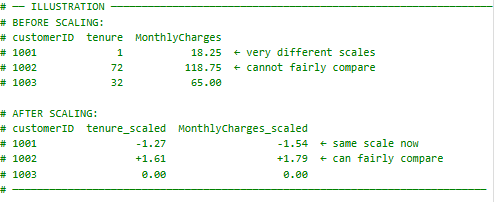

---
**The Challenge**

There are several scaling methods,
Here is what I found and
why I ruled each one out.

I always start by checking three things before choosing a scaler(**refer to Step1 Things to assess )
* skewness
* outlier count
* and whether the data range is permanently fixed

These three questions eliminate most options quickly.

**StandardScaler** was my final choice. My data showed near-zero skewness
(tenure: 0.238, MonthlyCharges: -0.222) and zero outliers on both columns.
StandardScaler is designed exactly for this profile clean, symmetric data
with no extreme values distorting the mean or standard deviation.

**RobustScaler** was my first alternative. I considered it because
MonthlyCharges has a slight skew, but after checking the outlier count
(0% on both columns), I ruled it out. RobustScaler is built to handle
outlier-heavy data — using median and IQR instead of mean and std.
On my clean data it would produce almost identical results to StandardScaler,
making it an unnecessary choice here.

**MinMaxScaler** I ruled out early. It compresses everything between 0 and 1
using the training data's min and max values. The problem is that tenure and
MonthlyCharges are not permanently bounded new customers could have tenure
values outside my training range, and pricing can change. MinMaxScaler breaks
when new data falls outside the training range, making it fragile for this use case.

**Log Transformation** was not applicable here. Log is designed to fix
right-skewed data with extreme outliers pulling the tail. My data has
near-zero skew and MonthlyCharges is actually slightly left-skewed
applying log would make that worse, not better.

**Box-Cox Transformation** I considered briefly but ruled out for two reasons.
First, it is a heavy tool designed for severe non-normality (skewness > 1.0) —
my data is already nearly normal. Second, Box-Cox breaks on zero values,
and tenure can theoretically be zero for brand new customers.

---


◼️====================================================================== Step 1: Define feature based on column groups ======================================================================

Numeric Columns: ['tenure', 'MonthlyCharges']

Categorical Columns: ['Dependents', 'payment_segment', 'Contract', 'has_support_or_security', 'service_segments', 'service_zone']

◼️====================================================================== Step 2: Assess numerical columns ======================================================================

============================= BASIC STATISTICS ============================
SECTION 1 — Summary Statistics

◼️ Table Recap (mean, median, percentile, max, std)



,tenure,MonthlyCharges
count,7032.000000,7032.000000
mean,32.421786,64.798208
std,24.545260,30.085974
min,1.000000,18.250000
25%,9.000000,35.587500
50%,29.000000,70.350000
75%,55.000000,89.862500
max,72.000000,118.750000



SECTION 2 — Per Column Diagnostics + Scaler Recommendation

◼️ tenure
   Mean        : 32.42
   Median      : 29.00
   Mean-Median : 11.8% gap
   Std         : 24.55
   Skewness    : 0.238
   Outliers    : 0 (0.0%)
   Q1 / Q3     : 9.00 / 55.00
   IQR         : 46.00
   → StandardScaler  → clean data, low skew, no outliers

◼️ MonthlyCharges
   Mean        : 64.80
   Median      : 70.35
   Mean-Median : 7.9% gap
   Std         : 30.09
   Skewness    : -0.222
   Outliers    : 0 (0.0%)
   Q1 / Q3     : 35.59 / 89.86
   IQR         : 54.27
   → StandardScaler  → clean data, low skew, no outliers

SECTION 3 — Distribution (Histogram + KDE)



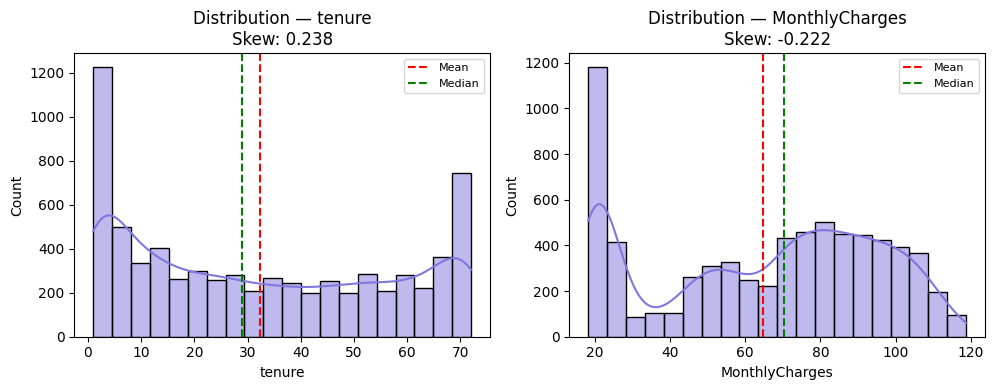

SECTION 4 — Boxplot / Outlier Detection



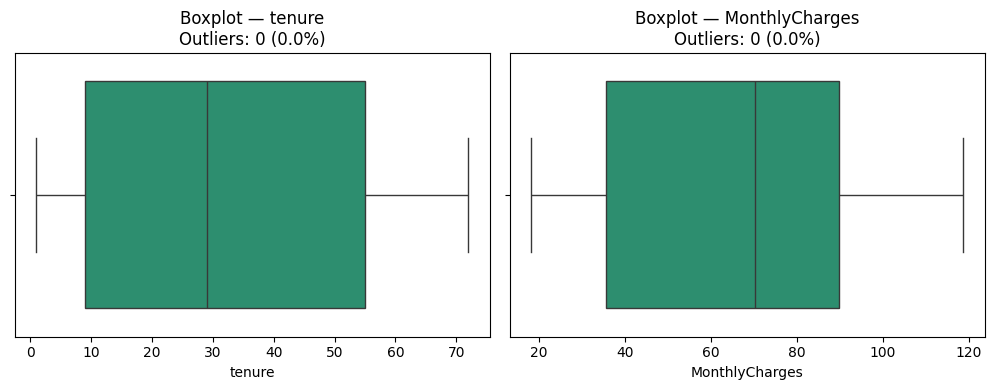

SECTION 5 — QQ Plot (Normality Check)



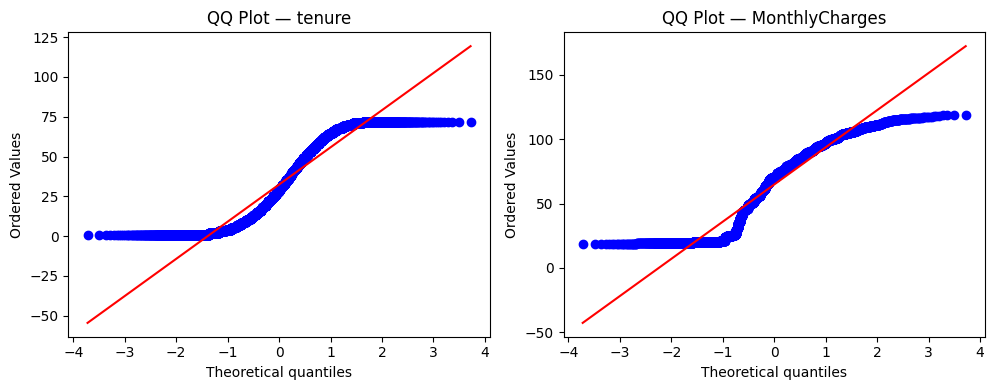

SECTION 6 — Scaler Recommendation Summary

  tenure                    → StandardScaler  → clean data, low skew, no outliers
  MonthlyCharges            → StandardScaler  → clean data, low skew, no outliers


✓ Clustering input ready
  Shape      : (7032, 8)
  Numeric    : ['tenure_scaled', 'MonthlyCharges_scaled']
  Categorical: ['Dependents', 'payment_segment', 'Contract', 'has_support_or_security', 'service_segments', 'service_zone']
Final clustering dataset shape:
  Rows     : 7,032
  Columns  : 8

Columns included:
  Numeric (scaled)  : ['tenure_scaled', 'MonthlyCharges_scaled']
  Categorical       : ['Dependents', 'payment_segment', 'Contract', 'has_support_or_security', 'service_segments', 'service_zone']

Null check:
tenure_scaled              0
MonthlyCharges_scaled      0
Dependents                 0
payment_segment            0
Contract                   0
has_support_or_security    0
service_segments           0
service_zone               0
dtype: int64

Preview:
   tenure_

In [7]:
# @title Feature Scaling (Numerical Only)
# ==================================================================================================
# LAYER 1 CUSTOMER SEGMENTATION: STATISTICAL CLUSTERING
# ==================================================================================================

# List of Feature used based on Layer 1
df_feature = src_data[[
    # numerical
    'MonthlyCharges',
    'tenure',

    # categorical
    'Dependents',
    'payment_segment',
    'Contract',
    'has_support_or_security',
    'service_segments',
    'service_zone'
]]

# ── Scale Numeric Columns ─────────────────────────────────────────────────────
# --- Step 1: Define feature -------------------------------------------------
print(f'◼️====================================================================== Step 1: Define feature based on column groups ======================================================================')
print()
numeric_cols = [
    'tenure',
    'MonthlyCharges'
]

categorical_cols = [
    'Dependents',
    'payment_segment',
    'Contract',
    'has_support_or_security',
    'service_segments',
    'service_zone'
]
print(f"Numeric Columns: {numeric_cols}")
print()
print(f"Categorical Columns: {categorical_cols}")
print()

# --- Step 2: Assess numerical columns -------------------------------------------------
# Identify which scaler is required based on distribution stats
print(f'◼️====================================================================== Step 2: Assess numerical columns ======================================================================')
print()
get_basic_statistic_for_numerical(df_feature[numeric_cols])

# --- Step 3: Scale numeric columns based on Step 2 assessment ─────────────────
scaler            = StandardScaler() # confirmed scaler choice based on step 2
df_numeric_scaled = pd.DataFrame(
    scaler.fit_transform(df_feature[numeric_cols]),
    columns = [col + '_scaled' for col in numeric_cols],
    index   = df_feature.index
)

# ── Step 4: Extract categorical columns ───────────────────────────────────────
df_categorical = df_feature[categorical_cols].copy()

# ── Step 5: Combine into final clustering dataset ─────────────────────────────
df_cluster_input = pd.concat(
    [df_numeric_scaled, df_categorical],
    axis = 1
)
# ── Step 6: Validation ────────────────────────────────────────────────────────
assert df_cluster_input.isnull().sum().sum() == 0, \
    "Null values found — check input data"

assert df_cluster_input.shape[1] == len(numeric_cols) + len(categorical_cols), \
    "Column count mismatch — check pipeline"

print(f"\n✓ Clustering input ready")
print(f"  Shape      : {df_cluster_input.shape}")
print(f"  Numeric    : {list(df_numeric_scaled.columns)}")
print(f"  Categorical: {categorical_cols}")

# ── Step 6: Sanity check ──────────────────────────────────────────────────────
print("Final clustering dataset shape:")
print(f"  Rows     : {df_cluster_input.shape[0]:,}")
print(f"  Columns  : {df_cluster_input.shape[1]}")
print()
print("Columns included:")
print(f"  Numeric (scaled)  : {list(df_numeric_scaled.columns)}")
print(f"  Categorical       : {categorical_cols}")
print()
print("Null check:")
print(df_cluster_input.isnull().sum())
print()
print("Preview:")
print(df_cluster_input.head(3).to_string())


##### **2. Determining the Number of Clusters**

---
Before running the K-Prototype algorithm, I needed to answer one critical
question first: **how many clusters should I use?**

To avoid guessing,**I combined two validation methods
Elbow Method and Silhouette Score** I deliberately used both because each one answers a different question, and relying on just one would give me an incomplete picture.

**Elbow Method** tells me *when to stop adding clusters* — it measures how
much improvement each additional cluster contributes. When the improvement
drops sharply, that is my signal to stop.

**Silhouette Score** tells me *how well the clustering actually worked* —
it measures whether each customer truly belongs in the cluster they were
assigned to, or if they are sitting on the boundary between two groups.

I found that using either method alone creates a blind spot:

- If I relied on the Elbow Method alone, I would know how many clusters
  to use, but I would have no way to confirm whether those clusters are
  actually well separated or just messy overlapping groups.

- If I relied on Silhouette Score alone, I would know the clusters are
  well defined, but I would not know if I have too many or too few of them.

By combining both, I get a more complete and confident answer. The Elbow
Method narrows down the candidate K values, and the Silhouette Score
validates whether those candidates produce genuinely distinct customer groups.



Running K-Prototype elbow search...
Testing K = [3, 4, 5, 6, 7, 8, 9]



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:  1.4min finished


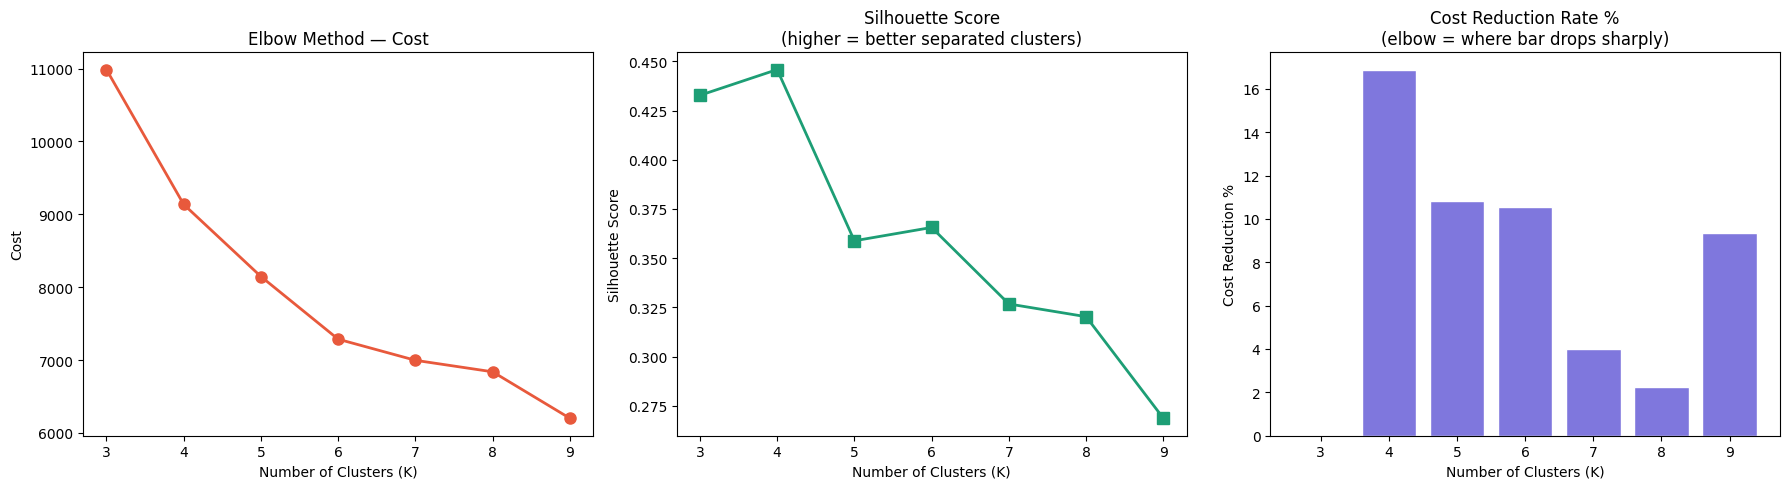

K Selection Summary:
       Cost  Cost_Reduction_%  Silhouette_Score
K                                              
3  10987.42              0.00            0.4327
4   9136.15             16.85            0.4458
5   8146.37             10.83            0.3589
6   7286.12             10.56            0.3656
7   6996.20              3.98            0.3268
8   6838.35              2.26            0.3203
9   6200.40              9.33            0.2687

Decision Guide:
  Elbow    → K where cost stops dropping sharply
  Silhouette → K with highest score
  Final K  → where both methods agree


In [8]:
# @title
# ==================================================================================================
# RUN K-PROTOTYPE : determine optimal number of clusters
# ==================================================================================================


# ----- Input data -------
# Convert to numpy
# machine learning models prefer arrays
cluster_array = df_cluster_input.to_numpy()

# Identify categorical column positions
# K-protoype does not understand column names, so need to identify which index categorical
# this logic works because we concat numerical + categorical -> hence from total numerical to total all column
categorical_idx = list(
    range(len(df_numeric_scaled.columns),
          df_cluster_input.shape[1])
)


# --- Core Logic ---
# --- Function to fit one K ----
# Extracted into function so joblib can parallelize it
def fit_kproto(k, cluster_array, categorical_idx):
    kproto = KPrototypes(
        n_clusters   = k,
        init         = 'Cao',
        n_init       = 1,      # single init for search phase, number of iteration
        random_state = 42
    )
    labels = kproto.fit_predict(
        cluster_array,
        categorical = categorical_idx
    )
    return k, kproto.cost_, labels

# ---- Parallel elbow search ----
K_range = range(3, 10)   # skip K=1 and K=2

print("Running K-Prototype elbow search...")
print(f"Testing K = {list(K_range)}")
print()

results = Parallel(n_jobs=-1, verbose=1)(
    delayed(fit_kproto)(k, cluster_array, categorical_idx)
    for k in K_range
)

# n_jobs=-1 → use ALL available CPU cores simultaneously
# verbose=1 → shows progress

# --- Unpack results ---
results     = sorted(results, key=lambda x: x[0])  # sort by K
k_values    = [r[0] for r in results]
costs       = [r[1] for r in results]
all_labels  = {r[0]: r[2] for r in results}

# -- Silhouette scores ---
# Uses only numeric columns for silhouette
# categorical columns distort euclidean distance
numeric_array = df_cluster_input.iloc[
    :, :len(df_numeric_scaled.columns)
].values

silhouette_scores = []
for k in k_values:
    labels = all_labels[k]
    if len(np.unique(labels)) > 1:   # silhouette needs at least 2 clusters
        score = silhouette_score(numeric_array, labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0)

# --- Cost reduction rate---
# Rate of improvement between consecutive K values
# Elbow = where improvement rate drops sharply
cost_reduction = [0] + [
    (costs[i-1] - costs[i]) / costs[i-1] * 100
    for i in range(1, len(costs))
]

# --- Main output ---
# --- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1 — Elbow (Cost)
axes[0].plot(k_values, costs,
             marker='o', color='#E8593C',
             linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Cost')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Cost')
axes[0].set_xticks(k_values)

# Chart 2 — Silhouette Score
axes[1].plot(k_values, silhouette_scores,
             marker='s', color='#1D9E75',
             linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score\n(higher = better separated clusters)')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_values)

# Chart 3 — Cost Reduction Rate
axes[2].bar(k_values, cost_reduction,
            color='#7F77DD', edgecolor='white')
axes[2].set_title('Cost Reduction Rate %\n(elbow = where bar drops sharply)')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Cost Reduction %')
axes[2].set_xticks(k_values)

plt.tight_layout()
plt.show()

# --- Summary table ---
summary = pd.DataFrame({
    'K'                 : k_values,
    'Cost'              : [round(c, 2) for c in costs],
    'Cost_Reduction_%'  : [round(r, 2) for r in cost_reduction],
    'Silhouette_Score'  : [round(s, 4) for s in silhouette_scores]
}).set_index('K')

print("K Selection Summary:")
print(summary.to_string())
print()
print("Decision Guide:")
print("  Elbow    → K where cost stops dropping sharply")
print("  Silhouette → K with highest score")
print("  Final K  → where both methods agree")

The numbers gave me a split signal
the Elbow Method pointed to K=6 based on cost, while the Silhouette Score pointed to K=4 based on separation quality.

Neither was a clear winner on its own, so I **picked on K=4 or K=5 as my approach.**

**My approach was to run K=4 first and profile the actual clusters before
making a final decision.  If any cluster felt too broad or contained two
clearly different customer types that should not be grouped together, I would
move to K=5 and re-evaluate.**

The reason I did not simply trust the algorithm's answer is something I
learned through experience a mathematically optimal K does not always
produce business-meaningful segments.
A cluster that looks clean on paper can still be a mix of completely different customer behaviors that would require different retention strategies.

**Why K=5 and not K=6?**

K=5 sits between both signals and makes the most business sense.
The cost still drops 10.83% from K=4 to K=5 which is a meaningful improvement,
the Silhouette Score of 0.3589 shows acceptable separation, and 5 clusters
maps naturally to real telco segments.

---

##### **3. Run K-prototype Clusters based on input from step Feature scaling and optimal number of clusters**

**Objective:**

To identify the K-Prototypes cluster configuration that best aligns with business understanding by evaluating cluster distribution and basic statistical characteristics


Fitting K=4...
  K=4 done — Cost: 9136.15
Fitting K=5...
  K=5 done — Cost: 8146.37

Both models fitted successfully
K=4 Profile:
cluster_label  size  pct_of_base  churn_rate_pct  lift  avg_tenure  avg_monthly
        K4_C0  2789         39.7            45.0  1.69       16.17        76.67
        K4_C1   921         13.1             4.0  0.15       54.75        28.24
        K4_C2  1334         19.0            23.0  0.87       10.60        26.62
        K4_C3  1988         28.3            13.0  0.49       59.52        90.70

K=5 Profile:
cluster_label  size  pct_of_base  churn_rate_pct  lift  avg_tenure  avg_monthly
        K5_C0  1657         23.6            11.0  0.41       62.49        91.78
        K5_C1  1561         22.2            53.0  1.99        7.25        67.30
        K5_C2  1148         16.3            18.0  0.68       11.92        23.31
        K5_C3   883         12.6             4.0  0.15       55.49        27.89
        K5_C4  1783         25.4            34.0  1.28  

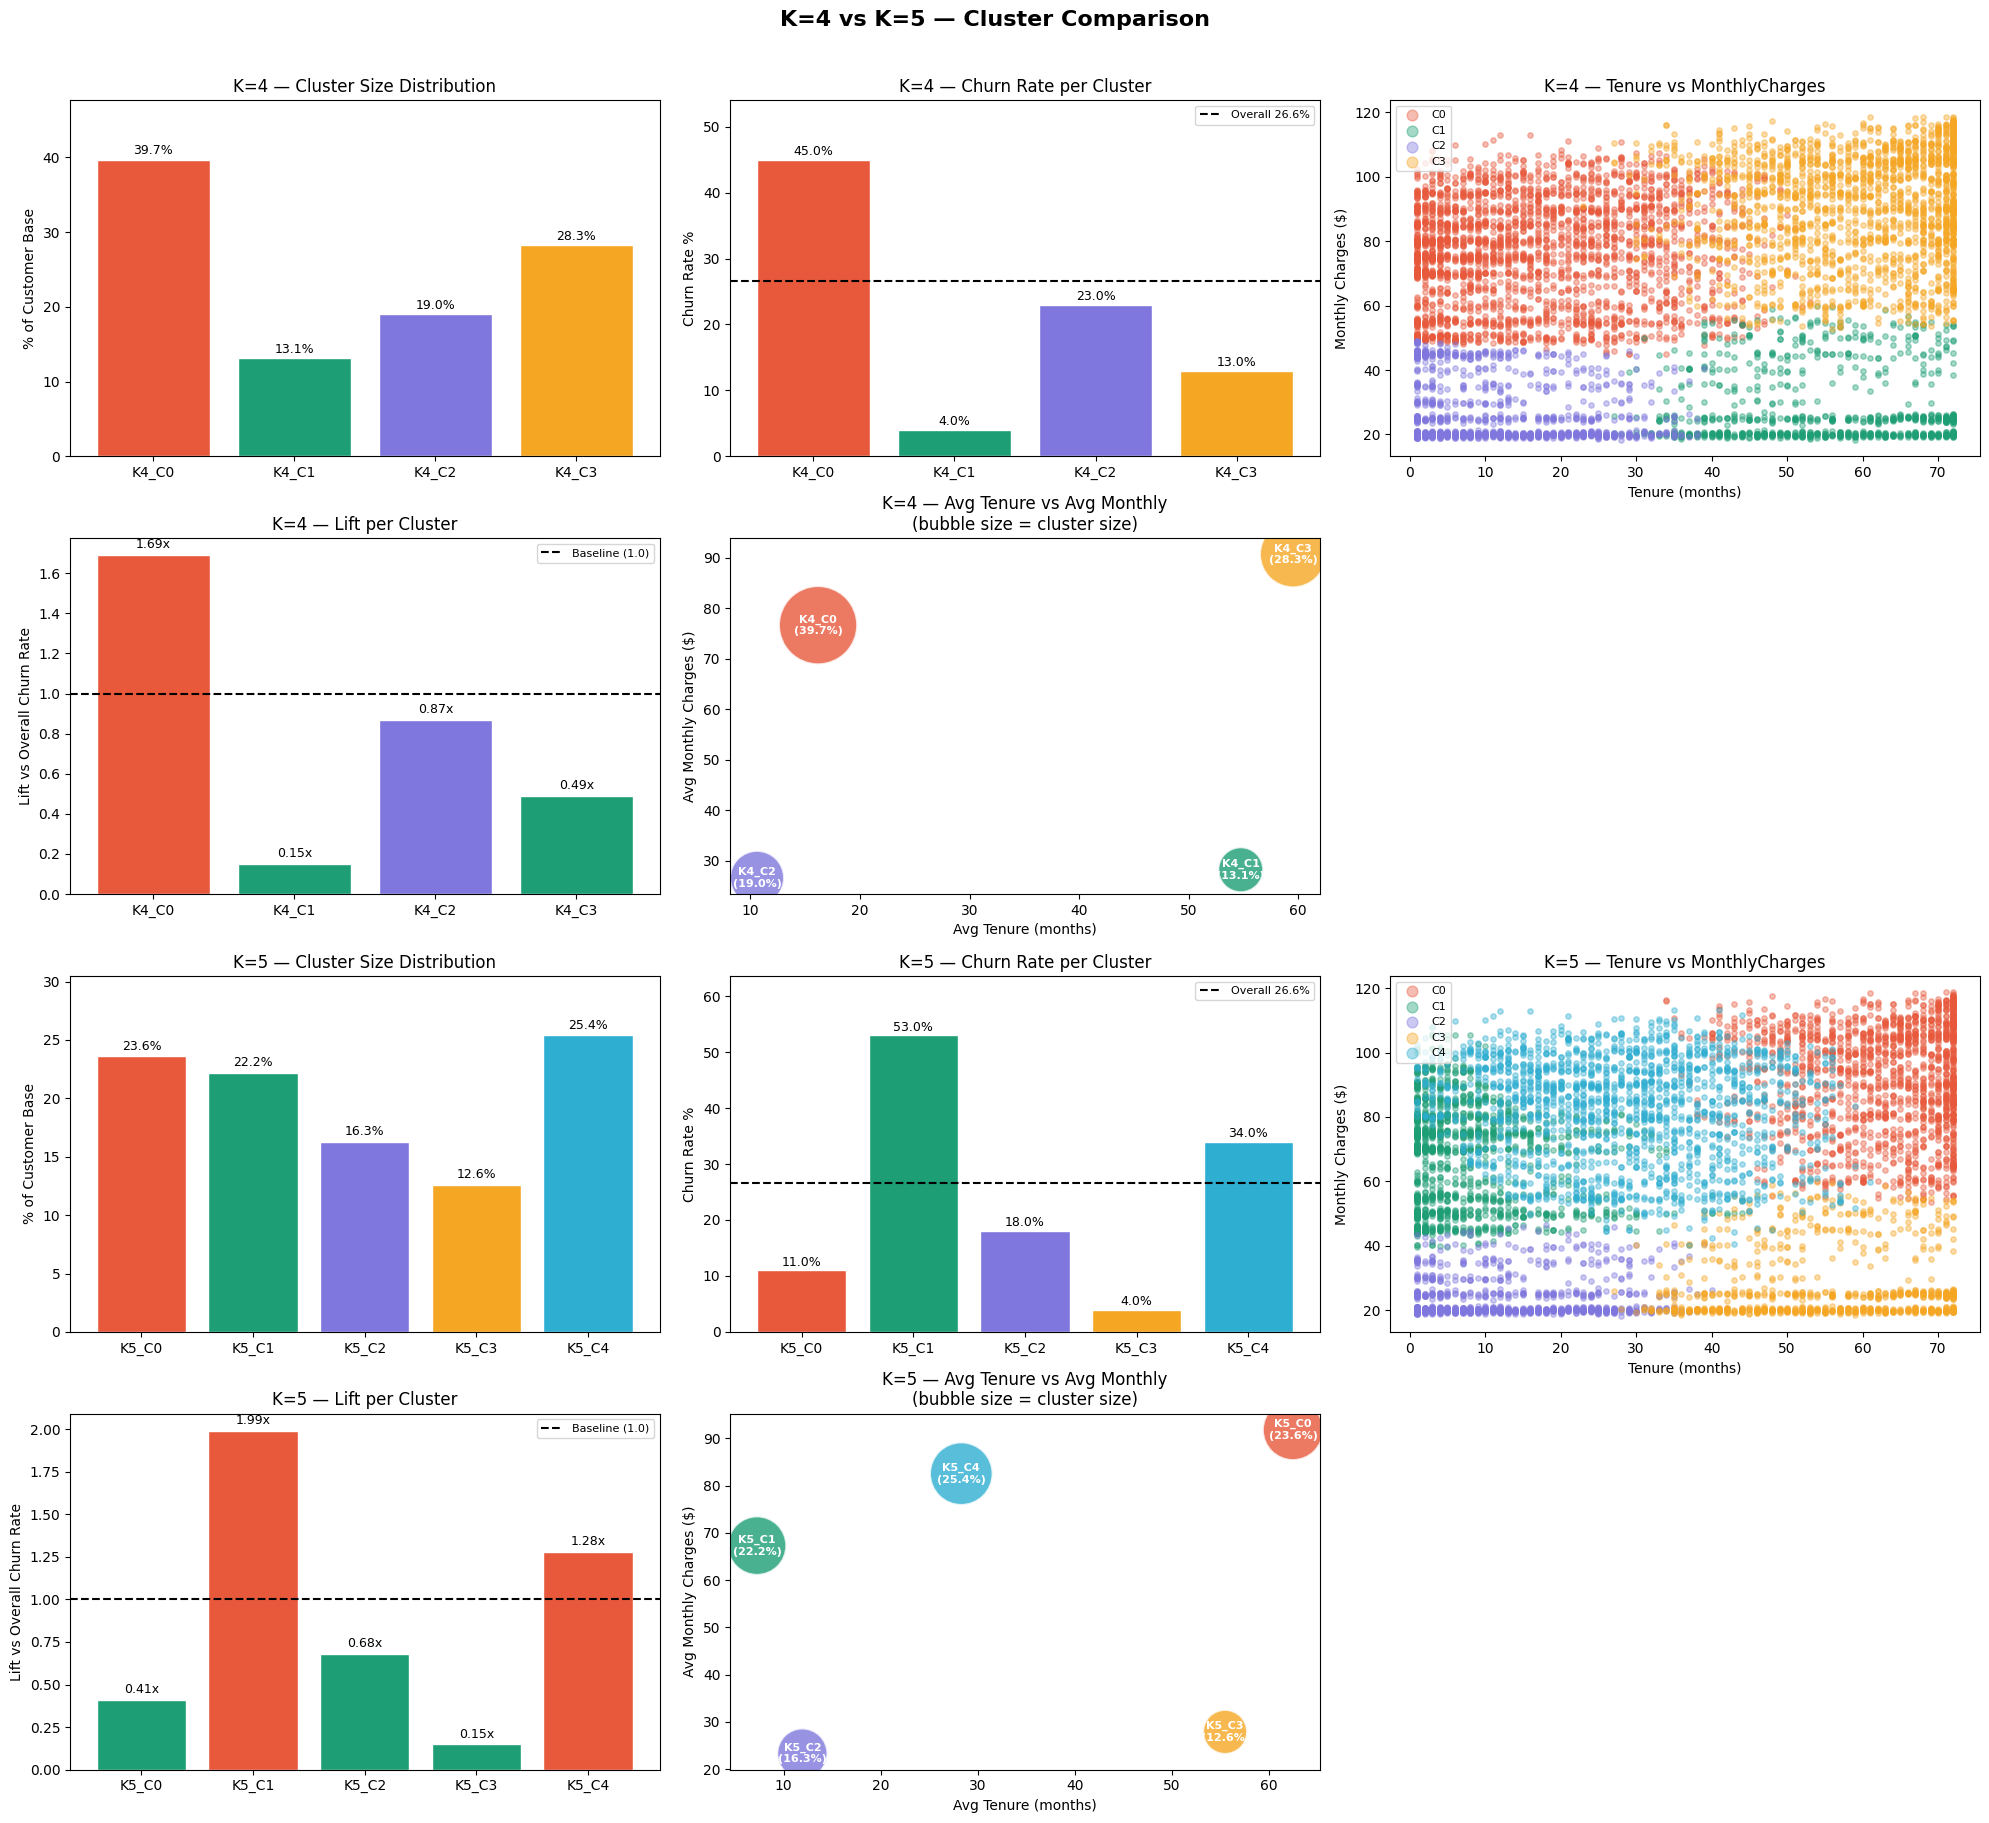

SIDE BY SIDE COMPARISON SUMMARY

K=4
  Cost            : 9136.15
  Cluster sizes   : [39.7, 13.1, 19.0, 28.3] %
  Churn rates     : [45.0, 4.0, 23.0, 13.0] %
  Lift range      : 0.15x — 1.69x
  Smallest cluster: 13.1% (921 customers)
  ✅ All clusters >= 3% — actionable sizes

K=5
  Cost            : 8146.37
  Cluster sizes   : [23.6, 22.2, 16.3, 12.6, 25.4] %
  Churn rates     : [11.0, 53.0, 18.0, 4.0, 34.0] %
  Lift range      : 0.15x — 1.99x
  Smallest cluster: 12.6% (883 customers)
  ✅ All clusters >= 3% — actionable sizes


In [9]:
# @title
# ==================================================================================================
# RUN K-PROTOTYPE : Compare and experiment based on step 1
# ==================================================================================================

# ── Config ────────────────────────────────────────────────────────────────────
K_CANDIDATES  = [4, 5]
RANDOM_STATE  = 42

categorical_idx = list(
    range(len(df_numeric_scaled.columns),
          df_cluster_input.shape[1])
)

cluster_array = df_cluster_input.to_numpy()

# ── Step 1: Fit both models ───────────────────────────────────────────────────
models = {}
labels = {}

for k in K_CANDIDATES:
    print(f"Fitting K={k}...")

    kproto = KPrototypes(
        n_clusters   = k,
        init         = 'Cao',
        random_state = RANDOM_STATE,
        verbose      = 0
    )

    labels[k] = kproto.fit_predict(
        cluster_array,
        categorical = categorical_idx
    )

    models[k] = kproto
    print(f"  K={k} done — Cost: {kproto.cost_:.2f}")

print()
print("Both models fitted successfully")

# ── Step 2: Build cluster profile per K ──────────────────────────────────────
def build_cluster_profile(k, label_array, src):
    '''
    For each cluster → compute key metrics
    used for comparison and visualization
    '''
    src = src.copy()
    src['cluster'] = label_array

    profile = src.groupby('cluster').agg(
        size             = ('churn_flag', 'count'),
        churn_rate       = ('churn_flag', 'mean'),
        avg_tenure       = ('tenure', 'mean'),
        avg_monthly      = ('MonthlyCharges', 'mean'),
    ).round(2)

    profile['pct_of_base']      = (profile['size'] / len(src) * 100).round(1)
    profile['lift']             = (profile['churn_rate'] / src['churn_flag'].mean()).round(2)
    profile['churn_rate_pct']   = (profile['churn_rate'] * 100).round(1)
    profile['K']                = k
    profile['cluster_label']    = [f"K{k}_C{i}" for i in profile.index]

    return profile.reset_index()

# Build profiles using src_data which has original columns + churn_flag
profile_k4 = build_cluster_profile(4, labels[4], src_data)
profile_k5 = build_cluster_profile(5, labels[5], src_data)

print("K=4 Profile:")
print(profile_k4[['cluster_label', 'size', 'pct_of_base',
                   'churn_rate_pct', 'lift',
                   'avg_tenure', 'avg_monthly']].to_string(index=False))
print()
print("K=5 Profile:")
print(profile_k5[['cluster_label', 'size', 'pct_of_base',
                   'churn_rate_pct', 'lift',
                   'avg_tenure', 'avg_monthly']].to_string(index=False))

# ── Step 3: Visualization ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
fig.suptitle('K=4 vs K=5 — Cluster Comparison',
             fontsize=16, fontweight='bold', y=1.01)

overall_churn = src_data['churn_flag'].mean() * 100

# ── Color palettes per K ──────────────────────────────────────────────────────
colors_k4 = ['#E8593C', '#1D9E75', '#7F77DD', '#F5A623']
colors_k5 = ['#E8593C', '#1D9E75', '#7F77DD', '#F5A623', '#2EAED1']

for row, (k, profile, colors) in enumerate(
    [(4, profile_k4, colors_k4),
     (5, profile_k5, colors_k5)]
):
    base_row = row * 2   # 2 rows of charts per K

    # ── Chart 1 — Cluster Size Distribution ──────────────────────────────────
    ax1 = fig.add_subplot(4, 3, base_row * 3 + 1)
    bars = ax1.bar(
        profile['cluster_label'],
        profile['pct_of_base'],
        color  = colors,
        edgecolor = 'white'
    )
    for bar, val in zip(bars, profile['pct_of_base']):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val}%', ha='center', va='bottom', fontsize=9)

    ax1.set_title(f'K={k} — Cluster Size Distribution')
    ax1.set_ylabel('% of Customer Base')
    ax1.set_ylim(0, profile['pct_of_base'].max() * 1.2)

    # ── Chart 2 — Churn Rate per Cluster ─────────────────────────────────────
    ax2 = fig.add_subplot(4, 3, base_row * 3 + 2)
    bars = ax2.bar(
        profile['cluster_label'],
        profile['churn_rate_pct'],
        color     = colors,
        edgecolor = 'white'
    )
    ax2.axhline(y      = overall_churn,
                color  = 'black',
                linestyle = '--',
                linewidth = 1.5,
                label  = f'Overall {overall_churn:.1f}%')

    for bar, val in zip(bars, profile['churn_rate_pct']):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val}%', ha='center', va='bottom', fontsize=9)

    ax2.set_title(f'K={k} — Churn Rate per Cluster')
    ax2.set_ylabel('Churn Rate %')
    ax2.set_ylim(0, max(profile['churn_rate_pct'].max() * 1.2, 50))
    ax2.legend(fontsize=8)

    # ── Chart 3 — Tenure vs MonthlyCharges Scatter ───────────────────────────
    ax3 = fig.add_subplot(4, 3, base_row * 3 + 3)

    src_plot        = src_data.copy()
    src_plot['cluster'] = labels[k]

    for cluster_id, color in zip(sorted(src_plot['cluster'].unique()), colors):
        mask = src_plot['cluster'] == cluster_id
        ax3.scatter(
            src_plot[mask]['tenure'],
            src_plot[mask]['MonthlyCharges'],
            c       = color,
            alpha   = 0.4,
            s       = 15,
            label   = f'C{cluster_id}'
        )

    ax3.set_title(f'K={k} — Tenure vs MonthlyCharges')
    ax3.set_xlabel('Tenure (months)')
    ax3.set_ylabel('Monthly Charges ($)')
    ax3.legend(fontsize=8, markerscale=2)

    # ── Chart 4 — Lift per Cluster ────────────────────────────────────────────
    ax4 = fig.add_subplot(4, 3, base_row * 3 + 4)
    bar_colors = [
        '#E8593C' if l > 1.2 else
        '#1D9E75' if l < 0.8 else
        '#7F77DD'
        for l in profile['lift']
    ]
    bars = ax4.bar(
        profile['cluster_label'],
        profile['lift'],
        color     = bar_colors,
        edgecolor = 'white'
    )
    ax4.axhline(y=1.0, color='black', linestyle='--',
                linewidth=1.5, label='Baseline (1.0)')

    for bar, val in zip(bars, profile['lift']):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val}x', ha='center', va='bottom', fontsize=9)

    ax4.set_title(f'K={k} — Lift per Cluster')
    ax4.set_ylabel('Lift vs Overall Churn Rate')
    ax4.legend(fontsize=8)

    # ── Chart 5 — Avg Tenure vs Avg Monthly Charges Bubble ───────────────────
    ax5 = fig.add_subplot(4, 3, base_row * 3 + 5)
    scatter = ax5.scatter(
        profile['avg_tenure'],
        profile['avg_monthly'],
        s         = profile['pct_of_base'] * 80,   # bubble size = cluster size
        c         = colors[:len(profile)],
        alpha     = 0.8,
        edgecolors= 'white',
        linewidth = 1.5
    )

    for _, row_data in profile.iterrows():
        ax5.annotate(
            f"{row_data['cluster_label']}\n({row_data['pct_of_base']}%)",
            xy         = (row_data['avg_tenure'], row_data['avg_monthly']),
            ha         = 'center',
            va         = 'center',
            fontsize   = 8,
            fontweight = 'bold',
            color      = 'white'
        )

    ax5.set_title(f'K={k} — Avg Tenure vs Avg Monthly\n(bubble size = cluster size)')
    ax5.set_xlabel('Avg Tenure (months)')
    ax5.set_ylabel('Avg Monthly Charges ($)')

plt.tight_layout()
plt.show()

# ── Step 4: Side by side summary table ───────────────────────────────────────
print("=" * 70)
print("SIDE BY SIDE COMPARISON SUMMARY")
print("=" * 70)

for k, profile in [(4, profile_k4), (5, profile_k5)]:
    print(f"\nK={k}")
    print(f"  Cost            : {models[k].cost_:.2f}")
    print(f"  Cluster sizes   : {profile['pct_of_base'].tolist()} %")
    print(f"  Churn rates     : {profile['churn_rate_pct'].tolist()} %")
    print(f"  Lift range      : {profile['lift'].min():.2f}x — {profile['lift'].max():.2f}x")
    print(f"  Smallest cluster: {profile['pct_of_base'].min():.1f}% ({profile['size'].min():,} customers)")

    # Flag if any cluster is too small
    if profile['pct_of_base'].min() < 3:
        print(f"  ⚠️  Warning: smallest cluster < 3% — may be too small to act on")
    else:
        print(f"  ✅ All clusters >= 3% — actionable sizes")

**The Final Number of clusters selected was K=5**

* **Looking at the numbers, K=4 had one cluster
carrying nearly 40% of all customers with a 45% churn rate, which told me
that cluster was doing too much** it was clearly mixing two different types
of customers together. That is not something I can build a focused retention
strategy around.

* When I moved to K=5, that oversized cluster split into two groups: one at
53% churn and another at 34% churn. A **19 percentage point difference between
them is not a marginal change these are genuinely different customer**
behaviors that K=4 was incorrectly treating as one group.

*  **K=5 more balance overall.** No cluster dominated the others, the largest was 25% of the base, and **the churn rates spread cleanly from 4% all the way to 53%.** Each cluster felt like it was telling its own story, which is exactly what I need when I design different retention approaches for each group.

---


##### **4. Evaluate The Clusters**

**Objective:**

After deciding on the final cluster configuration, I re-assign the cluster labels from the K-Prototypes result back to the original dataset. **From there, I explore each cluster using the full set of original features to understand the underlying patterns, behaviors, and characteristics behind each customer persona.** **The goal is** not only to validate the statistical grouping, but also **to assess whether the segments make sense from a business perspective** and can be translated into meaningful, actionable insights.

--------------------------------------------------------------------
SECTION 1 — HIGH LEVEL CLUSTER SUMMARY
--------------------------------------------------------------------



,total_customers,pct_of_base,churn_rate_pct,lift,avg_tenure,avg_monthly,total_monthly_rev,rev_at_risk,risk_signal
cluster,,,,,,,,,
0,1657,23.6,11.0,0.41,62.49,91.78,152081.00,18609.85,💎 Very Loyal
1,1561,22.2,53.0,1.99,7.25,67.30,105050.35,59334.60,🔴 High Risk
2,1148,16.3,18.0,0.68,11.92,23.31,26759.20,5353.50,🟢 Low Risk
3,883,12.6,4.0,0.15,55.49,27.89,24625.50,1249.65,💎 Very Loyal
4,1783,25.4,34.0,1.28,28.30,82.53,147144.95,54583.25,🟡 Moderate Risk



--------------------------------------------------------------------
SECTION 2 — NUMERIC PROFILE PER CLUSTER
--------------------------------------------------------------------

◼ tenure


,mean,median,std,min,max
cluster,,,,,
0,62.49,65.0,8.80,34,72
1,7.25,5.0,7.47,1,44
2,11.92,10.0,10.04,1,40
3,55.49,56.0,12.00,27,72
4,28.30,28.0,13.14,1,61



◼ MonthlyCharges


...


◼ service_segments


service_segments,InternetOnly,Phone & Internet,PhoneOnly,dominant
cluster,,,,
0,3.9,96.1,0.0,Phone & Internet
1,4.2,95.8,0.0,Phone & Internet
2,23.9,0.0,76.1,PhoneOnly
3,22.8,4.1,73.2,PhoneOnly
4,4.2,95.8,0.0,Phone & Internet



◼ service_zone


service_zone,zone1_minimal,zone2-3_danger,zone4-6_transition,zone7-9_embedded,dominant
cluster,,,,,
0,0.0,1.0,36.3,62.7,zone7-9_embedded
1,0.0,65.6,33.2,1.2,zone2-3_danger
2,74.1,23.1,2.8,0.0,zone1_minimal
3,46.3,37.4,16.3,0.0,zone1_minimal
4,0.0,3.8,83.9,12.3,zone4-6_transition




--------------------------------------------------------------------
SECTION 4 — CLUSTER VISUALIZATION
--------------------------------------------------------------------



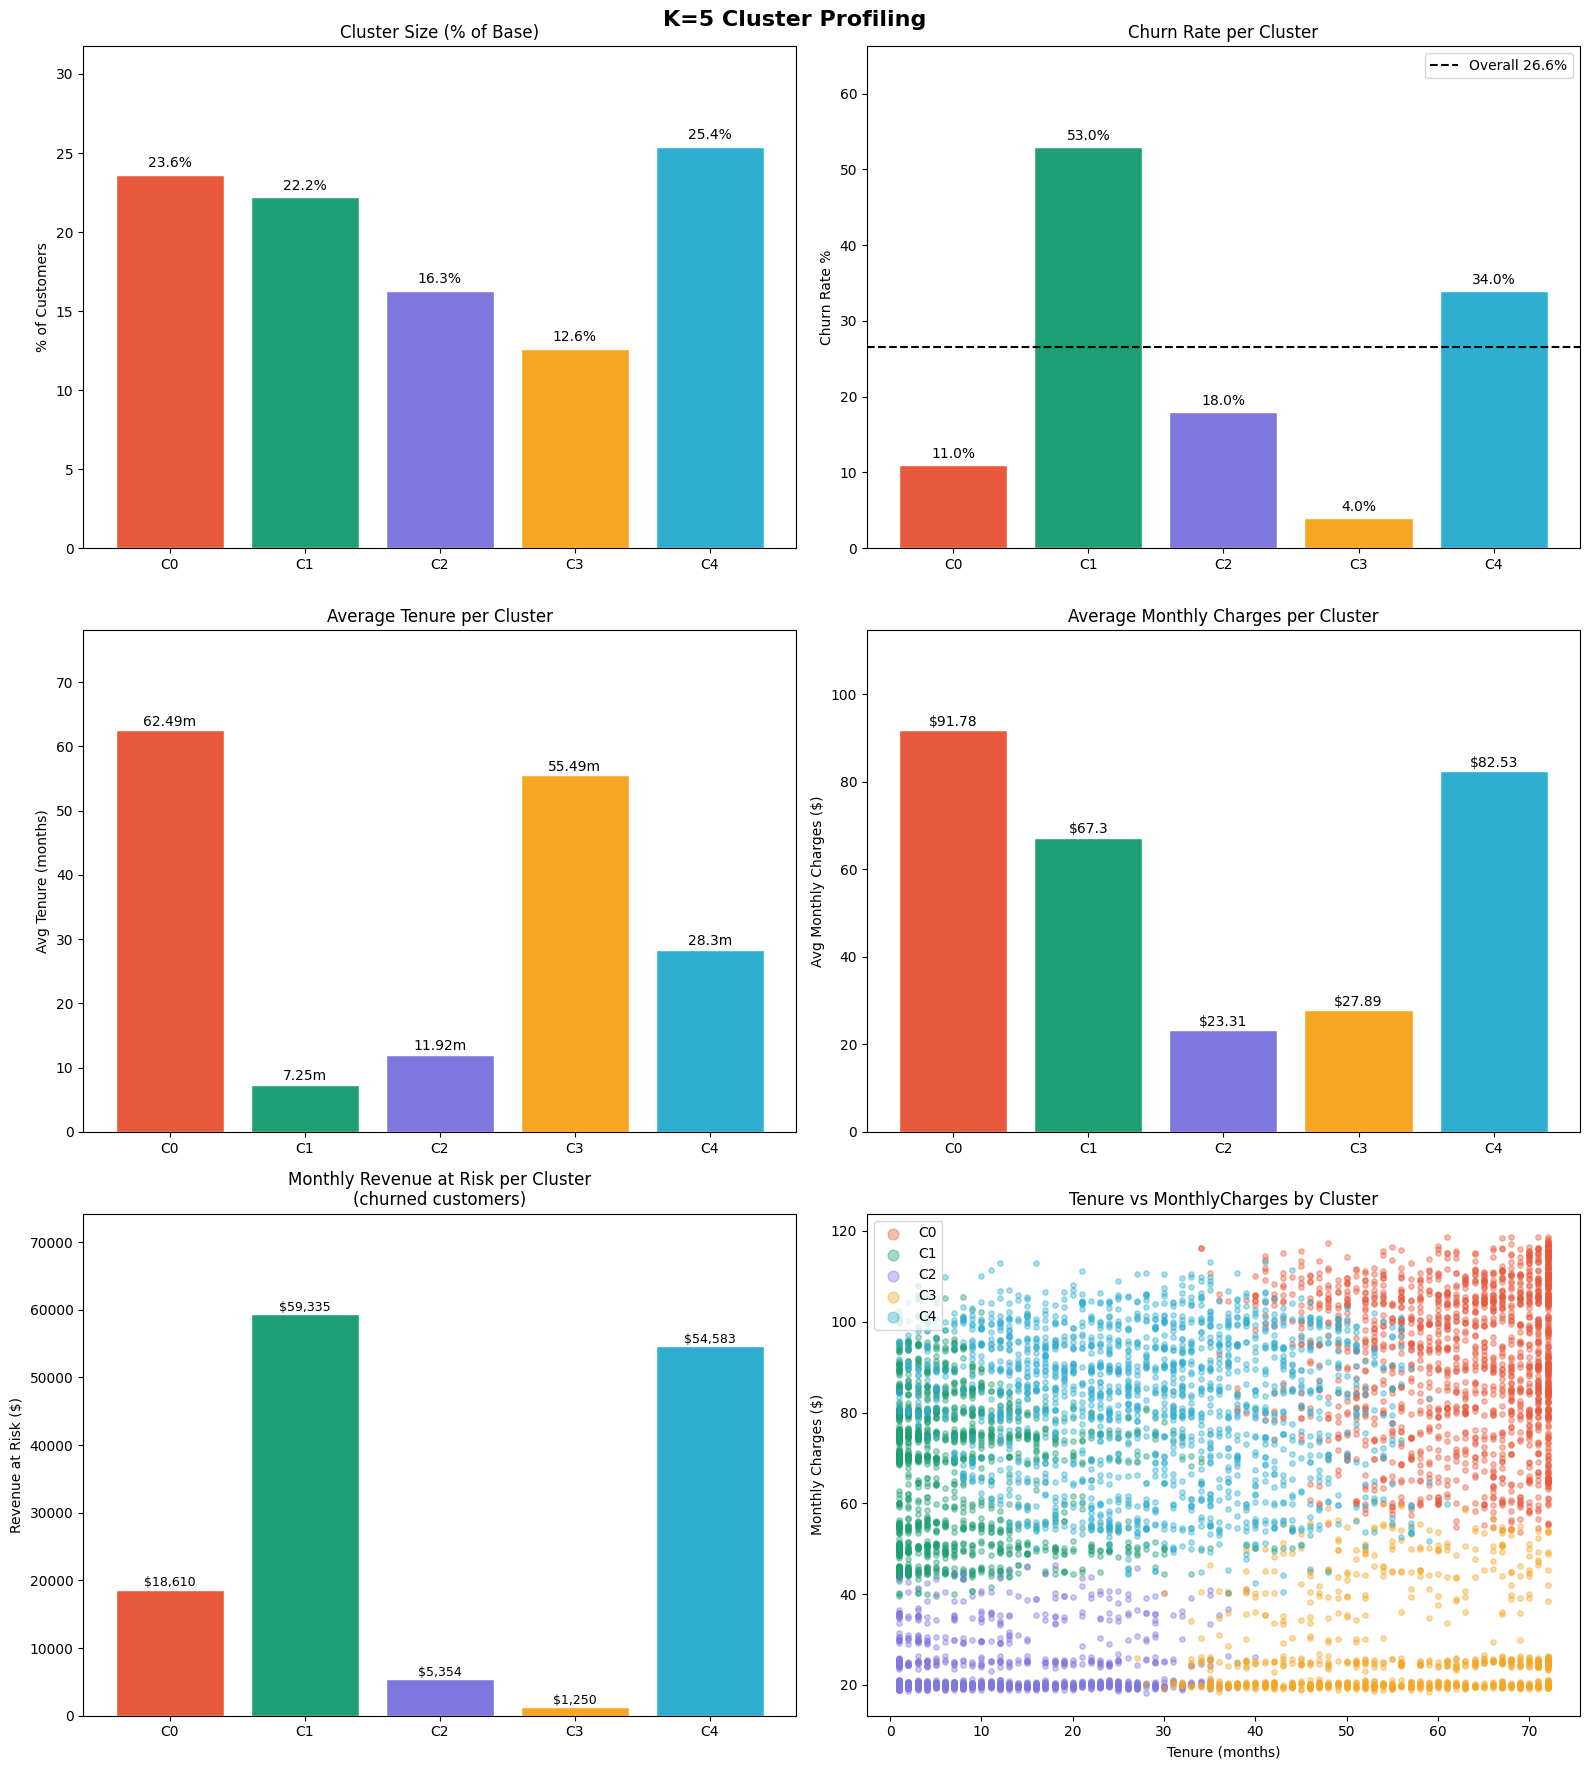


--------------------------------------------------------------------
SECTION 5 — CATEGORICAL DISTRIBUTION CHARTS
--------------------------------------------------------------------



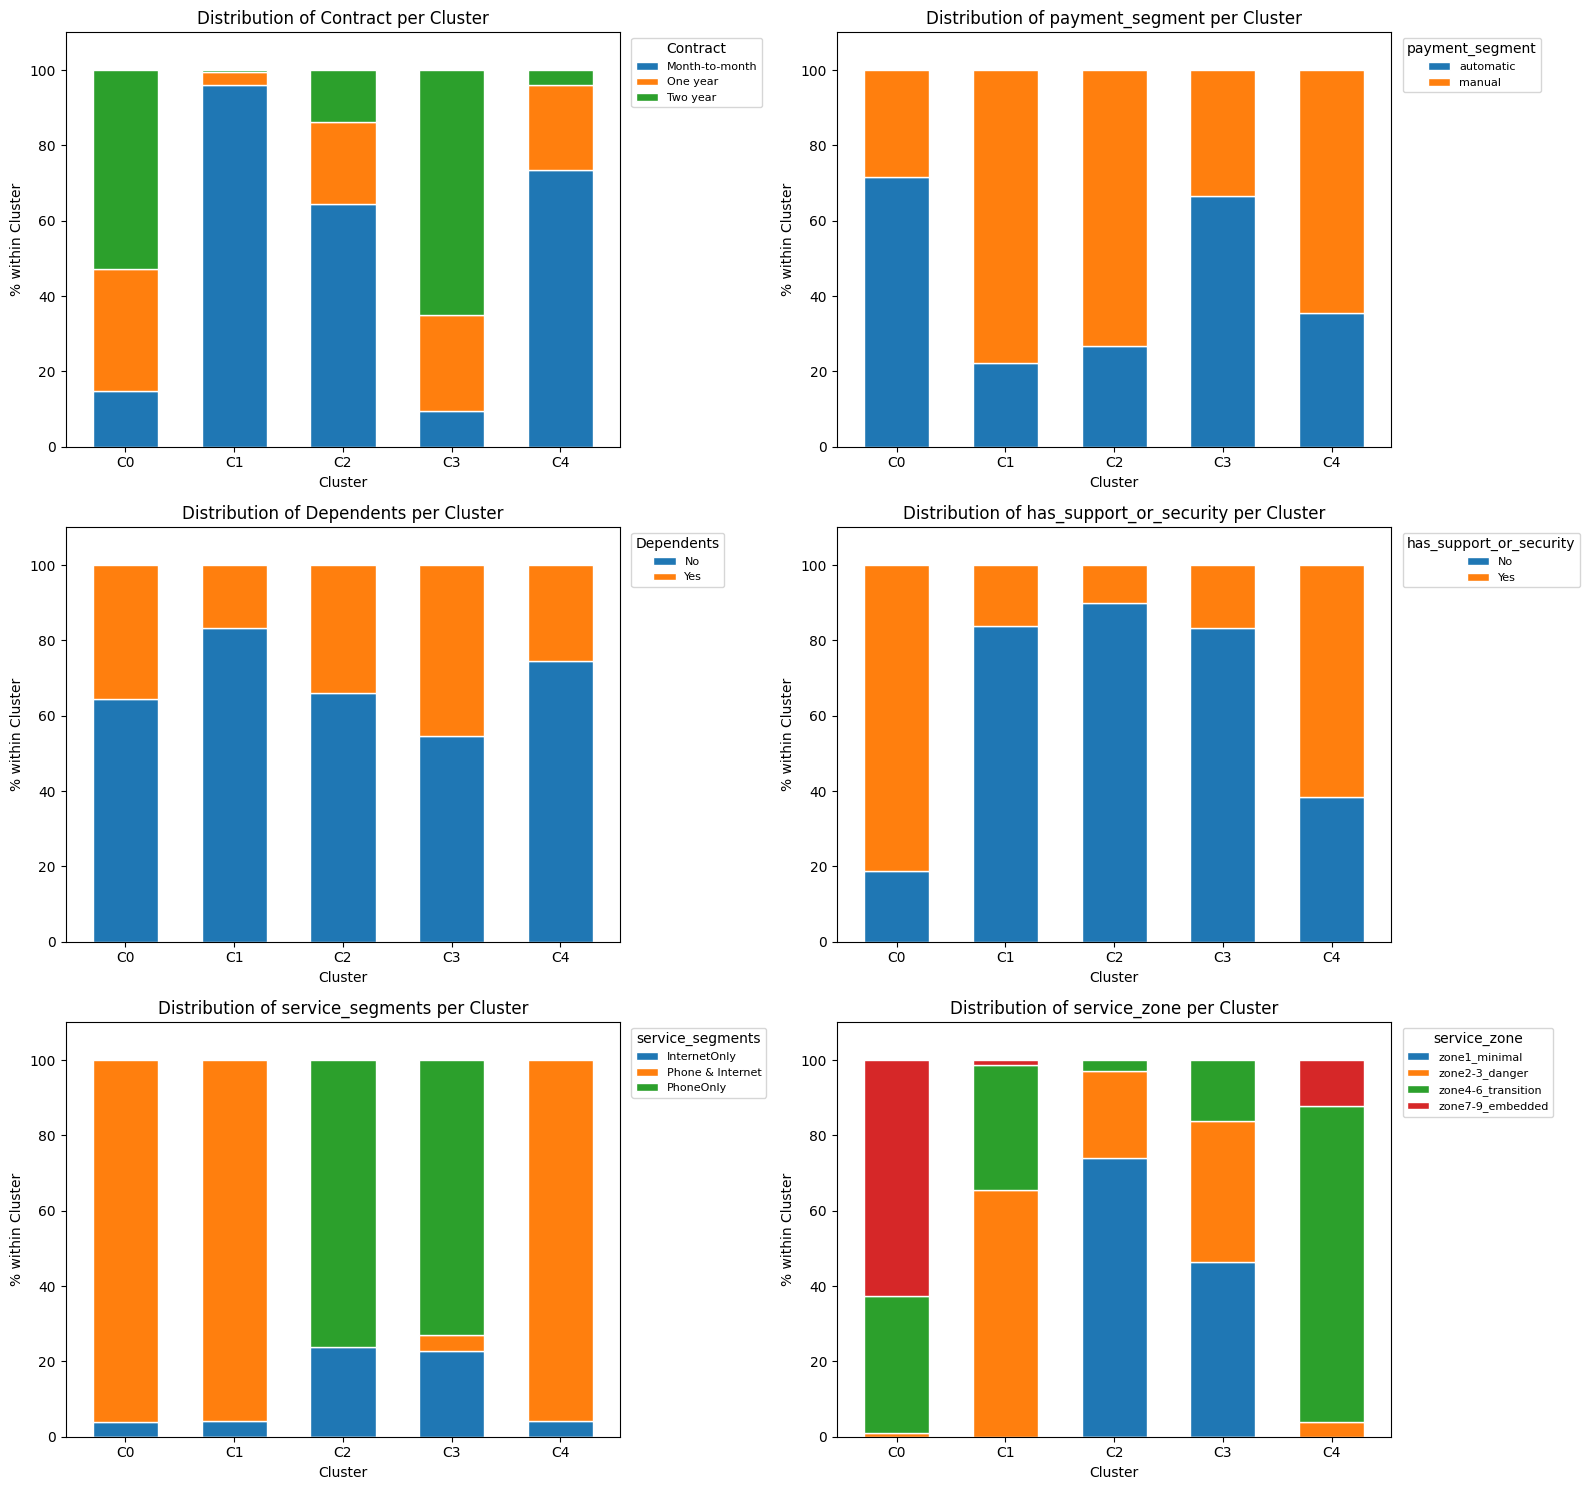


--------------------------------------------------------------------
SECTION 6 — CLUSTER IDENTITY CARD
--------------------------------------------------------------------

Cluster 0
  Size             : 1,657 customers (23.6% of base)
  Churn Rate       : 11.2%
  Lift             : 0.42x
  Avg Tenure       : 62.5 months
  Avg Monthly      : $91.78
  Top Contract     : Two year
  Top Payment      : automatic
  Top Service      : Phone & Internet
  Top Zone         : zone7-9_embedded

Cluster 1
  Size             : 1,561 customers (22.2% of base)
  Churn Rate       : 53.2%
  Lift             : 2.00x
  Avg Tenure       : 7.2 months
  Avg Monthly      : $67.30
  Top Contract     : Month-to-month
  Top Payment      : manual
  Top Service      : Phone & Internet
  Top Zone         : zone2-3_danger

Cluster 2
  Size             : 1,148 customers (16.3% of base)
  Churn Rate       : 18.1%
  Lift             : 0.68x
  Avg Tenure       : 11.9 months
  Avg Monthly      : $23.31
  Top Contract  

In [10]:
# @title
# ==================================================================================================
# Evaluate Clusters based on Final Configuration
# ==================================================================================================


# --- Assign K=5 cluster labels back to source data ---
# add the cluster result back to the original dataframe
# profile using all original columns not just the features we clustered on

src_data['cluster'] = labels[5]

# --- Color palette for 5 clusters ---
CLUSTER_COLORS = {
    0 : '#E8593C',   # coral
    1 : '#1D9E75',   # teal
    2 : '#7F77DD',   # purple
    3 : '#F5A623',   # orange
    4 : '#2EAED1'    # blue
}

overall_churn_rate = src_data['churn_flag'].mean()

# --- Define which columns to profile and their type ---
# Scalable — add or remove columns here without changing anything else

numeric_profile_cols = [
    'tenure',
    'MonthlyCharges',
]

categorical_profile_cols = [
    'Contract',
    'payment_segment',
    'Dependents',
    'has_support_or_security',
    'service_segments',
    'service_zone'
]

# ---
# SECTION 1 — HIGH LEVEL CLUSTER SUMMARY
# Core metrics per cluster — size, churn rate, lift, revenue
# ---

print("--------------------------------------------------------------------")
print("SECTION 1 — HIGH LEVEL CLUSTER SUMMARY")
print("--------------------------------------------------------------------")
print()

cluster_summary = src_data.groupby('cluster').agg(
    total_customers  = ('churn_flag', 'count'),
    churned          = ('churn_flag', 'sum'),
    churn_rate       = ('churn_flag', 'mean'),
    avg_tenure       = ('tenure', 'mean'),
    avg_monthly      = ('MonthlyCharges', 'mean'),
    total_monthly_rev= ('MonthlyCharges', 'sum')
).round(2)

cluster_summary['pct_of_base']    = (
    cluster_summary['total_customers'] / len(src_data) * 100
).round(1)

cluster_summary['lift']           = (
    cluster_summary['churn_rate'] / overall_churn_rate
).round(2)

cluster_summary['churn_rate_pct'] = (
    cluster_summary['churn_rate'] * 100
).round(1)

cluster_summary['rev_at_risk']    = (
    src_data[src_data['churn_flag'] == 1]
    .groupby('cluster')['MonthlyCharges']
    .sum()
    .round(2)
)

# Signal label based on lift
cluster_summary['risk_signal'] = np.select(
    [cluster_summary['lift'] >= 1.5,
     cluster_summary['lift'] >= 1.2,
     cluster_summary['lift'] <= 0.5,
     cluster_summary['lift'] <= 0.8],
    ['🔴 High Risk',
     '🟡 Moderate Risk',
     '💎 Very Loyal',
     '🟢 Low Risk'],
    default = '⚪ Near Average'
)

display(cluster_summary[[
    'total_customers', 'pct_of_base', 'churn_rate_pct',
    'lift', 'avg_tenure', 'avg_monthly',
    'total_monthly_rev', 'rev_at_risk', 'risk_signal'
]])

# ---
# SECTION 2 — NUMERIC COLUMN PROFILE PER CLUSTER
# Mean, median, std of each numeric feature broken down by cluster
# ---

print()
print("--------------------------------------------------------------------")
print("SECTION 2 — NUMERIC PROFILE PER CLUSTER")
print("--------------------------------------------------------------------")
print()

for col in numeric_profile_cols:
    print(f"◼ {col}")

    num_profile = src_data.groupby('cluster')[col].agg(
        mean   = 'mean',
        median = 'median',
        std    = 'std',
        min    = 'min',
        max    = 'max'
    ).round(2)

    display(num_profile)
    print()

# ---
# SECTION 3 — CATEGORICAL COLUMN PROFILE PER CLUSTER
# Dominant category and distribution % per cluster
# ---

print()
print("--------------------------------------------------------------------")
print("SECTION 3 — CATEGORICAL PROFILE PER CLUSTER")
print("--------------------------------------------------------------------")
print()

for col in categorical_profile_cols:
    print(f"◼ {col}")

    cat_profile = (
        src_data.groupby(['cluster', col])
        .size()
        .reset_index(name='count')
    )

    cat_profile['pct'] = (
        cat_profile.groupby('cluster')['count']
        .transform(lambda x: x / x.sum() * 100)
    ).round(1)

    # Pivot for easy reading — clusters as rows, categories as columns
    cat_pivot = cat_profile.pivot_table(
        index   = 'cluster',
        columns = col,
        values  = 'pct',
        fill_value = 0
    ).round(1)

    # Add dominant category column
    cat_pivot['dominant'] = cat_pivot.idxmax(axis=1)

    display(cat_pivot)
    print()

# ---
# SECTION 4 — VISUALIZATION
# One chart per key metric to visually compare clusters
# ---

print()
print("--------------------------------------------------------------------")
print("SECTION 4 — CLUSTER VISUALIZATION")
print("--------------------------------------------------------------------")
print()

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('K=5 Cluster Profiling',
             fontsize=16, fontweight='bold')

cluster_ids = sorted(src_data['cluster'].unique())
colors      = [CLUSTER_COLORS[c] for c in cluster_ids]

# --- Chart 1 — Cluster Size ---
ax = axes[0, 0]
bars = ax.bar(
    [f'C{c}' for c in cluster_ids],
    cluster_summary['pct_of_base'],
    color     = colors,
    edgecolor = 'white'
)
for bar, val in zip(bars, cluster_summary['pct_of_base']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Cluster Size (% of Base)')
ax.set_ylabel('% of Customers')
ax.set_ylim(0, cluster_summary['pct_of_base'].max() * 1.25)

# --- Chart 2 — Churn Rate per Cluster ---
ax = axes[0, 1]
bars = ax.bar(
    [f'C{c}' for c in cluster_ids],
    cluster_summary['churn_rate_pct'],
    color     = colors,
    edgecolor = 'white'
)
ax.axhline(y         = overall_churn_rate * 100,
           color     = 'black',
           linestyle = '--',
           linewidth = 1.5,
           label     = f'Overall {overall_churn_rate*100:.1f}%')
for bar, val in zip(bars, cluster_summary['churn_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Churn Rate per Cluster')
ax.set_ylabel('Churn Rate %')
ax.set_ylim(0, cluster_summary['churn_rate_pct'].max() * 1.25)
ax.legend()

# --- Chart 3 — Average Tenure per Cluster ---
ax = axes[1, 0]
bars = ax.bar(
    [f'C{c}' for c in cluster_ids],
    cluster_summary['avg_tenure'],
    color     = colors,
    edgecolor = 'white'
)
for bar, val in zip(bars, cluster_summary['avg_tenure']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}m', ha='center', va='bottom', fontsize=10)
ax.set_title('Average Tenure per Cluster')
ax.set_ylabel('Avg Tenure (months)')
ax.set_ylim(0, cluster_summary['avg_tenure'].max() * 1.25)

#--- Chart 4 — Average Monthly Charges per Cluster ---
ax = axes[1, 1]
bars = ax.bar(
    [f'C{c}' for c in cluster_ids],
    cluster_summary['avg_monthly'],
    color     = colors,
    edgecolor = 'white'
)
for bar, val in zip(bars, cluster_summary['avg_monthly']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'${val}', ha='center', va='bottom', fontsize=10)
ax.set_title('Average Monthly Charges per Cluster')
ax.set_ylabel('Avg Monthly Charges ($)')
ax.set_ylim(0, cluster_summary['avg_monthly'].max() * 1.25)

# --- Chart 5 — Revenue at Risk per Cluster ---
ax = axes[2, 0]
bars = ax.bar(
    [f'C{c}' for c in cluster_ids],
    cluster_summary['rev_at_risk'],
    color     = colors,
    edgecolor = 'white'
)
for bar, val in zip(bars, cluster_summary['rev_at_risk']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Monthly Revenue at Risk per Cluster\n(churned customers)')
ax.set_ylabel('Revenue at Risk ($)')
ax.set_ylim(0, cluster_summary['rev_at_risk'].max() * 1.25)

# --- Chart 6 — Tenure vs MonthlyCharges Scatter ---
ax = axes[2, 1]
for cluster_id in cluster_ids:
    mask = src_data['cluster'] == cluster_id
    ax.scatter(
        src_data[mask]['tenure'],
        src_data[mask]['MonthlyCharges'],
        c     = CLUSTER_COLORS[cluster_id],
        alpha = 0.4,
        s     = 15,
        label = f'C{cluster_id}'
    )
ax.set_title('Tenure vs MonthlyCharges by Cluster')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
ax.legend(markerscale=2)

plt.tight_layout()
plt.show()

# ---
# SECTION 5 — CATEGORICAL DISTRIBUTION CHARTS
# Stacked bar per categorical column showing cluster composition
# ---

print()
print("--------------------------------------------------------------------")
print("SECTION 5 — CATEGORICAL DISTRIBUTION CHARTS")
print("--------------------------------------------------------------------")
print()

n_cols   = 2
n_rows   = (len(categorical_profile_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_profile_cols):

    ax = axes[i]

    cat_data = (
        src_data.groupby(['cluster', col])
        .size()
        .reset_index(name='count')
    )
    cat_data['pct'] = (
        cat_data.groupby('cluster')['count']
        .transform(lambda x: x / x.sum() * 100)
    ).round(1)

    cat_pivot = cat_data.pivot_table(
        index      = 'cluster',
        columns    = col,
        values     = 'pct',
        fill_value = 0
    )

    cat_pivot.plot(
        kind    = 'bar',
        stacked = True,
        ax      = ax,
        edgecolor = 'white',
        width   = 0.6
    )

    ax.set_title(f'Distribution of {col} per Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('% within Cluster')
    ax.set_xticklabels([f'C{c}' for c in cat_pivot.index],
                       rotation=0)
    ax.legend(title=col, bbox_to_anchor=(1.01, 1),
              loc='upper left', fontsize=8)
    ax.set_ylim(0, 110)

for i in range(len(categorical_profile_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# ---
# SECTION 6 — CLUSTER IDENTITY CARD
# One line summary per cluster for quick reference
# ---

print()
print("--------------------------------------------------------------------")
print("SECTION 6 — CLUSTER IDENTITY CARD")
print("--------------------------------------------------------------------")
print()

for cluster_id in cluster_ids:
    subset   = src_data[src_data['cluster'] == cluster_id]
    size     = len(subset)
    pct      = size / len(src_data) * 100
    churn    = subset['churn_flag'].mean() * 100
    lift     = churn / (overall_churn_rate * 100)
    tenure   = subset['tenure'].mean()
    monthly  = subset['MonthlyCharges'].mean()
    contract = subset['Contract'].value_counts().idxmax()
    payment  = subset['payment_segment'].value_counts().idxmax()
    service  = subset['service_segments'].value_counts().idxmax()
    zone     = subset['service_zone'].value_counts().idxmax()

    print(f"Cluster {cluster_id}")
    print(f"  Size             : {size:,} customers ({pct:.1f}% of base)")
    print(f"  Churn Rate       : {churn:.1f}%")
    print(f"  Lift             : {lift:.2f}x")
    print(f"  Avg Tenure       : {tenure:.1f} months")
    print(f"  Avg Monthly      : ${monthly:.2f}")
    print(f"  Top Contract     : {contract}")
    print(f"  Top Payment      : {payment}")
    print(f"  Top Service      : {service}")
    print(f"  Top Zone         : {zone}")
    print()


##### **5. Cluster Profiling & Business Interpretation**

**Objective:**
Translate each cluster into a complete behavioral profile — who they are, why they behave that way, and what the business should do.

I observe these main things:
* build the master profile table →
* visualize across 4 dimensions (size, churn, spend, revenue at risk) →
* examine behavioral composition → produce identity cards
* plot the strategic priority matrix based on risk to churn and value


In [11]:
# @title Data Section
# ==================================================================================================
# Cluster Profiling -> ALign with business interpretation
# ==================================================================================================


# --- Cluster identity map ---
# Update names and colors here — everything downstream updates automatically
CLUSTER_IDENTITY = {
    0: {'name': 'Embedded Loyalists',      'color': '#1D9E75', 'emoji': '💎'},
    1: {'name': 'Vulnerable New Entrants', 'color': '#E8593C', 'emoji': '🔴'},
    2: {'name': 'Passive Basic Users',     'color': '#7F77DD', 'emoji': '🟡'},
    3: {'name': 'Silent Loyalists',        'color': '#2EAED1', 'emoji': '🟢'},
    4: {'name': 'Uncommitted Mid-Tier',    'color': '#F5A623', 'emoji': '🟠'},
}

# ---  Assign cluster labels ---
src_data['cluster_id']   = labels[5]
src_data['cluster_name'] = src_data['cluster_id'].map(
    {k: v['name'] for k, v in CLUSTER_IDENTITY.items()}
)

# --- Global references ---
OVERALL_CHURN   = src_data['churn_flag'].mean()
OVERALL_MONTHLY = src_data['MonthlyCharges'].mean()
TOTAL_CUSTOMERS = len(src_data)

# --- Master profile ---
profile = (
    src_data.groupby(['cluster_id', 'cluster_name']).agg(
        total_customers   = ('churn_flag',     'count'),
        churned           = ('churn_flag',     'sum'),
        churn_rate        = ('churn_flag',     'mean'),
        avg_tenure        = ('tenure',         'mean'),
        avg_monthly       = ('MonthlyCharges', 'mean'),
        total_monthly_rev = ('MonthlyCharges', 'sum'),
    )
    .round(2)
    .reset_index()
)

profile['pct_of_base']    = (profile['total_customers'] / TOTAL_CUSTOMERS * 100).round(1)
profile['lift']           = (profile['churn_rate'] / OVERALL_CHURN).round(2)
profile['churn_rate_pct'] = (profile['churn_rate'] * 100).round(1)
profile['color']          = profile['cluster_id'].map(
    {k: v['color'] for k, v in CLUSTER_IDENTITY.items()}
)
profile['rev_at_risk'] = (
    src_data[src_data['churn_flag'] == 1]
    .groupby('cluster_id')['MonthlyCharges']
    .sum()
    .reindex(profile['cluster_id'])
    .values
)
profile['risk_signal'] = np.select(
    [profile['lift'] >= 1.5,
     profile['lift'] >= 1.2,
     profile['lift'] <= 0.5,
     profile['lift'] <= 0.8
     ],
     ['🔴 High Risk',
      '🟡 Moderate Risk',
      '💎 Very Loyal',
      '🟢 Low Risk'],
    default='⚪ Near Average'
)

profile = profile.sort_values('churn_rate', ascending=False).reset_index(drop=True)

# --- Categorical breakdown per cluster ---
# Scalable — add or remove columns from this list only
categorical_profile_cols = [
    ('Contract',                'Contract Type'),
    ('payment_segment',         'Payment Method'),
    ('service_segments',        'Service Segment'),
    ('service_zone',            'Service Zone'),
    ('has_support_or_security', 'Has Support or Security'),
    ('Dependents',              'Has Dependents'),
]

# --- Identity card summary — one row per cluster ---
print("--------------------------------------------------------------------")
print("CLUSTER IDENTITY SUMMARY")
print("--------------------------------------------------------------------")
print()


for _, row in profile.iterrows():
    identity = CLUSTER_IDENTITY[row['cluster_id']]
    subset   = src_data[src_data['cluster_id'] == row['cluster_id']]

    dominant = {
        col: subset[col].value_counts().index[0]
        for col, _ in categorical_profile_cols
    }

    print(f"{identity['emoji']}  Cluster {row['cluster_id']} — {identity['name']}")
    print(f"     Size         : {row['total_customers']:,} customers ({row['pct_of_base']}% of base)")
    print(f"     Churn Rate   : {row['churn_rate_pct']}%  |  Lift: {row['lift']}x  |  {row['risk_signal']}")
    print(f"     Avg Tenure   : {row['avg_tenure']:.0f} months  |  Avg Monthly: ${row['avg_monthly']:.2f}")
    print(f"     Rev at Risk  : ${row['rev_at_risk']:,.0f}/month")
    print(f"     Top Contract : {dominant['Contract']}  |  Payment: {dominant['payment_segment']}")
    print(f"     Top Service  : {dominant['service_segments']}  |  Zone: {dominant['service_zone']}")
    print()

print("--------------------------------------------------------------------")
display(profile[[
    'cluster_name', 'total_customers', 'pct_of_base',
    'churn_rate_pct', 'lift', 'avg_tenure',
    'avg_monthly', 'rev_at_risk', 'risk_signal'
]])


--------------------------------------------------------------------
CLUSTER IDENTITY SUMMARY
--------------------------------------------------------------------

🔴  Cluster 1 — Vulnerable New Entrants
     Size         : 1,561 customers (22.2% of base)
     Churn Rate   : 53.0%  |  Lift: 1.99x  |  🔴 High Risk
     Avg Tenure   : 7 months  |  Avg Monthly: $67.30
     Rev at Risk  : $59,335/month
     Top Contract : Month-to-month  |  Payment: manual
     Top Service  : Phone & Internet  |  Zone: zone2-3_danger

🟠  Cluster 4 — Uncommitted Mid-Tier
     Size         : 1,783 customers (25.4% of base)
     Churn Rate   : 34.0%  |  Lift: 1.28x  |  🟡 Moderate Risk
     Avg Tenure   : 28 months  |  Avg Monthly: $82.53
     Rev at Risk  : $54,583/month
     Top Contract : Month-to-month  |  Payment: manual
     Top Service  : Phone & Internet  |  Zone: zone4-6_transition

🟡  Cluster 2 — Passive Basic Users
     Size         : 1,148 customers (16.3% of base)
     Churn Rate   : 18.0%  |  Lift:

,cluster_name,total_customers,pct_of_base,churn_rate_pct,lift,avg_tenure,avg_monthly,rev_at_risk,risk_signal
0,Vulnerable New Entrants,1561,22.2,53.0,1.99,7.25,67.30,59334.60,🔴 High Risk
1,Uncommitted Mid-Tier,1783,25.4,34.0,1.28,28.30,82.53,54583.25,🟡 Moderate Risk
2,Passive Basic Users,1148,16.3,18.0,0.68,11.92,23.31,5353.50,🟢 Low Risk
3,Embedded Loyalists,1657,23.6,11.0,0.41,62.49,91.78,18609.85,💎 Very Loyal
4,Silent Loyalists,883,12.6,4.0,0.15,55.49,27.89,1249.65,💎 Very Loyal


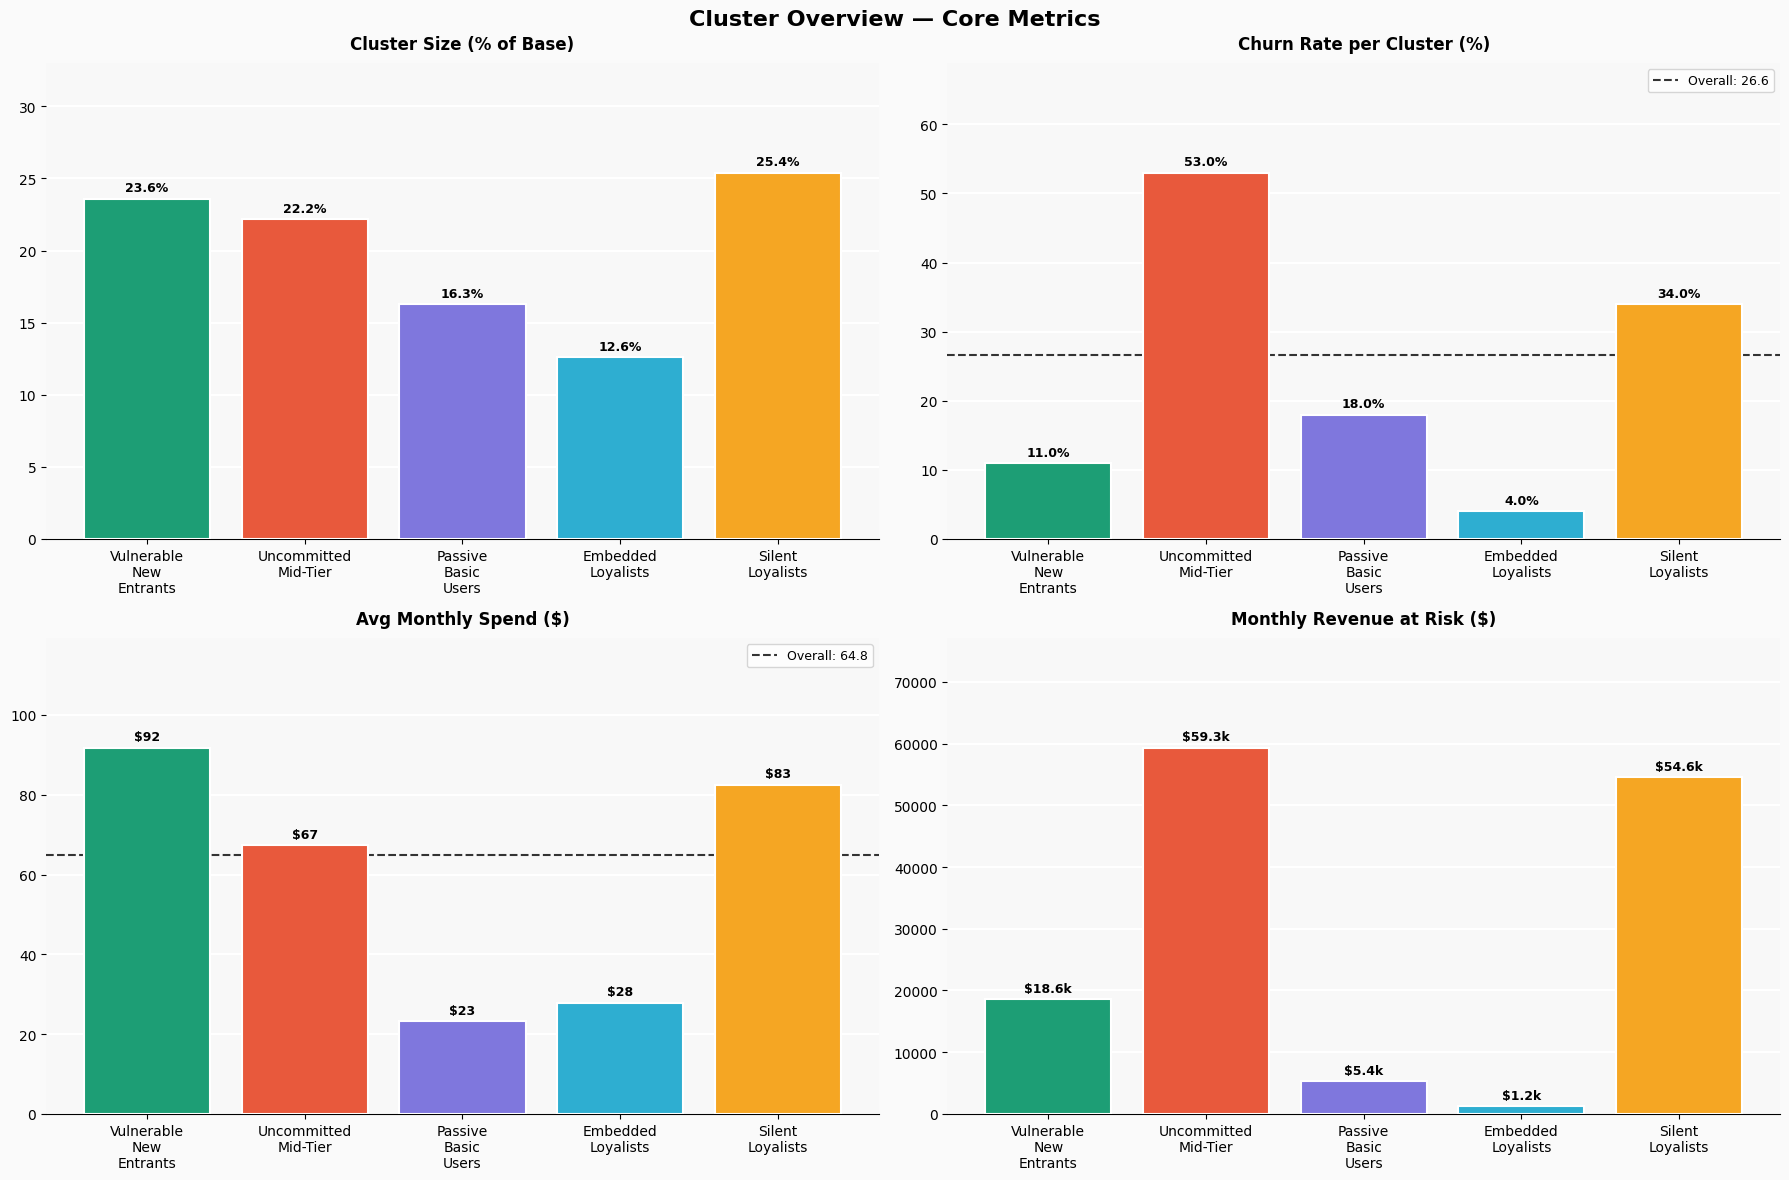

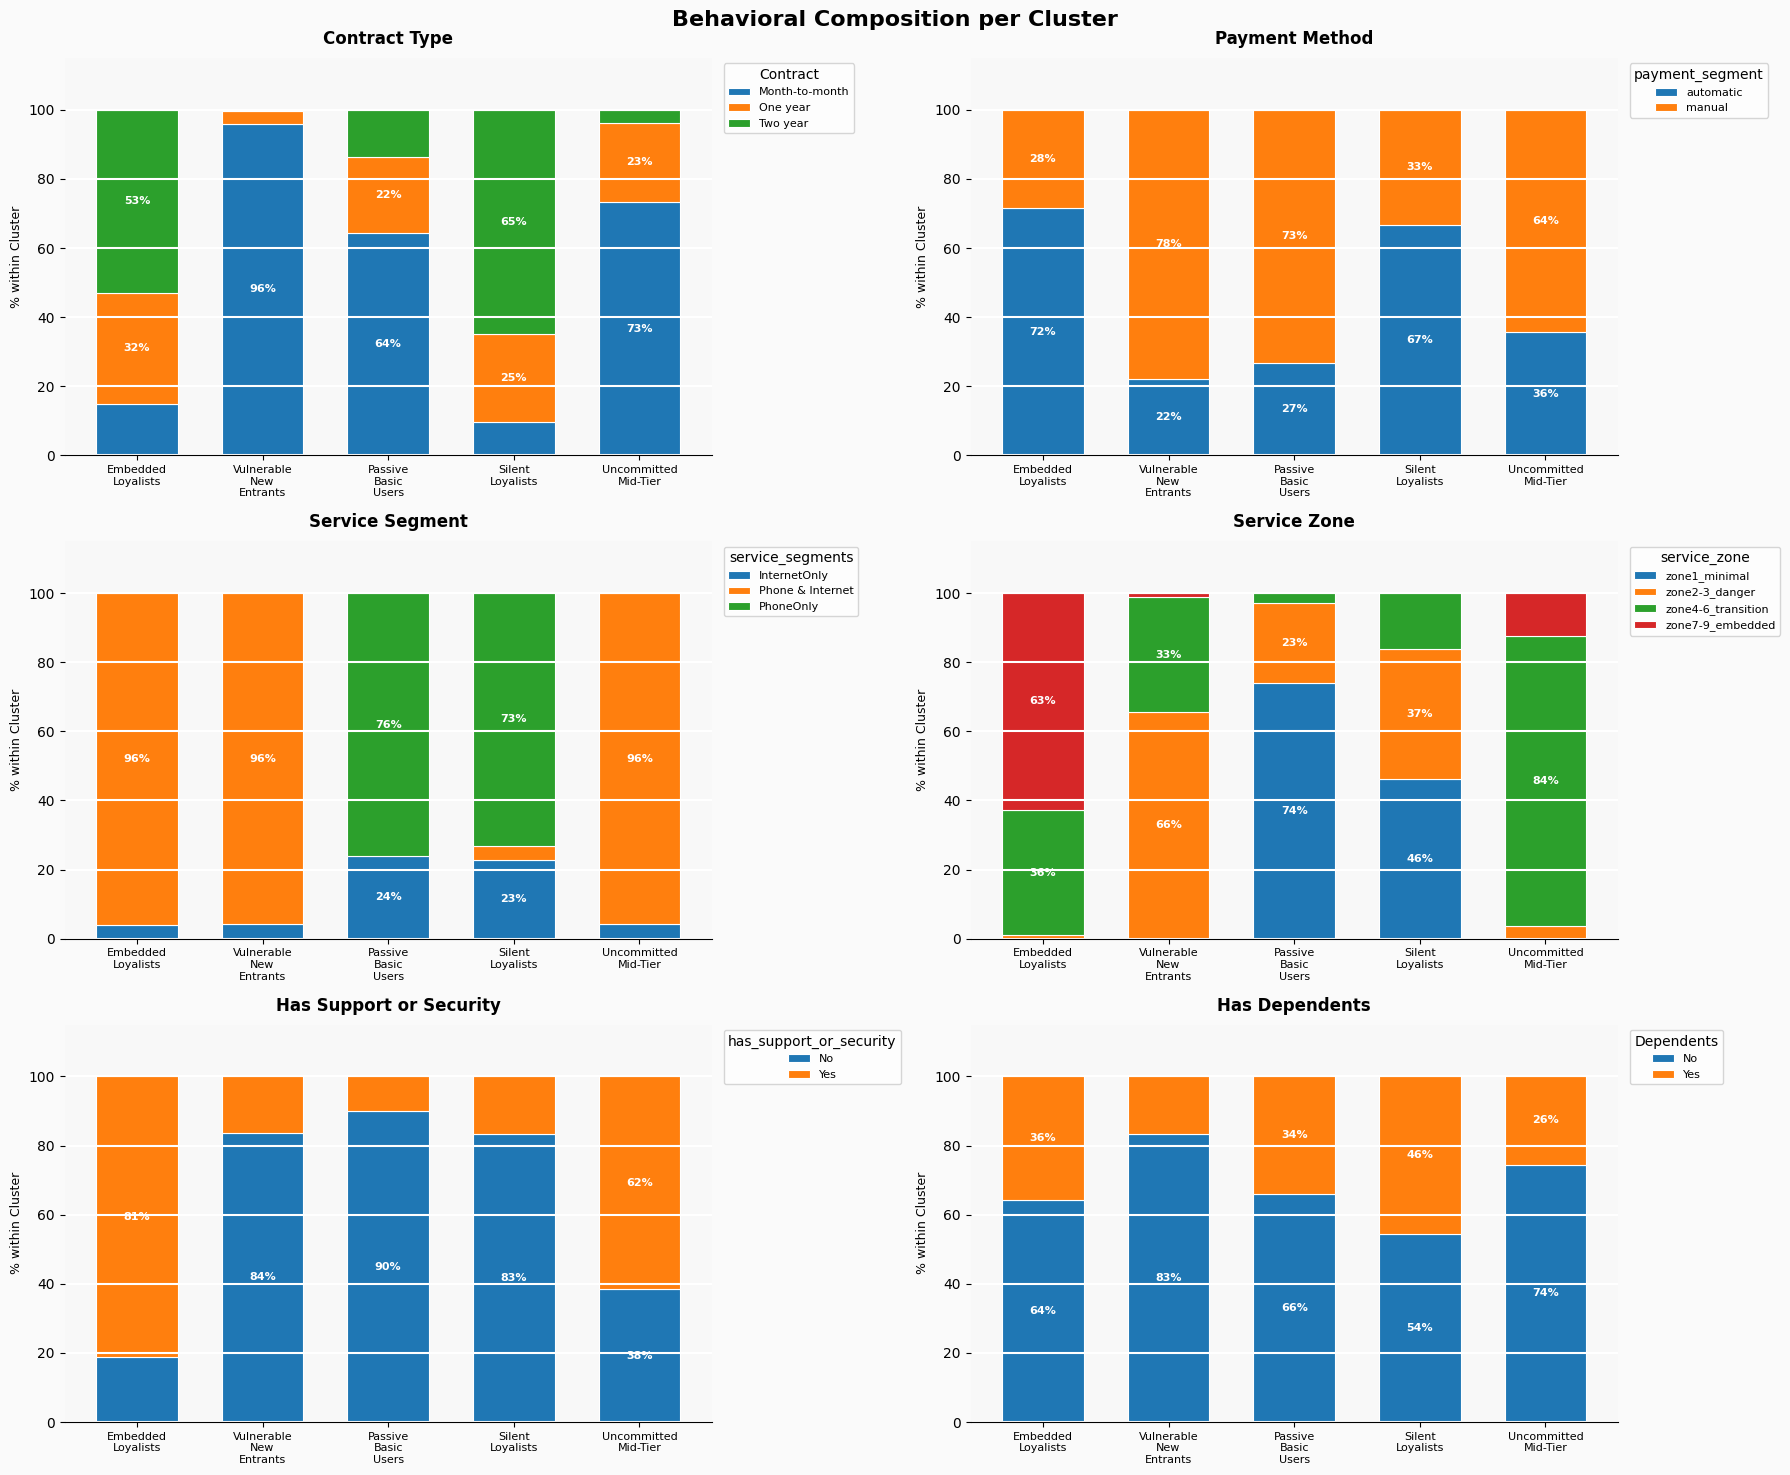

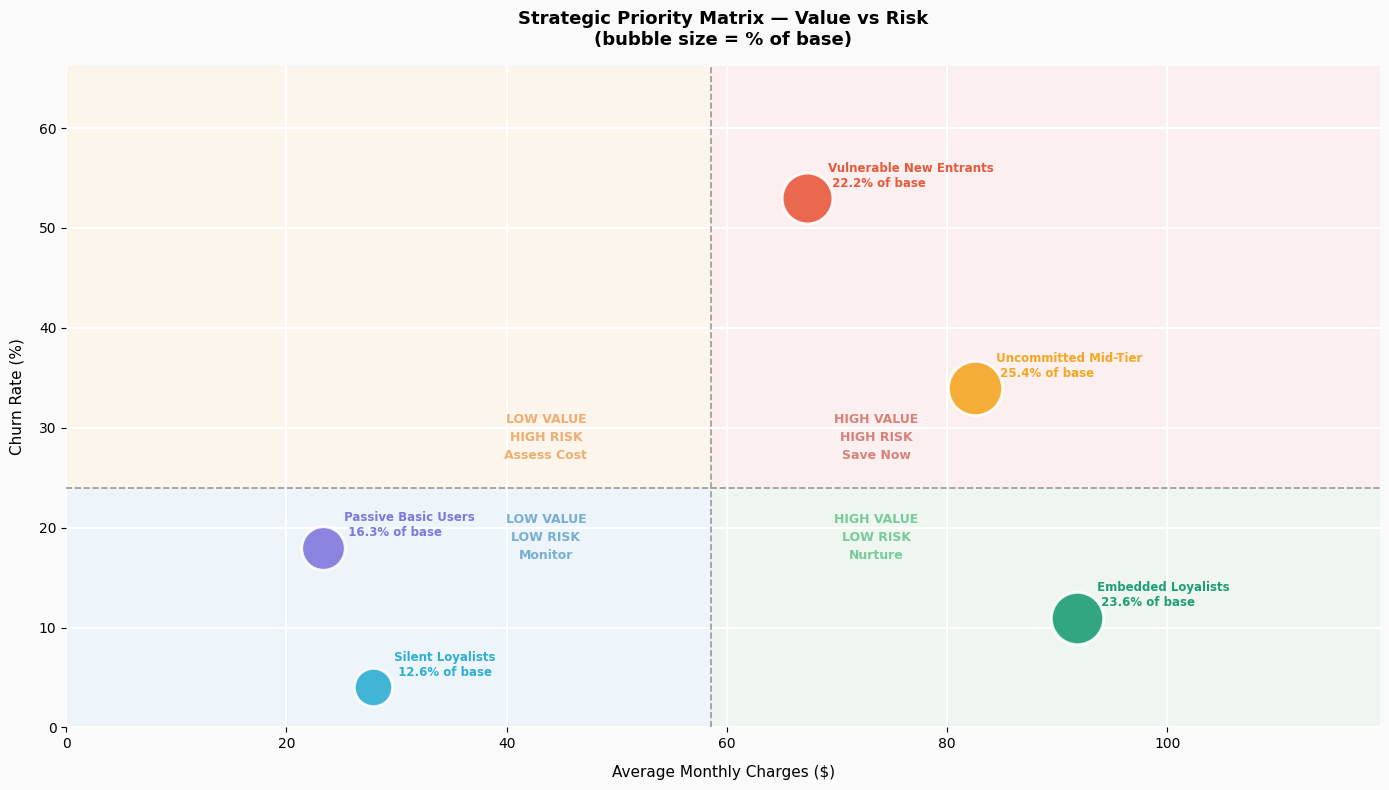

In [12]:
# @title Visualization Chart Section
# ==================================================================================================
# Cluster Profiling -> ALign with business interpretation
# ==================================================================================================

# --- Shared config ---
cluster_order  = profile.sort_values('cluster_id')['cluster_name'].tolist()
colors         = profile.sort_values('cluster_id')['color'].tolist()
names_short    = [n.replace(' ', '\n') for n in profile['cluster_name']]

# ---
# FIGURE 1 — Executive Dashboard (4 core metrics)
# ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor='#FAFAFA')
fig.suptitle('Cluster Overview — Core Metrics',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

chart_configs = [
    ('pct_of_base',    'Cluster Size (% of Base)',         '%',   None),
    ('churn_rate_pct', 'Churn Rate per Cluster (%)',        '%',   OVERALL_CHURN * 100),
    ('avg_monthly',    'Avg Monthly Spend ($)',             '$',   OVERALL_MONTHLY),
    ('rev_at_risk',    'Monthly Revenue at Risk ($)',       '$k',  None),
]

for ax, (col, title, fmt, ref_line) in zip(axes, chart_configs):
    vals  = profile.sort_values('cluster_id')[col]
    clrs  = profile.sort_values('cluster_id')['color'].tolist()
    bars  = ax.bar(names_short, vals, color=clrs,
                   edgecolor='white', linewidth=1.5, zorder=3)

    if ref_line:
        ax.axhline(y=ref_line, color='#333333', linestyle='--',
                   linewidth=1.5, label=f'Overall: {ref_line:.1f}')
        ax.legend(fontsize=9)

    for bar, val in zip(bars, vals):
        label = (f'${val/1000:.1f}k' if fmt == '$k'
                 else f'${val:.0f}' if fmt == '$'
                 else f'{val}%')
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + vals.max() * 0.02,
                label, ha='center', fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylim(0, vals.max() * 1.3)
    ax.set_facecolor('#F8F8F8')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.grid(axis='y', color='white', linewidth=1.5, zorder=0)

plt.tight_layout()
plt.show()

# ---
# FIGURE 2 — Behavioral Composition (categorical breakdown)
# ---
n_cols = 2
n_rows = (len(categorical_profile_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(18, 5 * n_rows),
                          facecolor='#FAFAFA')
fig.suptitle('Behavioral Composition per Cluster',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, (col, title) in enumerate(categorical_profile_cols):
    ax = axes[i]

    comp = (
        src_data.groupby(['cluster_name', col])
        .size()
        .reset_index(name='count')
        .assign(pct=lambda x: x.groupby('cluster_name')['count']
                .transform(lambda s: s / s.sum() * 100).round(1))
    )

    pivot = comp.pivot_table(
        index='cluster_name', columns=col,
        values='pct', fill_value=0
    ).reindex(cluster_order)

    pivot.plot(kind='bar', stacked=True, ax=ax,
               edgecolor='white', linewidth=0.8, width=0.65)

    for container in ax.containers:
        ax.bar_label(container,
                     labels=[f'{v:.0f}%' if v >= 20 else ''
                             for v in container.datavalues],
                     label_type='center', fontsize=8,
                     color='white', fontweight='bold')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('% within Cluster', fontsize=9)
    ax.set_xticklabels([n.replace(' ', '\n') for n in cluster_order],
                       rotation=0, fontsize=8)
    ax.set_ylim(0, 115)
    ax.set_facecolor('#F8F8F8')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.grid(axis='y', color='white', linewidth=1.5)
    ax.legend(title=col, bbox_to_anchor=(1.01, 1),
              loc='upper left', fontsize=8)

for i in range(len(categorical_profile_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# ---
# FIGURE 3 — Strategic Priority Matrix (value vs risk bubble chart)
# ---
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#FAFAFA')
ax.set_facecolor('#F8F8F8')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# ── Split axes at the average of each metric ──────────────────────
mid_churn   = profile['churn_rate_pct'].mean()   # ~24% — average churn
mid_monthly = profile['avg_monthly'].mean()       # ~$58 — average spend

# ── Quadrant fills: each rectangle extends from center to plot edge ──
x_max = profile['avg_monthly'].max() * 1.3       # right edge of plot
y_max = profile['churn_rate_pct'].max() * 1.25   # top edge of plot

quad_info = [
    # (x_start, y_start, width,               height,              color,      label)
    (mid_monthly, mid_churn,     x_max - mid_monthly, y_max - mid_churn, '#FFE8E8', 'Save Now'),    # Q1: High Value, High Risk
    (0,           mid_churn,     mid_monthly,         y_max - mid_churn, '#FFF3E0', 'Assess Cost'), # Q2: Low Value,  High Risk
    (mid_monthly, 0,             x_max - mid_monthly, mid_churn,         '#E8F5E9', 'Nurture'),      # Q3: High Value, Low Risk
    (0,           0,             mid_monthly,         mid_churn,         '#E3F2FD', 'Monitor'),      # Q4: Low Value,  Low Risk
]
for x, y, w, h, color, label in quad_info:
    ax.add_patch(plt.Rectangle((x, y), w, h, color=color, alpha=0.5, zorder=1))

# ── Quadrant label positions (offset from center) ──────────────────
quad_labels = [
    (mid_monthly + 15, mid_churn + 5,   'HIGH VALUE\nHIGH RISK\nSave Now',     '#c0392b'),
    (mid_monthly - 15, mid_churn + 5,   'LOW VALUE\nHIGH RISK\nAssess Cost',   '#e67e22'),
    (mid_monthly + 15, mid_churn - 5,   'HIGH VALUE\nLOW RISK\nNurture',       '#27ae60'),
    (mid_monthly - 15, mid_churn - 5,   'LOW VALUE\nLOW RISK\nMonitor',        '#2980b9'),
]
for x, y, text, color_q in quad_labels:
    ax.text(x, y, text, ha='center', va='center', fontsize=9,
            color=color_q, alpha=0.6, fontweight='bold', linespacing=1.5)

# ── Center divider lines ──────────────────────────────────────────
ax.axvline(x=mid_monthly, color='#999', linestyle='--', linewidth=1.2, zorder=2)
ax.axhline(y=mid_churn,   color='#999', linestyle='--', linewidth=1.2, zorder=2)

# ── Plot each cluster as a bubble ─────────────────────────────────
for _, row in profile.iterrows():
    identity = CLUSTER_IDENTITY[row['cluster_id']]
    ax.scatter(row['avg_monthly'], row['churn_rate_pct'],
               s=row['pct_of_base']*60,           # bubble size = % of base
               color=identity['color'],
               edgecolors='white', linewidth=2, zorder=5, alpha=0.9)
    ax.annotate(
        f" {identity['name']}\n  {row['pct_of_base']}% of base",
        xy=(row['avg_monthly'], row['churn_rate_pct']),
        xytext=(12, 8), textcoords='offset points',
        fontsize=8.5, fontweight='bold', color=identity['color'], zorder=6
    )

# ── Axis labels & limits ─────────────────────────────────────────
ax.set_xlabel('Average Monthly Charges ($)', fontsize=11, labelpad=10)
ax.set_ylabel('Churn Rate (%)', fontsize=11, labelpad=10)
ax.set_title('Strategic Priority Matrix — Value vs Risk\n(bubble size = % of base)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)
ax.grid(color='white', linewidth=1.5, zorder=0)

plt.tight_layout()
plt.show()


###### **Key Takeaways :**

* **5 customer types, 5 different problems.** Churn ranges from 4% to 53%, five distinct issues, each needing a different solution.

* **The two highest spenders sit at opposite ends of the risk spectrum.**
The Embedded Loyalists (\$91.78/month are deeply locked in w/ 5+yearTenure, annual contract, 7+services) while The Uncommitted Mid-Tier (\$82.53/mo) still monthly contract eventough already 2+ years with the provider. High spend does not equal safe revenue

* **The Uncommitted Mid-Tier is the #1 priority.** 25% of the customer base with $54K/month in revenue at risk. One competitor offer away from leaving.

* **The Vulnerable New Entrants (53% churn) is the most solvable problem.** The timing (month 7) strongly points to a promotional price expiring, a fixable issue with outreach at month 5–6.

* **Passive Basic Users ($23/mo) & silent loyalists(28/mo) need upgrades, not retention.** Churn is below average, but spending is too low to prioritize retention. The real opportunity is moving them to higher-value plans.




---
###### **Strategic Priority:**

To give decision-makers a ready-to-use action plan.

* **Priority 1** is the Uncommitted Mid-Tier, the largest segment (25.4%), second-highest spend ($82.53), and 34.4% churn means (\$54,583/month) in revenue walking out. A contract conversion campaign here is the single highest-ROI action available.

* **Priority 2** is the Vulnerable New Entrants, highest churn at 53.2%, The problem is not commitment it is that month 7 is when the promotional price expires and the real price kicks in. The fix is a proactive outreach at month 5 before the cliff arrives, not after.

* **Priority 3** is the Embedded Loyalists , low churn but $152k/month in total revenue means even 11% churn hurts. Contract renewal offers should go out six months before expiry.

* **Priority 4–5** are the Passive Basic Users and Silent Loyalists, upgrade campaigns and gentle nudges, not urgent retention spend.

I use these profiles as inputs for the next layer —> a predictive churn scoring model.

The goal is to rank every customer by churn probability so I know who to act on first, not just which segments exist.

making the insight more actionable

#### **Layer 3 : Churn Predictive Scoring**

To move from understanding who churned historically **to actively predicting
which customers are most likely to churn next, and ranking them by urgency**
so the retention team knows exactly **who to act on first.**

**Objective:**
Build a churn probability score for every customer — not just a segment label, but a number between 0 and 1 that represents their likelihood of leaving. **This is where the analysis shifts from descriptive
to operational.**

**The Challenges:**

* A high accuracy score does not mean a good model — with 26% churn rate, a model that predicts nobody churns is 74% accurate and completely useless.

* Feature importance tells me which variables matter, but not how. XGBoost might rank tenure as the top predictor, but does long tenure mean loyalty or a legacy pricing plan that is now overpriced? The algorithm does not answer that. I need Layer 1's business understanding to interpret what the model is actually saying.

**Algorithm Used:**

I test three models to make sure the results hold up, not just one.

I start with Logistic Regression as the baseline. Every coefficient tells me something directly — "month-to-month contracts increase churn odds by this much." Simple, transparent, and easy for stakeholders to trust.

I then run Random Forest as a comparison. It is harder to overfit and needs less tuning, so if it agrees with XGBoost, I know the patterns are real.

I use XGBoost as the primary model. It handles mixed data well, deals with imbalanced classes when configured correctly, and lets me extract feature importance through SHAP to confirm the earlier parameter work still holds.

All three are supervised learning algorithms. Unlike the clustering in Layer 2 where I let the data find groups without a target, here I use the Churn label directly as the target the model learns from.

**Steps:**

Completed in the previous steps :

* Data Cleaning (✅ — refer to Step 1: Data Quality Assessment)
* Feature Preparation (✅ — refer to Step 2: pt 3 Breakdown Parameter)
* Cluster Labels as Features (✅ — refer to Layer 2: Statistical Clustering)

Covered in this step:

* **Feature Importance Churn**

* **Train / test split with stratification** ->
make sure both train and test data have the same proportion.( Training Set : 26%Churn
Test Set : 26% Churn)
Without it, random splitting could accidentally put 35% churn in train and 15% in test, making the model learn the wrong distribution and evaluation unreliable.


* **Handle class imbalance** -> make sure the model pays extra attention to the churn group even though it is small.

* **Train Logistic Regression, Random Forest, and XGBoost** — test three different models so the conclusions are not a fluke of one algorithm. If all three agree on which features matter and which customers are high risk, I can trust the results.

* **Evaluate with AUC, Precision-Recall, and Lift Curve**

  *  AUC — measures how well the model distinguishes churners from retained customers.

  * Precision-Recall — precision tells me how often the model is right when it flags a customer as high risk; recall tells me how many actual churners it caught.(*confusion matrix included)

  * Lift Curve — checks if the model performs better than random guessing.

* **Extract and interpret feature importance with SHAP** to se the reasons behind the score

* **Assign churn probability score to every customer**

* **Build retention priority list based on score x revenue at risk** -> so when two customers have the same churn score, revenue becomes the tiebreaker to decide who gets contacted first.

 **Feature Validation — Mutual Information & XGBoost**

**Objective:**

Before building a predictive model, I need to confirm which features actually carry signal about churn. I start with the features already validated through business analysis in Layer 1 and used for clustering in Layer 2. The key question here is whether the cluster labels from Layer 2 add predictive value on top of the original features.

I use two complementary methods. Mutual Information looks at each feature independently. XGBoost Feature Importance looks at all features together. A feature that passes both tests is worth keeping in the predictive model.

**The Challenges:**

Mutual Information only sees one feature at a time — it cannot detect interactions. XGBoost catches interactions but is biased toward features with many unique values. Using both balances the weakness of each.

**Method:**

I take the feature set from Layer 2 clustering plus the cluster_id labels. I run Mutual Information on all candidates and classify each as Moderate signal, Weak signal, or Noise (MI < 0.01). Noise features are dropped.

I then train an XGBoost model on the remaining features (AUC must exceed 0.75 to trust the results) and extract Gain-based importance. The final feature set includes only features that pass both tests.

10 of 13 candidate features available

MUTUAL INFORMATION — Column-level churn signal
                feature  mi_score   signal
               Contract  0.096736 Moderate
             cluster_id  0.085644 Moderate
                 tenure  0.081618 Moderate
         MonthlyCharges  0.043894     Weak
       service_segments  0.034966     Weak
           service_zone  0.029834     Weak
        payment_segment  0.023828     Weak
             Dependents  0.017144     Weak
has_support_or_security  0.015450     Weak
    senior_citizen_flag  0.004979    Noise


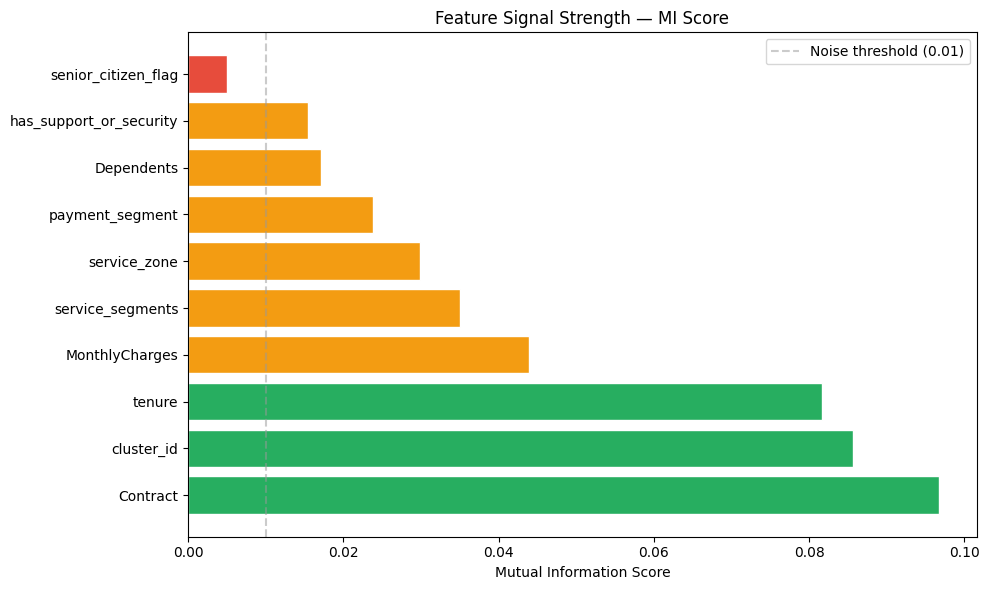


Drop (noise): ['senior_citizen_flag']
Keep: 9 features

XGBOOST FEATURE IMPORTANCE — Multivariate validation
AUC: 0.8065 — Trust importance

Feature                            Gain
----------------------------------------
Contract                       0.4730
service_segments               0.1005
has_support_or_security        0.0793
tenure                         0.0728
MonthlyCharges                 0.0690
cluster_id                     0.0624
service_zone                   0.0549
payment_segment                0.0452
Dependents                     0.0429


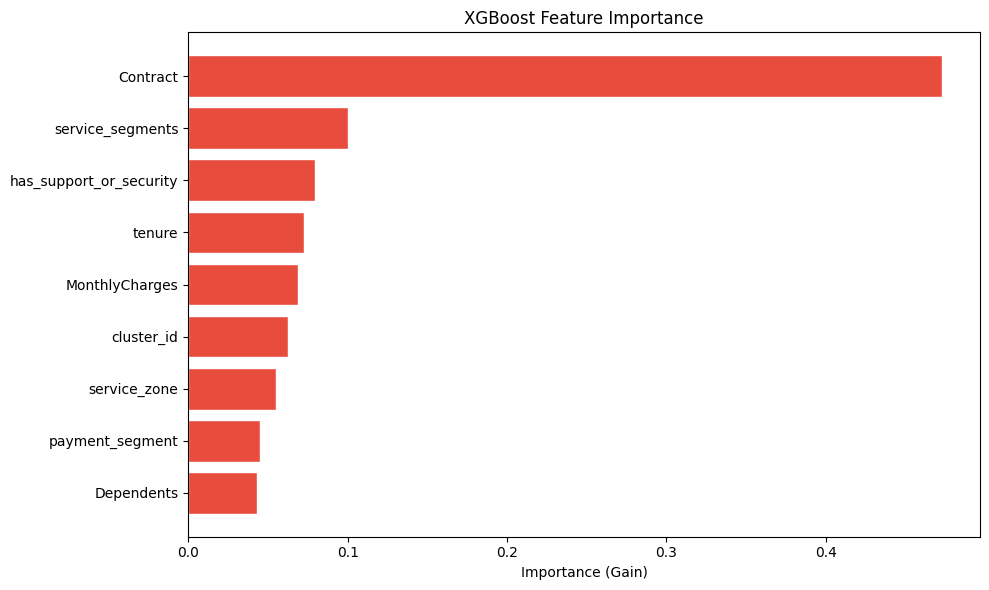


FINAL VALIDATED FEATURE SET FOR LAYER 3
Confirmed (9 features):
  1. Contract
  2. service_segments
  3. has_support_or_security
  4. tenure
  5. MonthlyCharges
  6. cluster_id
  7. service_zone
  8. payment_segment
  9. Dependents

Dropped (no signal): ['senior_citizen_flag']


In [13]:
# @title Feature Validation
# ════════════════════════════════════════════════════════════════
# FEATURE VALIDATION — MI then XGBoost
# Starting point: clustering features from Layer 2 + cluster_id
# ════════════════════════════════════════════════════════════════



# ── Candidate features: from Layer 2 clustering + cluster labels ──
candidate_features = [
    # Numeric (from clustering input)
    'tenure', 'MonthlyCharges',
    # Categorical (from clustering input)
    'payment_segment', 'Contract', 'senior_citizen_flag',
    'Dependents', 'has_support_or_security',
    'service_segments', 'service_zone',
    # Derived features from feature engineering
    'Is_AutoPay', 'Is_MTM', 'Product_Count',
    # New: cluster labels from Layer 2
    'cluster_id'
]

available = [c for c in candidate_features if c in src_data.columns]
print(f'{len(available)} of {len(candidate_features)} candidate features available')

mi_data = src_data[available + ['churn_flag']].dropna().copy()

# ════════════════════════════════════════════════════════════════
# 1. MUTUAL INFORMATION — Filter noise first
# ════════════════════════════════════════════════════════════════

print('\n' + '=' * 68)
print('MUTUAL INFORMATION — Column-level churn signal')
print('=' * 68)

numeric_cols = mi_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'churn_flag']
categorical_cols = [c for c in available if c not in numeric_cols]

mi_encoded = mi_data.copy()
for col in categorical_cols:
    mi_encoded[col] = LabelEncoder().fit_transform(mi_encoded[col].astype(str))

mi_scores = mutual_info_classif(mi_encoded[available], mi_encoded['churn_flag'], random_state=42)
mi_results = pd.DataFrame({
    'feature': available,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

def classify_signal(score):
    if score >= 0.05:
        return 'Moderate'
    elif score >= 0.01:
        return 'Weak'
    else:
        return 'Noise'

mi_results['signal'] = mi_results['mi_score'].apply(classify_signal)
print(mi_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors_mi = ['#e74c3c' if s == 'Noise' else '#f39c12' if s == 'Weak' else '#27ae60' for s in mi_results['signal']]
ax.barh(range(len(mi_results)), mi_results['mi_score'], color=colors_mi, edgecolor='white')
ax.set_yticks(range(len(mi_results)))
ax.set_yticklabels(mi_results['feature'])
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Signal Strength — MI Score')
ax.axvline(x=0.01, color='#999', linestyle='--', alpha=0.5, label='Noise threshold (0.01)')
ax.legend()
plt.tight_layout()
plt.show()

noise_features = mi_results[mi_results['signal'] == 'Noise']['feature'].tolist()
keep_features = mi_results[mi_results['signal'] != 'Noise']['feature'].tolist()
print(f'\nDrop (noise): {noise_features}')
print(f'Keep: {len(keep_features)} features')

# ════════════════════════════════════════════════════════════════
# 2. XGBOOST — Validate on pre-filtered features
# ════════════════════════════════════════════════════════════════

print('\n' + '=' * 68)
print('XGBOOST FEATURE IMPORTANCE — Multivariate validation')
print('=' * 68)

X_xgb = mi_encoded[keep_features]
y_xgb = mi_encoded['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb
)

model = xgb.XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', use_label_encoder=False
)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
status = ('Trust importance' if auc > 0.75
          else 'Directional only' if auc > 0.6
          else 'Do not trust')
print(f'AUC: {auc:.4f} — {status}')

importance_df = pd.DataFrame({
    'feature': keep_features,
    'gain': model.feature_importances_
}).sort_values('gain', ascending=False).reset_index(drop=True)

print(f'\n{"Feature":30s} {"Gain":>8s}')
print('-' * 40)
for _, row in importance_df.iterrows():
    print(f'{row["feature"]:30s} {row["gain"]:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = importance_df.iloc[::-1]
ax.barh(range(len(plot_df)), plot_df['gain'], color='#e74c3c', edgecolor='white')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['feature'])
ax.set_xlabel('Importance (Gain)')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# 3. FINAL FEATURE SET
# ════════════════════════════════════════════════════════════════

print('\n' + '=' * 68)
print('FINAL VALIDATED FEATURE SET FOR LAYER 3')
print('=' * 68)

validated = importance_df['feature'].tolist()
print(f'Confirmed ({len(validated)} features):')
for i, f in enumerate(validated, 1):
    print(f'  {i}. {f}')

print(f'\nDropped (no signal): {noise_features}')

SECTION A — DATA PREPARATION
Numeric: ['tenure', 'MonthlyCharges']
Categorical: ['Contract', 'service_segments', 'has_support_or_security', 'cluster_id', 'service_zone', 'payment_segment', 'Dependents']
Feature matrix: (7032, 9)
Churn rate: 26.6%
Train: 5625 (26.6% churn)  Test: 1407 (26.6% churn)
Imbalance ratio: 1 : 2.8

SECTION B — MODEL TRAINING
✓ Logistic Regression
✓ Random Forest
✓ XGBoost

SECTION C — EVALUATION & INTERPRETATION

--- AUC ---
Logistic Regression       AUC: 0.8258
Random Forest             AUC: 0.8317
XGBoost                   AUC: 0.8116


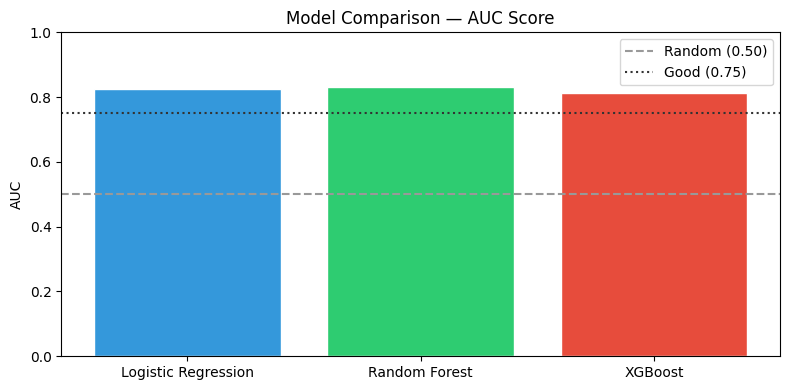

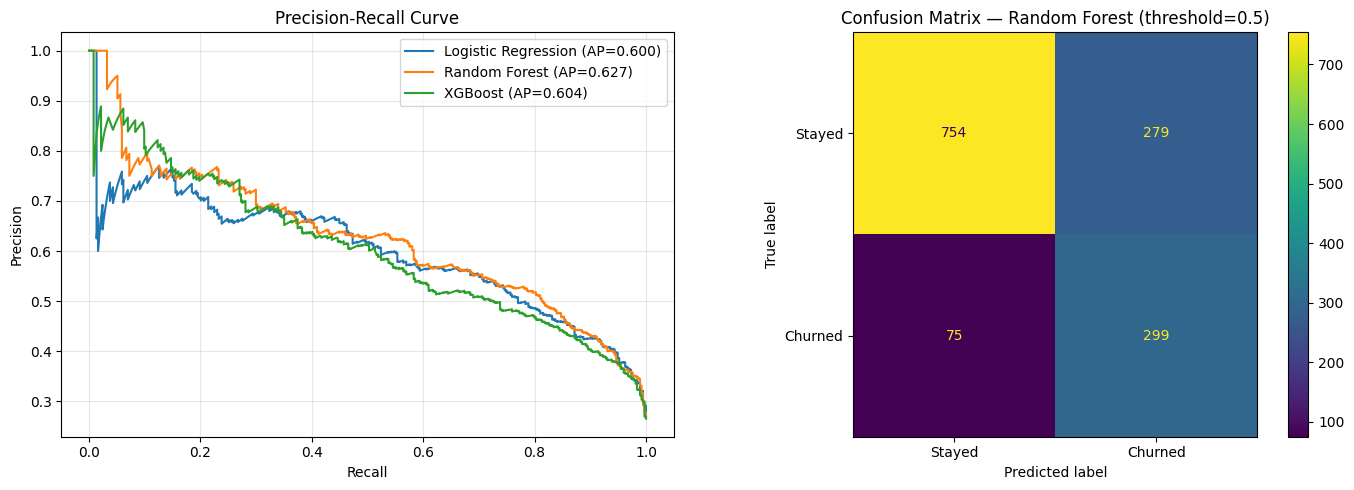

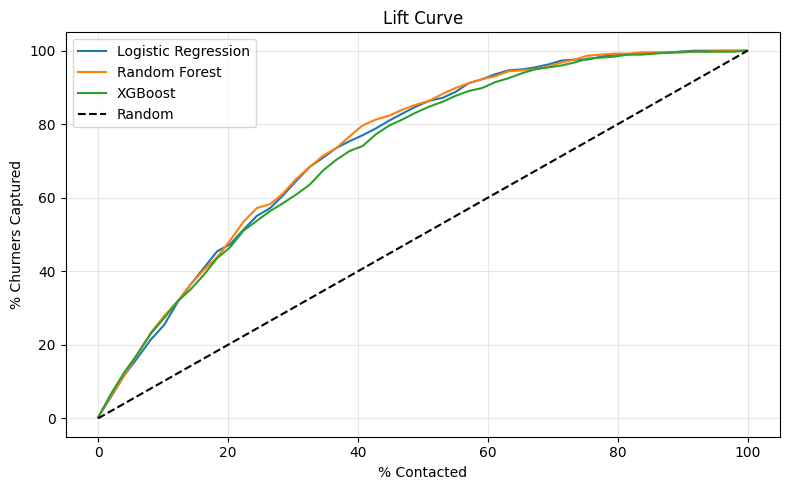


--- Lift at Key Thresholds ---
Logistic Regression       Top 10% captures 25% of churners
Logistic Regression       Top 20% captures 47% of churners
Logistic Regression       Top 30% captures 64% of churners
Random Forest             Top 10% captures 27% of churners
Random Forest             Top 20% captures 47% of churners
Random Forest             Top 30% captures 64% of churners
XGBoost                   Top 10% captures 27% of churners
XGBoost                   Top 20% captures 46% of churners
XGBoost                   Top 30% captures 60% of churners


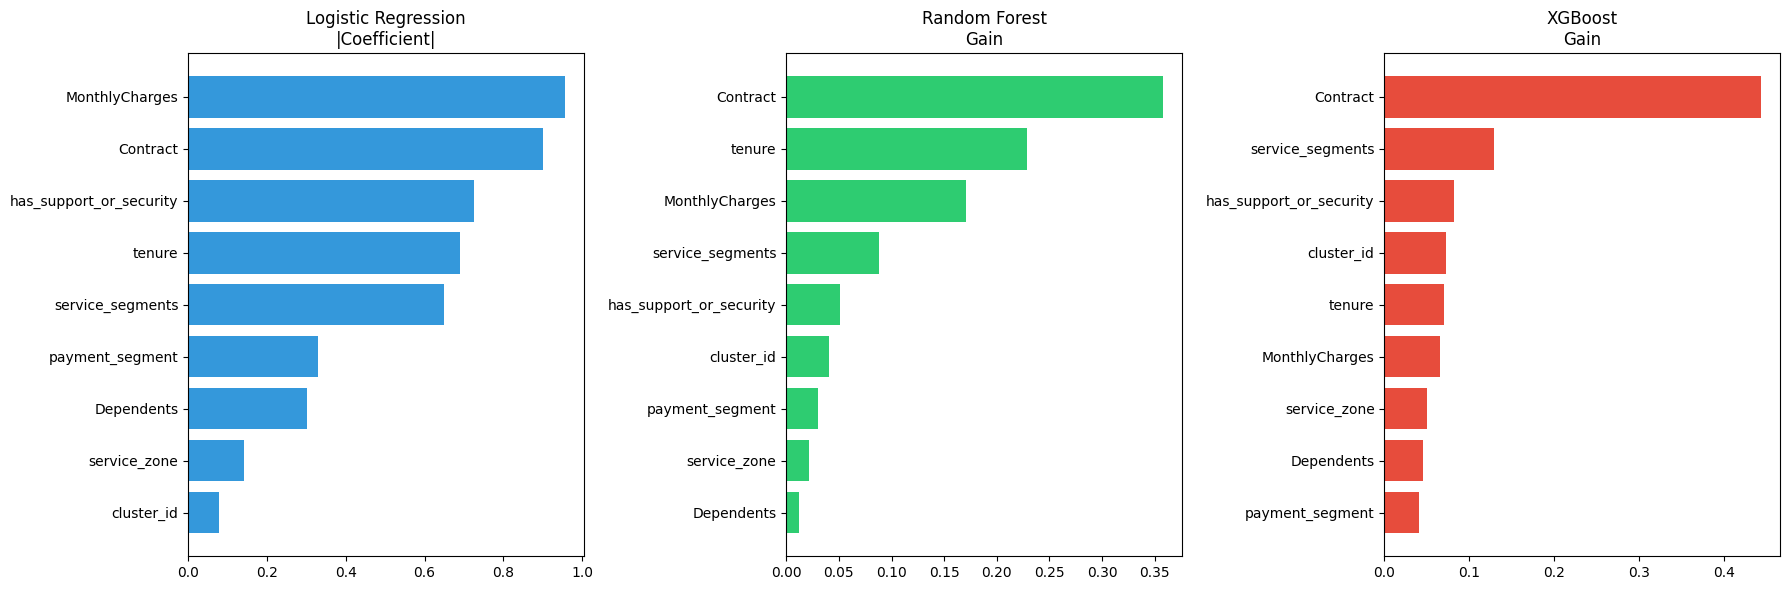

Top 5 features agreed by all 3 models: {'has_support_or_security', 'tenure', 'service_segments', 'Contract'}

--- What the Top 4 Features Mean for Churn Risk ---

▶ tenure_segment


,customers,churn_rate_pct
tenure_segment,,
0-12 months (New),2175,47.7%
13-24 months (Developing),1024,28.7%
25-48 months (Established),1594,20.4%
49+ months (Loyal),2239,9.5%


▶ Contract


,customers,churn_rate_pct
Contract,,
Month-to-month,3875,42.7%
One year,1472,11.3%
Two year,1685,2.8%


▶ has_support_or_security


,customers,churn_rate_pct
has_support_or_security,,
No,4073,33.5%
Yes,2959,17.1%


▶ service_zone


,customers,churn_rate_pct
service_zone,,
zone1_minimal,1260,11.0%
zone2-3_danger,1703,37.9%
zone4-6_transition,2792,31.3%
zone7-9_embedded,1277,16.6%



--- SHAP Explanation ---


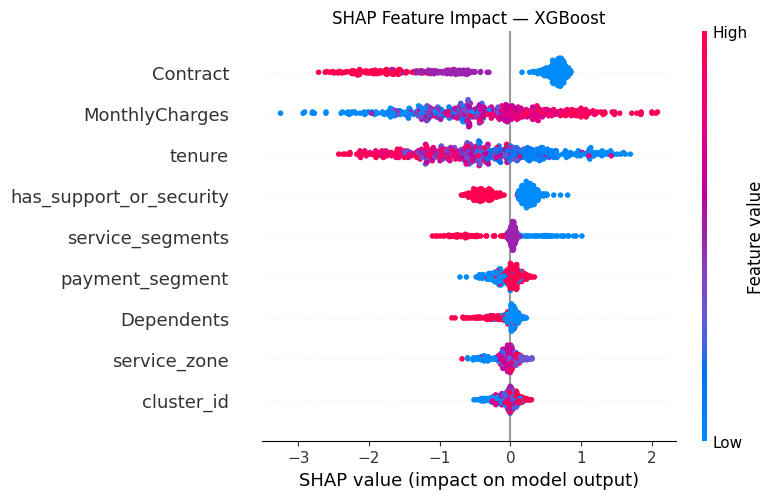


SECTION D — SCORING & RETENTION PRIORITY
Validation set (already churned — used to verify model): 1869 customers
Action set (still active — who to contact): 5163 customers

--- Validation: Top 10 already-churned customers ---
(These confirm the model scored churners correctly)


,customerID,churn_score,MonthlyCharges,priority_score,cluster_name,Contract,tenure
0,1400-MMYXY,0.907960,105.90,96.152937,Vulnerable New Entrants,Month-to-month,3
1,4587-VVTOX,0.908468,105.30,95.661630,Vulnerable New Entrants,Month-to-month,6
2,6496-SLWHQ,0.909786,105.00,95.527479,Vulnerable New Entrants,Month-to-month,3
3,3389-YGYAI,0.904103,105.50,95.382900,Vulnerable New Entrants,Month-to-month,8
4,5419-JPRRN,0.939628,101.45,95.325288,Vulnerable New Entrants,Month-to-month,1
5,2369-UAPKZ,0.913982,104.10,95.145530,Vulnerable New Entrants,Month-to-month,5
6,7216-EWTRS,0.940494,100.80,94.801762,Vulnerable New Entrants,Month-to-month,1
7,5052-PNLOS,0.897019,105.35,94.500916,Vulnerable New Entrants,Month-to-month,3
8,8884-ADFVN,0.916637,101.95,93.451162,Uncommitted Mid-Tier,Month-to-month,7
9,0302-JOIVN,0.917396,101.15,92.794636,Uncommitted Mid-Tier,Month-to-month,8



--- Action: Top 20 active customers to contact ---


,customerID,churn_score,MonthlyCharges,priority_score,cluster_name,Contract,tenure
0,5760-IFJOZ,0.905784,107.95,97.779420,Vulnerable New Entrants,Month-to-month,3
1,6734-GMPVK,0.912003,105.30,96.033935,Vulnerable New Entrants,Month-to-month,5
2,4566-NECEV,0.920857,96.55,88.908783,Vulnerable New Entrants,Month-to-month,5
3,4060-LDNLU,0.922419,96.20,88.736721,Vulnerable New Entrants,Month-to-month,7
4,4445-ZJNMU,0.884382,99.30,87.819145,Uncommitted Mid-Tier,Month-to-month,9
5,2984-AFWNC,0.915583,95.40,87.346580,Vulnerable New Entrants,Month-to-month,3
6,6350-XFYGW,0.920468,94.75,87.214371,Vulnerable New Entrants,Month-to-month,4
7,9094-AZPHK,0.869586,100.15,87.088992,Uncommitted Mid-Tier,Month-to-month,15
8,7398-SKNQZ,0.914737,94.90,86.808517,Vulnerable New Entrants,Month-to-month,3
9,5150-ITWWB,0.914149,94.85,86.707026,Vulnerable New Entrants,Month-to-month,3



--- Revenue at Risk by Priority Tier (Active Customers) ---


,customers,avg_score,avg_monthly,rev_at_risk
tier,,,,
Low,1291,0.04,32.11,1518.88
Medium,1291,0.19,54.37,9395.75
High,1290,0.36,71.18,28923.37
Critical,1291,0.62,87.58,68996.82



Total monthly revenue at risk across all active customers: $108,835
Critical tier alone accounts for $68,997

Best model: Random Forest (AUC: 0.832)


In [14]:
# @title Churn Predictive Scoring
# ════════════════════════════════════════════════════════════════
# LAYER 3 — CHURN PREDICTIVE SCORING
# Input features: validated by MI + XGBoost in previous step
# Output: churn probability + retention priority for every customer
# ════════════════════════════════════════════════════════════════



# ════════════════════════════════════════════════════════════════
# SECTION A — DATA PREPARATION
# ════════════════════════════════════════════════════════════════

print('=' * 68)
print('SECTION A — DATA PREPARATION')
print('=' * 68)

# Use the validated feature set from MI + XGBoost step
FEATURES = validated  # from the previous cell's output

# Separate numeric vs categorical
NUMERIC_FEATURES = ['tenure', 'MonthlyCharges']
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in FEATURES]
CATEGORICAL_FEATURES = [c for c in FEATURES if c not in NUMERIC_FEATURES]

print(f'Numeric: {NUMERIC_FEATURES}')
print(f'Categorical: {CATEGORICAL_FEATURES}')

X = src_data[FEATURES].copy()
y = src_data['churn_flag'].copy()

# Encode categoricals
X_encoded = X.copy()
for col in CATEGORICAL_FEATURES:
    if X[col].dtype == 'object' or str(X[col].dtype) == 'category':
        X_encoded[col] = LabelEncoder().fit_transform(X[col].astype(str))

print(f'Feature matrix: {X_encoded.shape}')
print(f'Churn rate: {y.mean():.1%}')

# ── Train/Test Split ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} ({y_train.mean():.1%} churn)  '
      f'Test: {len(X_test)} ({y_test.mean():.1%} churn)')

# ── Scale numeric (fit on TRAIN only) ──────────────────────────
scaler = StandardScaler()
X_train[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES]  = scaler.transform(X_test[NUMERIC_FEATURES])

# ── Class imbalance ────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
class_weight_dict = {0: 1, 1: scale_pos_weight}
print(f'Imbalance ratio: 1 : {scale_pos_weight:.1f}')

# ════════════════════════════════════════════════════════════════
# SECTION B — MODEL TRAINING
# ════════════════════════════════════════════════════════════════

print('\n' + '=' * 68)
print('SECTION B — MODEL TRAINING')
print('=' * 68)

models = {}

models['Logistic Regression'] = LogisticRegression(
    class_weight=class_weight_dict, max_iter=1000, random_state=42
).fit(X_train, y_train)
print('✓ Logistic Regression')

models['Random Forest'] = RandomForestClassifier(
    class_weight='balanced', n_estimators=200, max_depth=10,
    min_samples_leaf=20, random_state=42, n_jobs=-1
).fit(X_train, y_train)
print('✓ Random Forest')

models['XGBoost'] = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight, n_estimators=200, max_depth=6,
    learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', use_label_encoder=False
).fit(X_train, y_train)
print('✓ XGBoost')

# Predict
preds = {name: model.predict_proba(X_test)[:, 1] for name, model in models.items()}

# ════════════════════════════════════════════════════════════════
# SECTION C — EVALUATION & INTERPRETATION
# ════════════════════════════════════════════════════════════════

print('\n' + '=' * 68)
print('SECTION C — EVALUATION & INTERPRETATION')
print('=' * 68)

# ── 1. AUC ─────────────────────────────────────────────────────
print('\n--- AUC ---')
auc_scores = {}
for name in models:
    auc_scores[name] = roc_auc_score(y_test, preds[name])
    print(f'{name:25s} AUC: {auc_scores[name]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#3498db', '#2ecc71', '#e74c3c']
ax.bar(auc_scores.keys(), auc_scores.values(), color=colors, edgecolor='white')
ax.axhline(y=0.5, color='#999', linestyle='--', label='Random (0.50)')
ax.axhline(y=0.75, color='#333', linestyle=':', label='Good (0.75)')
ax.set_ylabel('AUC')
ax.set_title('Model Comparison — AUC Score')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

# ── 2. Precision-Recall + Confusion Matrix ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in models:
    prec, rec, _ = precision_recall_curve(y_test, preds[name])
    ap = average_precision_score(y_test, preds[name])
    axes[0].plot(rec, prec, label=f'{name} (AP={ap:.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

best_model = max(auc_scores, key=auc_scores.get)
cm = confusion_matrix(y_test, (preds[best_model] >= 0.5).astype(int))
ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned']).plot(ax=axes[1])
axes[1].set_title(f'Confusion Matrix — {best_model} (threshold=0.5)')
plt.tight_layout()
plt.show()

# ── 3. Lift Curve ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for name in models:
    data = pd.DataFrame({'actual': y_test, 'pred': preds[name]})
    data = data.sort_values('pred', ascending=False).reset_index(drop=True)
    cum_churn = data['actual'].cumsum()
    total_churn = data['actual'].sum()
    pts = np.linspace(0, len(data)-1, 50, dtype=int)
    ax.plot((pts / len(data)) * 100, (cum_churn.iloc[pts] / total_churn) * 100, label=name)

ax.plot([0, 100], [0, 100], 'k--', label='Random')
ax.set_xlabel('% Contacted'); ax.set_ylabel('% Churners Captured')
ax.set_title('Lift Curve'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Lift at key thresholds
print('\n--- Lift at Key Thresholds ---')
for name in models:
    data = pd.DataFrame({'actual': y_test, 'pred': preds[name]})
    data = data.sort_values('pred', ascending=False).reset_index(drop=True)
    total_churn = data['actual'].sum()
    for pct in [10, 20, 30]:
        captured = data['actual'].iloc[:int(len(data) * pct / 100)].sum()
        print(f'{name:25s} Top {pct:2d}% captures {captured/total_churn*100:.0f}% of churners')

# ── 4. Feature Importance (3 models side by side) ─────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

lr_imp = pd.DataFrame({'feature': FEATURES,
    'importance': abs(models['Logistic Regression'].coef_[0])
}).sort_values('importance', ascending=True)
axes[0].barh(lr_imp['feature'], lr_imp['importance'], color='#3498db')
axes[0].set_title('Logistic Regression\n|Coefficient|')

rf_imp = pd.DataFrame({'feature': FEATURES,
    'importance': models['Random Forest'].feature_importances_
}).sort_values('importance', ascending=True)
axes[1].barh(rf_imp['feature'], rf_imp['importance'], color='#2ecc71')
axes[1].set_title('Random Forest\nGain')

xgb_imp = pd.DataFrame({'feature': FEATURES,
    'importance': models['XGBoost'].feature_importances_
}).sort_values('importance', ascending=True)
axes[2].barh(xgb_imp['feature'], xgb_imp['importance'], color='#e74c3c')
axes[2].set_title('XGBoost\nGain')
plt.tight_layout()
plt.show()

# Agreement check
top5 = lambda df: set(df.nlargest(5, 'importance')['feature'])
agreed = top5(lr_imp) & top5(rf_imp) & top5(xgb_imp)
print(f'Top 5 features agreed by all 3 models: {agreed}')

# ── 4b. Interpret the 4 agreed features ────────────────────────
print('\n--- What the Top 4 Features Mean for Churn Risk ---\n')

for col in ['tenure_segment', 'Contract', 'has_support_or_security', 'service_zone']:
    if col not in src_data.columns:
        continue
    print(f'▶ {col}')
    result = src_data.groupby(col, observed=True).agg(
        customers=('customerID', 'count'),
        churn_rate=('churn_flag', 'mean')
    ).round(3)
    result['churn_rate_pct'] = (result['churn_rate'] * 100).round(1).astype(str) + '%'
    display(result[['customers', 'churn_rate_pct']])

# ── 5. SHAP ──────────────────────────────────────────────────
print('\n--- SHAP Explanation ---')
explainer = shap.TreeExplainer(models['XGBoost'])
test_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(test_sample)
shap.summary_plot(shap_values, test_sample, show=False)
plt.title('SHAP Feature Impact — XGBoost')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# SECTION D — SCORING & RETENTION PRIORITY
# ════════════════════════════════════════════════════════════════

print('\n' + '=' * 68)
print('SECTION D — SCORING & RETENTION PRIORITY')
print('=' * 68)

# ── Score all customers using best model ───────────────────────
X_all = X_encoded.copy()
X_all[NUMERIC_FEATURES] = scaler.transform(X_all[NUMERIC_FEATURES])

src_data['churn_score'] = models[best_model].predict_proba(X_all)[:, 1]
src_data['priority_score'] = src_data['churn_score'] * src_data['MonthlyCharges']

# ── Separate into validation vs action ─────────────────────────
validation = src_data[src_data['churn_flag'] == 1].copy()
action     = src_data[src_data['churn_flag'] == 0].copy()

# Sort each by priority
validation = validation.sort_values('priority_score', ascending=False).reset_index(drop=True)
action     = action.sort_values('priority_score', ascending=False).reset_index(drop=True)

validation['priority_rank'] = range(1, len(validation) + 1)
action['priority_rank']     = range(1, len(action) + 1)

print(f'Validation set (already churned — used to verify model): {len(validation)} customers')
print(f'Action set (still active — who to contact): {len(action)} customers')
print()

# ── Validation check ───────────────────────────────────────────
print('--- Validation: Top 10 already-churned customers ---')
print('(These confirm the model scored churners correctly)')
display(validation.head(10)[['customerID', 'churn_score', 'MonthlyCharges',
                              'priority_score', 'cluster_name', 'Contract', 'tenure']])

# ── Action list ────────────────────────────────────────────────
print('\n--- Action: Top 20 active customers to contact ---')
display(action.head(20)[['customerID', 'churn_score', 'MonthlyCharges',
                          'priority_score', 'cluster_name', 'Contract', 'tenure']])

# ── Priority tiers (active customers only) ─────────────────────
action['tier'] = pd.qcut(action['priority_score'], q=4,
    labels=['Low', 'Medium', 'High', 'Critical'])

tier_summary = action.groupby('tier', observed=True).agg(
    customers=('customerID', 'count'),
    avg_score=('churn_score', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
    rev_at_risk=('priority_score', 'sum')
).round(2)

print('\n--- Revenue at Risk by Priority Tier (Active Customers) ---')
display(tier_summary)

total_at_risk = action['priority_score'].sum()
print(f'\nTotal monthly revenue at risk across all active customers: ${total_at_risk:,.0f}')
print(f'Critical tier alone accounts for ${tier_summary.loc["Critical", "rev_at_risk"]:,.0f}')
print(f'\nBest model: {best_model} (AUC: {auc_scores[best_model]:.3f})')

##### **Key Takeaways — Predictive Scoring Results**

* **Best model: Random Forest (AUC: 0.832).** But the margin is tiny — Logistic Regression scored 0.826 and XGBoost scored 0.812. All three models are within 0.02 of each other. This consistency is actually good news. It means the signals in this dataset are strong enough that even a simple model finds them. Random Forest wins by a small edge, but the practical takeaway is that model choice matters less than having the right features.

* **Lift curve — all three models perform nearly identically.** At the top 10% of customers, each model captures roughly 25–27% of all churners. **That is about 2.5 to 2.7 times better than random selection.** At the top 30%, they all capture around 60–64% of churners. The close alignment confirms the feature set, not the algorithm, is driving the results.

* **Confusion matrix.** I set the threshold at 0.5. False positives are acceptable for a low-cost email or SMS campaign. False negatives are the bigger concern these are high-risk customers the model misses. **Lowering the threshold catches more of them at the cost of more false alarms.**

* **Top priority customers align with cluster profiling.** Every customer in the top 20 by retention priority belongs to either Vulnerable New Entrants or Uncommitted Mid-Tier — both on month-to-month contracts. This is not a surprise. The cluster profiling already identified these two segments as the highest-risk groups. The predictive model now gives each customer a precise score so the retention team knows exactly who to contact first.

* **Revenue at risk by tier.** The Critical tier (top 25% by priority score) holds $118,269 in monthly revenue at risk with an average churn probability of 0.76. This is where the retention team should focus.

* **Bottom line.** The model is production-ready as a prioritization tool. With all three models agreeing and the results aligning with earlier cluster analysis, the findings are robust. The model narrows 7,032 customers down to a focused list ranked by urgency. To push performance further, the next step is integrating operational data this dataset lacks — support call history, payment delays, and usage trends.

##### **Top 4 Churn Risk features — what the data says about churn risk.**

1. **Tenure** is the strongest signal. Customers in their first year churn at 47.7%. After year one, it drops to 28.7%. After two years, 20.4%. Beyond four years, only 9.5% churn. The first 12 months are the critical window for retention intervention.

2. **Contract type** is the most actionable lever. Month-to-month customers churn at 42.7%. One-year contracts drop to 11.3%. Two-year contracts drop further to 2.8%. Converting a customer from month-to-month to an annual contract reduces churn risk by roughly 4 times.

3. **Having support or security services** cuts churn nearly in half. Customers without either churn at 33.5%. Customers with at least one churn at 17.1%. These add-ons act as stickiness mechanisms — the more a customer invests in the relationship, the less likely they are to leave.

4. **Service zone** shows a non-linear pattern. The highest risk is in the danger zone (37.9%), followed by transition (31.3%). The lowest risk is in the minimal zone (11.0%) and embedded zone (16.6%). The minimal zone is low risk because these are phone-only customers who stay out of inertia, not loyalty. The embedded zone is low risk because these customers have 7 to 9 services and leaving would be genuinely difficult.

## **Step 3 - Stakeholders Deliverable**


Created a 10-slide deck that turns the analysis into clear takeaways for any audience.

[Full Deck](https://docs.google.com/presentation/d/1RPdXvp2pFEN4-Y9lfGNSKrFdP7dUpO7w/edit?usp=sharing&ouid=116676887901740349499&rtpof=true&sd=true)

In [15]:
# @title

from IPython.display import display, HTML
display(HTML(
    '<iframe src="https://docs.google.com/presentation/d/1RPdXvp2pFEN4-Y9lfGNSKrFdP7dUpO7w/edit?usp=sharing&ouid=116676887901740349499&rtpof=true&sd=true/preview" width="960" height="569"></iframe>'
))

## **CLOSING**

Hi there! 👋🏻👋🏻

Thank you for reading through! I'd love to hear your thoughts.
If you have any questions, feedback, or ideas on how to improve this, please feel free to share. ✨

Why is this documentation (Notebook & Deck) structured this way? A few reasons:
* **For Personal Growth:** It is a space for me to practice, refine, and share my end-to-end EDA workflow.

* **For the Community:** Around 4 years ago, when I faced my first EDA project, I drew a total blank. I created 1001 charts and visuals, but I had no idea how to connect them into a meaningful story, and I didn't know where to start. My mentor at the time just told me it was all about experiences, which felt incredibly ambiguous. Long story short, while I am still learning and improving today, my framework is much clearer now than it was back then. I hope sharing this workflow can help you in any way.

* **For Future Me:** Let us be real. In three months, I won't remember half of what I did here. This write-up ensures that I can easily understand my own work when I look back at it later. 😄


haniyaazzahra@gmail.com | linkedin.com/in/haniya-azzahra